# Cell-Track Statistics: SCREAM vs MRMS (CONUS)

Diagnostic notebook comparing convective-cell tracking statistics between the
**SCREAMv1-cess2** model simulation and **MRMS** observations over a US sub-region
(default: Southeast, `SE`).

---

## Input data

Input files are produced by **`scream/scripts/combine_subset_tracks.py`**.
That script:

1. Scans monthly PyFLEXTRKR cell-tracking statistics files (`trackstats_*.nc`)
   from either SCREAM or MRMS.
2. Subsets tracks by **initiation time window** (default Apr–Aug 2020).
3. Filters tracks whose initiation location falls within a defined **US-state region**
   (`SE` | `NE` | `SGP` | `NGP`) using a GeoPandas spatial join against
   Census TIGER state boundaries.
4. Removes tracks **truncated at monthly file boundaries**
   (i.e. tracks that start at the first or end at the last timestamp of a file).
5. Concatenates the surviving tracks across months and writes a compact
   `subset_tracks_<YYYYMMDD>_<YYYYMMDD>_<REGION>.nc` file.

| Dataset | Source directory |
|---------|-----------------|
| SCREAM  | `/pscratch/sd/w/wcmca1/SCREAMv1-cess2/cell_conus/stats/` |
| MRMS    | `/pscratch/sd/i/iclas2/MRMS/cell_conus/stats/` |

Key track variables used: `start_basetime`, `end_basetime`, `track_duration`,
`start_status`, `end_status`, `meanlon`, `meanlat`, `cell_diameter`,
`max_dbz`, `maxETH_10dbz`, `maxETH_30dbz`.

---

## Analysis plots

| Figure | Description |
|--------|-------------|
| **1-D histogram + KDE** | Overlaid histogram and KDE curves comparing SCREAM vs. MRMS distributions of lifetime-representative cell properties: track duration, lifetime-maximum cell diameter, lifetime-maximum reflectivity (`max_dbz`), lifetime-maximum ETH at 10 dBZ, and track initiation hour in local time (diurnal cycle). |
| **Track initiation map** | Spatial density of SCREAM and MRMS track initiation locations (KDE-smoothed 2-D map) over the selected region. |
| **Joint KDE + marginal KDE** | 2-D joint density (KDE contours or filled contours) with 1-D marginal KDE curves on the top and right axes, comparing the bivariate distribution of two cell properties between SCREAM and MRMS. Variable pairs include cell diameter vs. max reflectivity and cell diameter vs. ETH at 10 dBZ. |
| **Binned ETH vs. cell diameter** | 2-D median scatter of echo-top height (ETH at 10 dBZ) vs. equivalent-area cell diameter, stratified by month (June only and all months Apr–Aug). Separate panels for ETH at 10, 20, and 30 dBZ. |
| **Composite track evolution** | Median time-evolution of four cell properties — cell diameter, max dBZ, 10-dBZ ETH, 30-dBZ ETH — for non-merging/non-splitting tracks binned by track duration (0–240 min in 30-min steps). Shown as individual per-variable plots and as a combined 4×2 figure. |

All figures are saved to:  
`/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/`

## Setup and Data Loading

Import libraries, configure paths, and load the SCREAM and MRMS subset track datasets produced by `combine_subset_tracks.py`.

In [1]:
import time
import os, glob
import copy
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from scipy.ndimage import gaussian_filter
from scipy.stats import pearsonr, spearmanr, linregress
from scipy.stats import gaussian_kde
import colormaps as colormaps
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Map data source name
name_map = {'m': 'SCREAM', 'o': 'MRMS'}

# Specify region
region = 'SE'

# Data paths
dir_m = '/pscratch/sd/w/wcmca1/SCREAMv1-cess2/cell_conus/stats/'
dir_o = '/pscratch/sd/i/iclas2/MRMS/cell_conus/stats/'

# Data filenames
file_m = f'{dir_m}/subset_tracks_20200401_20200831_{region}.nc'
file_o = f'{dir_o}/subset_tracks_20250401_20250831_{region}.nc'

# Output figure directory
figdir = f'/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/'
os.makedirs(figdir, exist_ok=True)
print(f"Figure output directory: {figdir}")

Figure output directory: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/


In [3]:
# Load obs data
ds_o = xr.open_dataset(file_o)
ds_o

<xarray.Dataset> Size: 9GB
Dimensions:                  (tracks: 242468, times: 300)
Coordinates:
  * tracks                   (tracks) int64 2MB 0 1 2 3 ... 242465 242466 242467
  * times                    (times) int64 2kB 0 1 2 3 4 ... 295 296 297 298 299
Data variables: (12/38)
    track_duration           (tracks) int32 970kB ...
    base_time                (tracks, times) datetime64[ns] 582MB ...
    meanlat                  (tracks, times) float32 291MB ...
    meanlon                  (tracks, times) float32 291MB ...
    area                     (tracks, times) float32 291MB ...
    cloudnumber              (tracks, times) float64 582MB ...
    ...                       ...
    start_split_timeindex    (tracks) float64 2MB ...
    start_split_cloudnumber  (tracks) float64 2MB ...
    end_merge_tracknumber    (tracks) float64 2MB ...
    end_merge_timeindex      (tracks) float64 2MB ...
    end_merge_cloudnumber    (tracks) float64 2MB ...
    original_tracks          (tracks) int64 2MB ...
Attributes: (12/13)
    Title:                  Statistics of each track
    Institution:            Pacific Northwest National Laboratory
    Contact:                Zhe Feng, zhe.feng@pnnl.gov
    Created_on:             Thu Feb 12 05:45:23 2026
    startdate:              20250401.0000
    enddate:                20250501.0000
    ...                     ...
    time_resolution_hour:   0.083333
    pixel_radius_km:        3.0
    subset_start_datetime:  2025-04-01T00:00
    subset_end_datetime:    2025-08-31T23:59
    subset_region:          SE
    subset_region_states:   LA, MS, AL, GA, SC, NC, TN

In [4]:
# Load model data
ds_m = xr.open_dataset(file_m)
ds_m

<xarray.Dataset> Size: 8GB
Dimensions:                  (tracks: 217940, times: 300)
Coordinates:
  * tracks                   (tracks) int64 2MB 0 1 2 3 ... 217937 217938 217939
  * times                    (times) int64 2kB 0 1 2 3 4 ... 295 296 297 298 299
Data variables: (12/38)
    track_duration           (tracks) int32 872kB ...
    base_time                (tracks, times) datetime64[ns] 523MB ...
    meanlat                  (tracks, times) float32 262MB ...
    meanlon                  (tracks, times) float32 262MB ...
    area                     (tracks, times) float32 262MB ...
    cloudnumber              (tracks, times) float64 523MB ...
    ...                       ...
    start_split_timeindex    (tracks) float64 2MB ...
    start_split_cloudnumber  (tracks) float64 2MB ...
    end_merge_tracknumber    (tracks) float64 2MB ...
    end_merge_timeindex      (tracks) float64 2MB ...
    end_merge_cloudnumber    (tracks) float64 2MB ...
    original_tracks          (tracks) int64 2MB ...
Attributes: (12/13)
    Title:                  Statistics of each track
    Institution:            Pacific Northwest National Laboratory
    Contact:                Zhe Feng, zhe.feng@pnnl.gov
    Created_on:             Thu Feb  5 19:35:14 2026
    startdate:              20200401.0000
    enddate:                20200501.0000
    ...                     ...
    time_resolution_hour:   0.0833333
    pixel_radius_km:        3.0
    subset_start_datetime:  2020-04-01T00:00
    subset_end_datetime:    2020-08-31T23:59
    subset_region:          SE
    subset_region_states:   LA, MS, AL, GA, SC, NC, TN

In [5]:
ds_m.start_basetime.max().values, ds_o.start_basetime.max().values

(np.datetime64('2020-08-31T23:55:00.000000000'),
 np.datetime64('2025-08-31T23:34:41.000000000'))

### Function to find merge/split tracks

In [6]:
def find_merge_split_tracks(ds, time_window, time_res=5.0):
    """
    Find merge/split track indices.
    
    Args:
        ds: xarray.Dataset
            Track statistics dataset
        time_window: tuple
            Time window to constrain mergers [minutes] (start, end)
        time_res: float, default=5.0
            Time resolution [minutes]
    
    Returns:
        out_dict: dictionary
            Dictionary containing various sets of track indices
    """
    ntracks = ds.sizes['tracks']

    # Get track lifetime
    lifetime = ds.track_duration.load() * time_res

    # Non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())

    # Non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())

    # Merge after time window tracks
    # idx_merge_after = ~np.isnan(ds.end_merge_cloudnumber.load()) & (lifetime > np.max(time_window))

    # Combine conditions (satisfy both):
    # - Non-merge or merge after time window
    # - Non-split
    # idx_nms = np.logical_and(idx_nsplit, (np.logical_or(idx_nmerge, idx_merge_after)))
    # - Non-merge and non-split
    idx_nms = np.logical_and(idx_nsplit, idx_nmerge)

    print(f"Non-split tracks: {idx_nsplit.sum().item()} ({idx_nsplit.sum().item()/ntracks:.1%}%)")
    print(f"Non-merge tracks: {idx_nmerge.sum().item()} ({idx_nmerge.sum().item()/ntracks:.1%}%)")
    # print(f"Merge after time window tracks: {idx_merge_after.sum().item()} ({idx_merge_after.sum().item()/ntracks:.1%}%)")
    print(f"Non-merge/split tracks: {idx_nms.sum().item()} ({idx_nms.sum().item()/ntracks:.1%}%)")

    # Group outputs to dictionary
    out_dict = {
        'ns': idx_nsplit,
        'nm': idx_nmerge,
        # 'ms': idx_merge_after,
        'nms': idx_nms,
    }
    return out_dict

In [7]:
time_window = (0, 60)  # minutes
track_indices_m = find_merge_split_tracks(ds_m, time_window)

Non-split tracks: 141086 (64.7%%)
Non-merge tracks: 146046 (67.0%%)
Non-merge/split tracks: 113706 (52.2%%)


In [8]:
track_indices_o = find_merge_split_tracks(ds_o, time_window)

Non-split tracks: 191136 (78.8%%)
Non-merge tracks: 191714 (79.1%%)
Non-merge/split tracks: 168053 (69.3%%)


In [9]:
# Filter non-merge-split tracks
dsnms_m = ds_m.isel(tracks=track_indices_m['nms'])
dsnms_m.sizes

Frozen({'tracks': 113706, 'times': 300})

In [10]:
# Filter non-merge-split tracks
dsnms_o = ds_o.isel(tracks=track_indices_o['nms'])
dsnms_o.sizes

Frozen({'tracks': 168053, 'times': 300})

In [11]:
time_resolution_min = dsnms_o.attrs['time_resolution_hour'] * 60
lifetime_o = dsnms_o['track_duration'] * time_resolution_min

(array([8.5762e+04, 1.6788e+04, 7.6280e+03, 2.3270e+03, 7.8400e+02,
        2.6800e+02, 9.0000e+01, 3.9000e+01, 1.4000e+01, 6.0000e+00]),
 array([  2. ,  12.7,  23.4,  34.1,  44.8,  55.5,  66.2,  76.9,  87.6,
         98.3, 109. ]),
 <BarContainer object of 10 artists>)

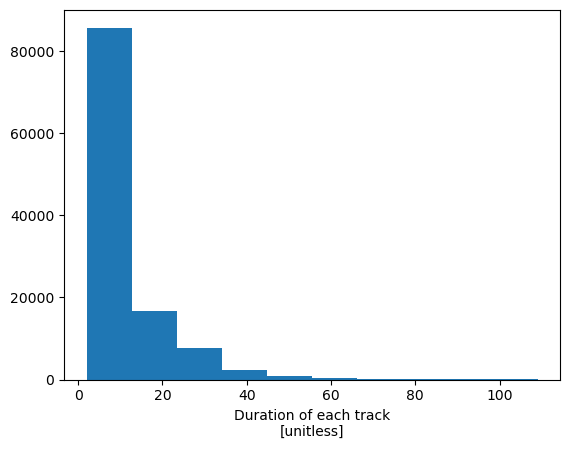

In [12]:
dsnms_m['track_duration'].plot.hist()

## Convert to Pandas DataFrames for Statistical Analysis

The track datasets have dimensions `(tracks, times)` where rows beyond each track's duration are NaN-padded.  
Converting to a tidy Pandas DataFrame removes this padding, producing a flat table of all valid `(track, time-step)` observations.

**Approach:**
1. `.to_dataframe()` — flattens the 2D xarray variables into a MultiIndex `(tracks, times)` DataFrame  
2. `.dropna(how='all')` — drops rows that are entirely NaN (i.e., padding beyond track duration)  
3. Merge 1D track-level metadata (`track_duration`, `start_basetime`, `end_basetime`) back in

The resulting DataFrames are ready for scipy statistics, seaborn/matplotlib plotting, and Pandas groupby operations.

In [13]:
def ds_to_dataframe(ds, time_res_min=5.0, name=''):
    """
    Convert a jagged (tracks x times) xarray Dataset to a tidy Pandas DataFrame.

    Speed strategy
    --------------
    1. ds.load()  — loads all variables in a single I/O pass, avoiding per-variable
                    lazy reads that make xarray's to_dataframe() very slow.
    2. numpy fancy indexing  — uses track_duration to build (track, time-step) index
                    arrays and extracts only valid entries directly, skipping the
                    creation of a full padded (tracks × times) DataFrame before dropna.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset with dimensions (tracks, times). After track duration, values are NaN.
    time_res_min : float
        Time resolution in minutes (used to compute relative_time_min).
    name : str
        Dataset label added as a 'dataset' column.

    Returns
    -------
    df : pandas.DataFrame
        Tidy DataFrame with one row per valid (track, time-step) observation.
        Columns include all original variables plus:
          - 'relative_step'      : integer time-step index (0 = first detection)
          - 'relative_time_min'  : relative time in minutes from track initiation
          - 'track_duration_min' : total track lifetime in minutes
          - 'dataset'            : dataset label (name argument)
    """
    # --- Step 1: load everything into memory in one shot ---
    ds_loaded = ds.load()

    track_duration = ds_loaded['track_duration'].values  # (tracks,)
    n_tracks = len(track_duration)

    vars_2d = [v for v in ds_loaded.data_vars if tuple(ds_loaded[v].dims) == ('tracks', 'times')]
    vars_1d = [v for v in ds_loaded.data_vars if tuple(ds_loaded[v].dims) == ('tracks',)]

    # --- Step 2: build index arrays using track_duration (no padded DataFrame) ---
    # track_idx[i] = which track (positional),  time_idx[i] = which time-step
    track_idx = np.repeat(np.arange(n_tracks), track_duration)
    time_idx  = np.concatenate([np.arange(d) for d in track_duration])

    # --- Step 3: extract only valid values with numpy fancy indexing ---
    data = {'tracks': track_idx, 'relative_step': time_idx}
    for v in vars_2d:
        data[v] = ds_loaded[v].values[track_idx, time_idx]

    df = pd.DataFrame(data)
    df['relative_time_min'] = df['relative_step'] * time_res_min

    # --- Step 4: broadcast 1D per-track metadata to every time-step row ---
    # NOTE: use direct numpy indexing (track_idx) rather than to_dataframe().merge(),
    # because after isel() the tracks coordinate may retain original non-sequential IDs,
    # which would cause a coordinate/positional mismatch in a merge.
    for v in vars_1d:
        df[v] = ds_loaded[v].values[track_idx]

    df['track_duration_min'] = df['track_duration'] * time_res_min
    df['dataset'] = name

    print(f"{name:>6s}: {n_tracks:>8,} tracks  →  {len(df):>10,} valid time steps retained  "
          f"(mean {len(df)/n_tracks:.1f} steps/track)")
    return df


In [14]:
t0 = time.time()
df_o = ds_to_dataframe(dsnms_o, time_res_min=time_resolution_min, name=name_map['o'])
df_m = ds_to_dataframe(dsnms_m, time_res_min=time_resolution_min, name=name_map['m'])
print(f"\nTotal conversion time: {time.time() - t0:.1f} s")

  MRMS:  168,053 tracks  →     854,562 valid time steps retained  (mean 5.1 steps/track)
SCREAM:  113,706 tracks  →   1,013,612 valid time steps retained  (mean 8.9 steps/track)

Total conversion time: 687.1 s


In [15]:
# Inspect DataFrame structure and memory usage
print("=== Observations (MRMS) ===")
print(df_o.info(memory_usage='deep'))
print()
print(df_o.head(3))
print()
print("=== Model (SCREAM) ===")
print(df_m.info(memory_usage='deep'))

=== Observations (MRMS) ===
<class 'pandas.DataFrame'>
RangeIndex: 854562 entries, 0 to 854561
Data columns (total 43 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   tracks                   854562 non-null  int64         
 1   relative_step            854562 non-null  int64         
 2   base_time                854562 non-null  datetime64[ns]
 3   meanlat                  854562 non-null  float32       
 4   meanlon                  854562 non-null  float32       
 5   area                     854562 non-null  float32       
 6   cloudnumber              854562 non-null  float64       
 7   track_status             854562 non-null  float64       
 8   track_interruptions      168078 non-null  float64       
 9   merge_tracknumbers       0 non-null       float64       
 10  split_tracknumbers       28 non-null      float64       
 11  core_meanlat             854562 non-null  float32       
 12 

In [16]:
# Combine both DataFrames into one with a 'dataset' column label for easy comparison
df_all = pd.concat([df_o, df_m], ignore_index=True)

# Example: track duration statistics comparison
print("=== Track duration (minutes) ===")
print(
    df_all.drop_duplicates(subset=['dataset', 'tracks'])  # one row per track
    .groupby('dataset')['track_duration_min']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95])
    .T
)

=== Track duration (minutes) ===
dataset           MRMS         SCREAM
count    168053.000000  113706.000000
mean         25.425270      44.571436
std          29.822713      50.566824
min           9.999960       9.999960
25%           9.999960       9.999960
50%          14.999940      19.999920
75%          24.999900      59.999760
90%          54.999780     114.999540
95%          79.999680     149.999400
max         759.996960     544.997820


In [17]:
df_all.keys()

Index(['tracks', 'relative_step', 'base_time', 'meanlat', 'meanlon', 'area',
       'cloudnumber', 'track_status', 'track_interruptions',
       'merge_tracknumbers', 'split_tracknumbers', 'core_meanlat',
       'core_meanlon', 'core_mean_y', 'core_mean_x', 'cell_meanlat',
       'cell_meanlon', 'cell_mean_y', 'cell_mean_x', 'core_area', 'cell_area',
       'max_dbz', 'maxETH_10dbz', 'maxETH_20dbz', 'maxETH_30dbz',
       'maxETH_40dbz', 'maxETH_50dbz', 'maxrange_flag', 'relative_time_min',
       'track_duration', 'start_status', 'end_status', 'start_basetime',
       'end_basetime', 'start_split_tracknumber', 'start_split_timeindex',
       'start_split_cloudnumber', 'end_merge_tracknumber',
       'end_merge_timeindex', 'end_merge_cloudnumber', 'original_tracks',
       'track_duration_min', 'dataset'],
      dtype='str')

## 1-D Histogram + KDE

Overlaid histogram and KDE curves comparing SCREAM vs. MRMS distributions of lifetime-representative cell properties: track duration, peak cell diameter, peak reflectivity, peak ETH at 10 dBZ, and track initiation hour (diurnal cycle).

In [18]:
def plot_hist_kde(
    df, var, groupby_col='dataset', palette=None,
    binwidth=1, bw_adjust=1.5,
    xlim=None, ylim=None,
    xlabel='', ylabel='Density',
    title='', fontsize=13, title_fontsize=None,
    unit='', stat='density',
    figsize=(8, 5), log_scale=False,
    alpha=0.6, linewidth=3,
    figname=None, dpi=200,
    ax=None,
):
    """
    Plot a per-group histogram + KDE overlay.

    Parameters
    ----------
    df : pd.DataFrame
    var : str
        Column to plot.
    groupby_col : str
        Column used to split groups (default 'dataset').
    palette : dict
        {group_label: color}. Missing labels get Matplotlib's default cycle.
    binwidth : float
        Histogram bin width.
    bw_adjust : float
        KDE bandwidth multiplier passed to seaborn.kdeplot.
    xlim, ylim : tuple (lo, hi) or None
    xlabel, ylabel : str
    title : str
    fontsize : float
        Font size for axis labels and legend. Title uses fontsize+1 by default.
    title_fontsize : float or None
        Override title font size explicitly.
    unit : str
        Unit appended to the mean value shown in each legend entry,
        e.g. unit='km'  →  'MRMS (15.4 km)'.
    stat : str
        Histogram normalisation passed to sns.histplot (default 'density').
    figsize : tuple
    log_scale : bool
        If True, use a log y-axis.
    alpha : float
        Histogram fill opacity.
    linewidth : float
        KDE line width.
    figname : str or None
        If provided, save the figure to this path.
    dpi : int
        Resolution used when saving the figure (default 150).
    ax : matplotlib.axes.Axes or None
        If provided, draw into this axes; otherwise create a new figure.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if palette is None:
        palette = {}
    if title_fontsize is None:
        title_fontsize = fontsize + 1

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)

    for label, grp in df.groupby(groupby_col):
        color = palette.get(label, None)
        mean_val = grp[var].mean()
        unit_str = f' {unit}' if unit else ''
        legend_label = f'{label} ({mean_val:.1f}{unit_str})'

        sns.histplot(
            grp[var], ax=ax,
            label=legend_label,
            color=color,
            alpha=alpha,
            stat=stat,
            binwidth=binwidth,
            fill=True,
            kde=False,
        )
        sns.kdeplot(
            grp[var], ax=ax,
            color=color,
            linewidth=linewidth,
            bw_adjust=bw_adjust,
        )

    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.set_title(title, fontsize=title_fontsize)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if log_scale:
        ax.set_yscale('log')
    ax.grid(ls=':', alpha=0.6)
    ax.legend(title='', fontsize=fontsize - 1)
    sns.despine()

    if own_fig:
        plt.tight_layout()
        if figname is not None:
            plt.savefig(figname, dpi=dpi, bbox_inches='tight')
            print(f"Figure saved: {figname}")
        plt.show()

    return ax


Figure saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/HistKDE_CellLifetime_SCREAM_MRMS_SE.pdf


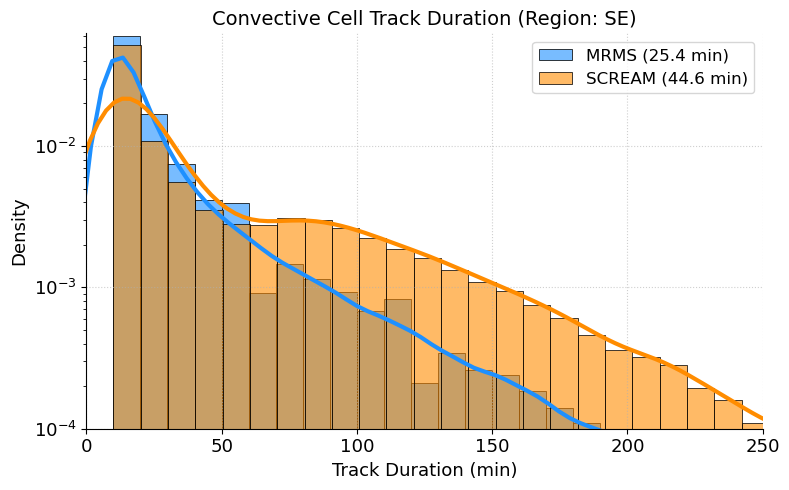

<Axes: title={'center': 'Convective Cell Track Duration (Region: SE)'}, xlabel='Track Duration (min)', ylabel='Density'>

In [19]:
palette = {name_map['o']: 'dodgerblue', name_map['m']: 'darkorange'}

# One row per track (duration is track-level, not time-step-level)
df_tracks = df_all.drop_duplicates(subset=['dataset', 'tracks'])

figname = f'{figdir}HistKDE_CellLifetime_{name_map['m']}_{name_map['o']}_{region}.pdf'

plot_hist_kde(
    df_tracks, var='track_duration_min',
    palette=palette, alpha=0.6,
    binwidth=10, bw_adjust=2,
    xlim=(0, 250), ylim=(1e-4, None), log_scale=True,
    xlabel='Track Duration (min)', unit='min',
    title=f'Convective Cell Track Duration (Region: {region})',
    figname=figname, dpi=200,
)


In [20]:
df_tracks.keys()

Index(['tracks', 'relative_step', 'base_time', 'meanlat', 'meanlon', 'area',
       'cloudnumber', 'track_status', 'track_interruptions',
       'merge_tracknumbers', 'split_tracknumbers', 'core_meanlat',
       'core_meanlon', 'core_mean_y', 'core_mean_x', 'cell_meanlat',
       'cell_meanlon', 'cell_mean_y', 'cell_mean_x', 'core_area', 'cell_area',
       'max_dbz', 'maxETH_10dbz', 'maxETH_20dbz', 'maxETH_30dbz',
       'maxETH_40dbz', 'maxETH_50dbz', 'maxrange_flag', 'relative_time_min',
       'track_duration', 'start_status', 'end_status', 'start_basetime',
       'end_basetime', 'start_split_tracknumber', 'start_split_timeindex',
       'start_split_cloudnumber', 'end_merge_tracknumber',
       'end_merge_timeindex', 'end_merge_cloudnumber', 'original_tracks',
       'track_duration_min', 'dataset'],
      dtype='str')

In [21]:
# df_all.groupby(['dataset', 'tracks'], sort=False)['cell_area'].agg('max')
df_all.groupby(['dataset', 'tracks'], sort=False)['maxETH_10dbz'].agg('max')


dataset  tracks
MRMS     0          8.000000
         1          8.500000
         2          7.000000
         3         13.000000
         4          8.000000
                     ...    
SCREAM   113701     3.453292
         113702     4.795985
         113703     5.102320
         113704     8.618267
         113705     6.620177
Name: maxETH_10dbz, Length: 281759, dtype: float32

In [22]:
# Columns to reduce over the times dimension (exclude metadata / index columns)
meta_cols = ['tracks', 'relative_step', 'relative_time_min',
             'track_duration', 'track_duration_min', 'dataset',
             'start_basetime', 'end_basetime',
             'start_status', 'end_status',
             'merge_tracknumbers', 'split_tracknumbers',
             'start_split_tracknumber', 'start_split_timeindex', 'start_split_cloudnumber', 
             'end_merge_tracknumber', 'end_merge_timeindex', 'end_merge_cloudnumber', 
             'original_tracks', 'cloudnumber', 'track_status', 'track_interruptions',
             ]
stat_cols = [c for c in df_all.columns if c not in meta_cols]

# Compute per-track lifetime statistics (one row per track)
# groupby preserves 'dataset' as a column when it is included in the groupby keys
df_lt = (
    df_all
    .groupby(['dataset', 'tracks'], sort=False)[stat_cols]
    .agg(
        **{f'{c}_ltmax': (c, 'max') for c in stat_cols},  # lifetime maximum
        **{f'{c}_ltmean': (c, 'mean') for c in stat_cols},  # lifetime mean
    )
    .reset_index()
)

# Add track_duration_min back for convenience
df_lt = df_lt.merge(
    df_all[['dataset', 'tracks', 'track_duration_min']].drop_duplicates(),
    on=['dataset', 'tracks'], how='left'
)

# Derive cell diameter from area assuming circular cells: d = 2 * sqrt(area / pi)
for col in [c for c in df_lt.columns if c.startswith('cell_area')]:
    diam_col = col.replace('cell_area', 'cell_diameter')
    df_lt[diam_col] = 2 * np.sqrt(df_lt[col] / np.pi)

print(df_lt.shape)
df_lt.head(3)

(281759, 47)


,dataset,tracks,base_time_ltmax,meanlat_ltmax,meanlon_ltmax,area_ltmax,core_meanlat_ltmax,core_meanlon_ltmax,core_mean_y_ltmax,core_mean_x_ltmax,...,max_dbz_ltmean,maxETH_10dbz_ltmean,maxETH_20dbz_ltmean,maxETH_30dbz_ltmean,maxETH_40dbz_ltmean,maxETH_50dbz_ltmean,maxrange_flag_ltmean,track_duration_min,cell_diameter_ltmax,cell_diameter_ltmean
0,MRMS,0,2025-04-01 00:34:41,35.743065,277.228577,135.0,35.744099,277.228760,1385.0,4023.0,...,36.527390,7.250000,6.250000,3.583333,2.0,NaN,1.0,29.99988,13.110580,11.726460
1,MRMS,1,2025-04-01 00:20:40,34.773464,275.681244,99.0,34.774483,275.681091,1258.0,3900.0,...,36.190891,8.166667,7.666667,5.166667,NaN,NaN,1.0,14.99994,11.227231,10.881695
2,MRMS,2,2025-04-01 00:20:40,34.483692,275.403473,117.0,34.481251,275.400543,1223.0,3879.0,...,38.919083,7.000000,6.250000,4.750000,7.0,NaN,1.0,9.99996,12.205287,11.726460


In [23]:
df_lt.keys()

Index(['dataset', 'tracks', 'base_time_ltmax', 'meanlat_ltmax',
       'meanlon_ltmax', 'area_ltmax', 'core_meanlat_ltmax',
       'core_meanlon_ltmax', 'core_mean_y_ltmax', 'core_mean_x_ltmax',
       'cell_meanlat_ltmax', 'cell_meanlon_ltmax', 'cell_mean_y_ltmax',
       'cell_mean_x_ltmax', 'core_area_ltmax', 'cell_area_ltmax',
       'max_dbz_ltmax', 'maxETH_10dbz_ltmax', 'maxETH_20dbz_ltmax',
       'maxETH_30dbz_ltmax', 'maxETH_40dbz_ltmax', 'maxETH_50dbz_ltmax',
       'maxrange_flag_ltmax', 'base_time_ltmean', 'meanlat_ltmean',
       'meanlon_ltmean', 'area_ltmean', 'core_meanlat_ltmean',
       'core_meanlon_ltmean', 'core_mean_y_ltmean', 'core_mean_x_ltmean',
       'cell_meanlat_ltmean', 'cell_meanlon_ltmean', 'cell_mean_y_ltmean',
       'cell_mean_x_ltmean', 'core_area_ltmean', 'cell_area_ltmean',
       'max_dbz_ltmean', 'maxETH_10dbz_ltmean', 'maxETH_20dbz_ltmean',
       'maxETH_30dbz_ltmean', 'maxETH_40dbz_ltmean', 'maxETH_50dbz_ltmean',
       'maxrange_flag_ltmean',

Figure saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/HistKDE_CellMaxDiameter_SCREAM_MRMS_SE.pdf


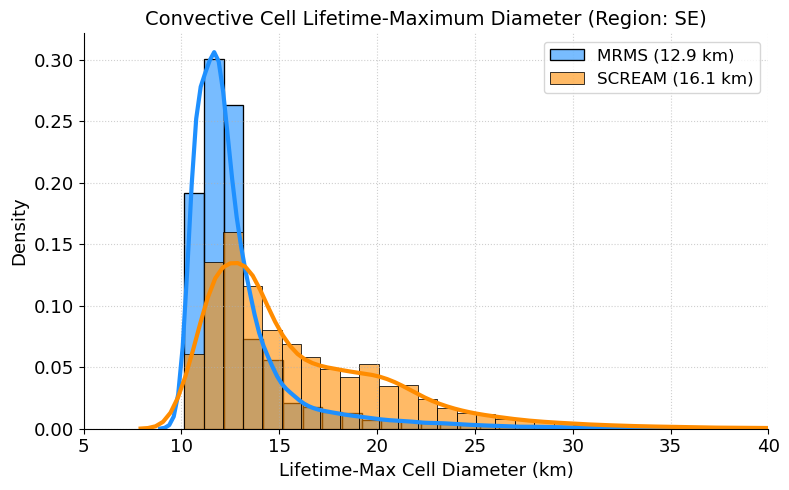

<Axes: title={'center': 'Convective Cell Lifetime-Maximum Diameter (Region: SE)'}, xlabel='Lifetime-Max Cell Diameter (km)', ylabel='Density'>

In [24]:
figname = f'{figdir}HistKDE_CellMaxDiameter_{name_map['m']}_{name_map['o']}_{region}.pdf'

plot_hist_kde(
    df_lt, var='cell_diameter_ltmax',
    palette=palette,
    binwidth=1, bw_adjust=1.5,
    xlim=(5, 40),
    xlabel='Lifetime-Max Cell Diameter (km)', unit='km',
    title=f'Convective Cell Lifetime-Maximum Diameter (Region: {region})',
    figname=figname, dpi=200,    
)


Figure saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/HistKDE_CellMaxReflectivity_SCREAM_MRMS_SE.pdf


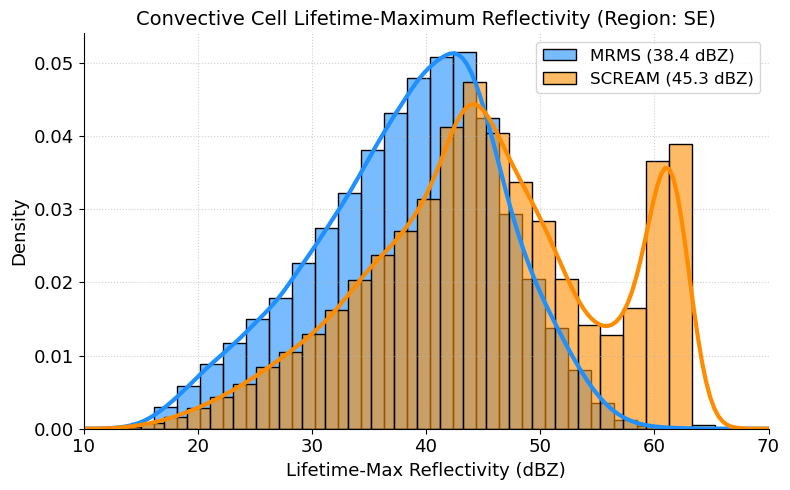

<Axes: title={'center': 'Convective Cell Lifetime-Maximum Reflectivity (Region: SE)'}, xlabel='Lifetime-Max Reflectivity (dBZ)', ylabel='Density'>

In [25]:
figname = f'{figdir}HistKDE_CellMaxReflectivity_{name_map['m']}_{name_map['o']}_{region}.pdf'

plot_hist_kde(
    df_lt, var='max_dbz_ltmax',
    palette=palette,
    binwidth=2, bw_adjust=1.5,
    xlim=(10, 70),
    xlabel='Lifetime-Max Reflectivity (dBZ)', unit='dBZ',
    title=f'Convective Cell Lifetime-Maximum Reflectivity (Region: {region})',
    figname=figname, dpi=200,
)


Figure saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/HistKDE_CellMaxETH10dBZ_SCREAM_MRMS_SE.pdf


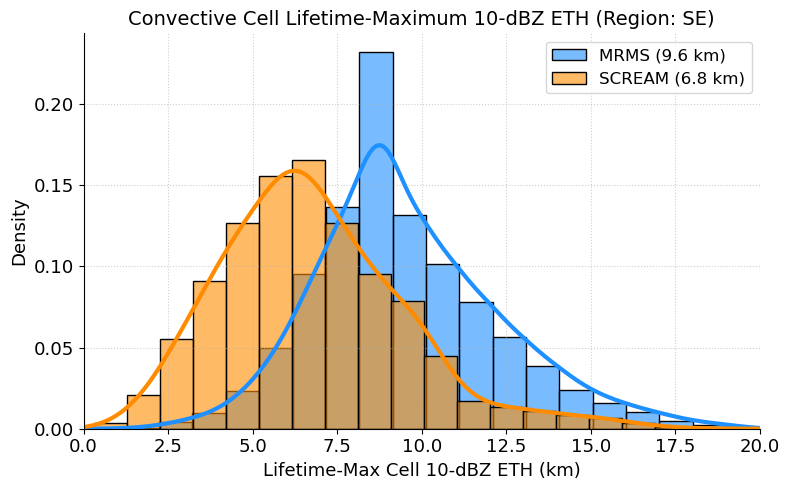

<Axes: title={'center': 'Convective Cell Lifetime-Maximum 10-dBZ ETH (Region: SE)'}, xlabel='Lifetime-Max Cell 10-dBZ ETH (km)', ylabel='Density'>

In [26]:
figname = f'{figdir}HistKDE_CellMaxETH10dBZ_{name_map['m']}_{name_map['o']}_{region}.pdf'

plot_hist_kde(
    df_lt, var='maxETH_10dbz_ltmax',
    palette=palette,
    binwidth=1, bw_adjust=2.5,
    xlim=(0, 20),
    xlabel='Lifetime-Max Cell 10-dBZ ETH (km)', unit='km',
    title=f'Convective Cell Lifetime-Maximum 10-dBZ ETH (Region: {region})',
    figname=figname, dpi=200,
)


Figure saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/HistKDE_CellMaxETH30dBZ_SCREAM_MRMS_SE.pdf


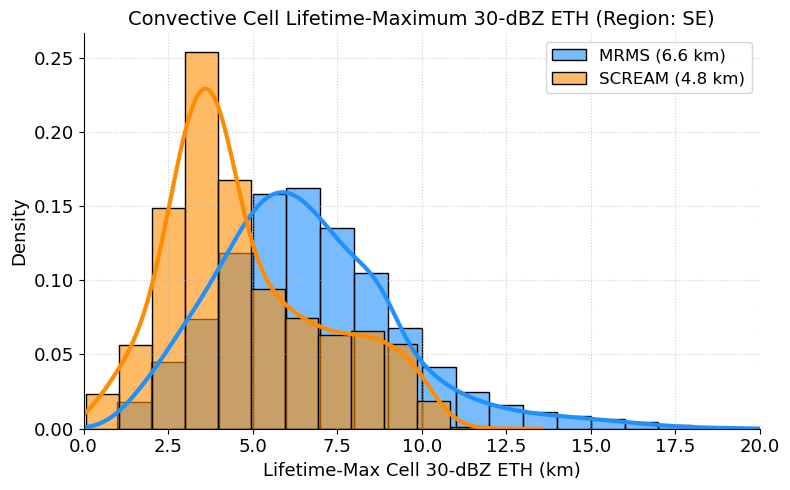

<Axes: title={'center': 'Convective Cell Lifetime-Maximum 30-dBZ ETH (Region: SE)'}, xlabel='Lifetime-Max Cell 30-dBZ ETH (km)', ylabel='Density'>

In [27]:
figname = f'{figdir}HistKDE_CellMaxETH30dBZ_{name_map['m']}_{name_map['o']}_{region}.pdf'

plot_hist_kde(
    df_lt, var='maxETH_30dbz_ltmax',
    palette=palette,
    binwidth=1, bw_adjust=2.5,
    xlim=(0, 20),
    xlabel='Lifetime-Max Cell 30-dBZ ETH (km)', unit='km',
    title=f'Convective Cell Lifetime-Maximum 30-dBZ ETH (Region: {region})',
    figname=figname, dpi=200,
)


MRMS: mode init lon = -88.3°  →  UTC-6
SCREAM: mode init lon = -83.2°  →  UTC-6
Figure saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/HistKDE_DiurnalCycle_SCREAM_MRMS_SE.pdf


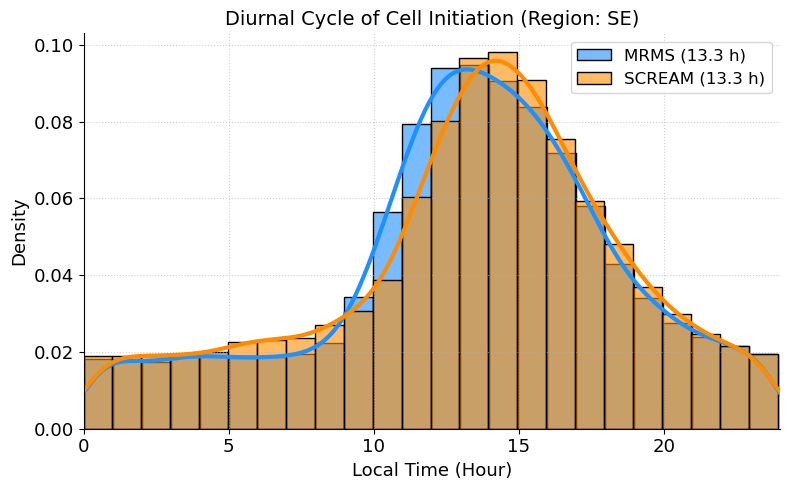

<Axes: title={'center': 'Diurnal Cycle of Cell Initiation (Region: SE)'}, xlabel='Local Time (Hour)', ylabel='Density'>

In [28]:
# ── Diurnal cycle of cell initiation hour ─────────────────────────────────────
# Use first time step of each track (relative_step == 0) for:
#   - initiation UTC hour  (from start_basetime, which is broadcast per-track)
#   - initiation longitude (from meanlon at that time step)
df_init = (
    df_all[df_all['relative_step'] == 0]
    [['dataset', 'tracks', 'start_basetime', 'meanlon']]
    .copy()
)

# Decimal UTC hour: hour + minute/60 + second/3600
_dt = pd.to_datetime(df_init['start_basetime'])
df_init['hour_utc'] = _dt.dt.hour + _dt.dt.minute / 60 + _dt.dt.second / 3600

# Convert 0–360° longitude to signed (-180 to 180) before computing LT offset
df_init['meanlon_signed'] = df_init['meanlon'].apply(lambda x: x - 360 if x > 180 else x)

# Local Time offset per dataset: mode initiation longitude → nearest 15° timezone strip
lt_offset = {}
for ds_name, grp in df_init.groupby('dataset'):
    mode_lon = grp['meanlon_signed'].mode().iloc[0]
    lt_offset[ds_name] = round(mode_lon / 15)
    print(f"{ds_name}: mode init lon = {mode_lon:.1f}°  →  UTC{lt_offset[ds_name]:+d}")

df_init['lt_offset'] = df_init['dataset'].map(lt_offset)
df_init['hour_lt']   = (df_init['hour_utc'] + df_init['lt_offset']) % 24

figname_diurnal = f'{figdir}HistKDE_DiurnalCycle_{name_map["m"]}_{name_map["o"]}_{region}.pdf'

plot_hist_kde(
    df_init, var='hour_lt',
    palette=palette,
    binwidth=1, bw_adjust=1.5,
    xlim=(0, 24),
    xlabel='Local Time (Hour)', unit='h',
    title=f'Diurnal Cycle of Cell Initiation (Region: {region})',
    figsize=(8, 5), dpi=200,
    figname=figname_diurnal,
)


## Track Initiation Location Map

KDE-smoothed 2-D density map of SCREAM and MRMS convective-cell initiation locations over the selected region.

### Cell initiation location density map

Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/Map_InitLocation_SCREAM_MRMS_SE.png


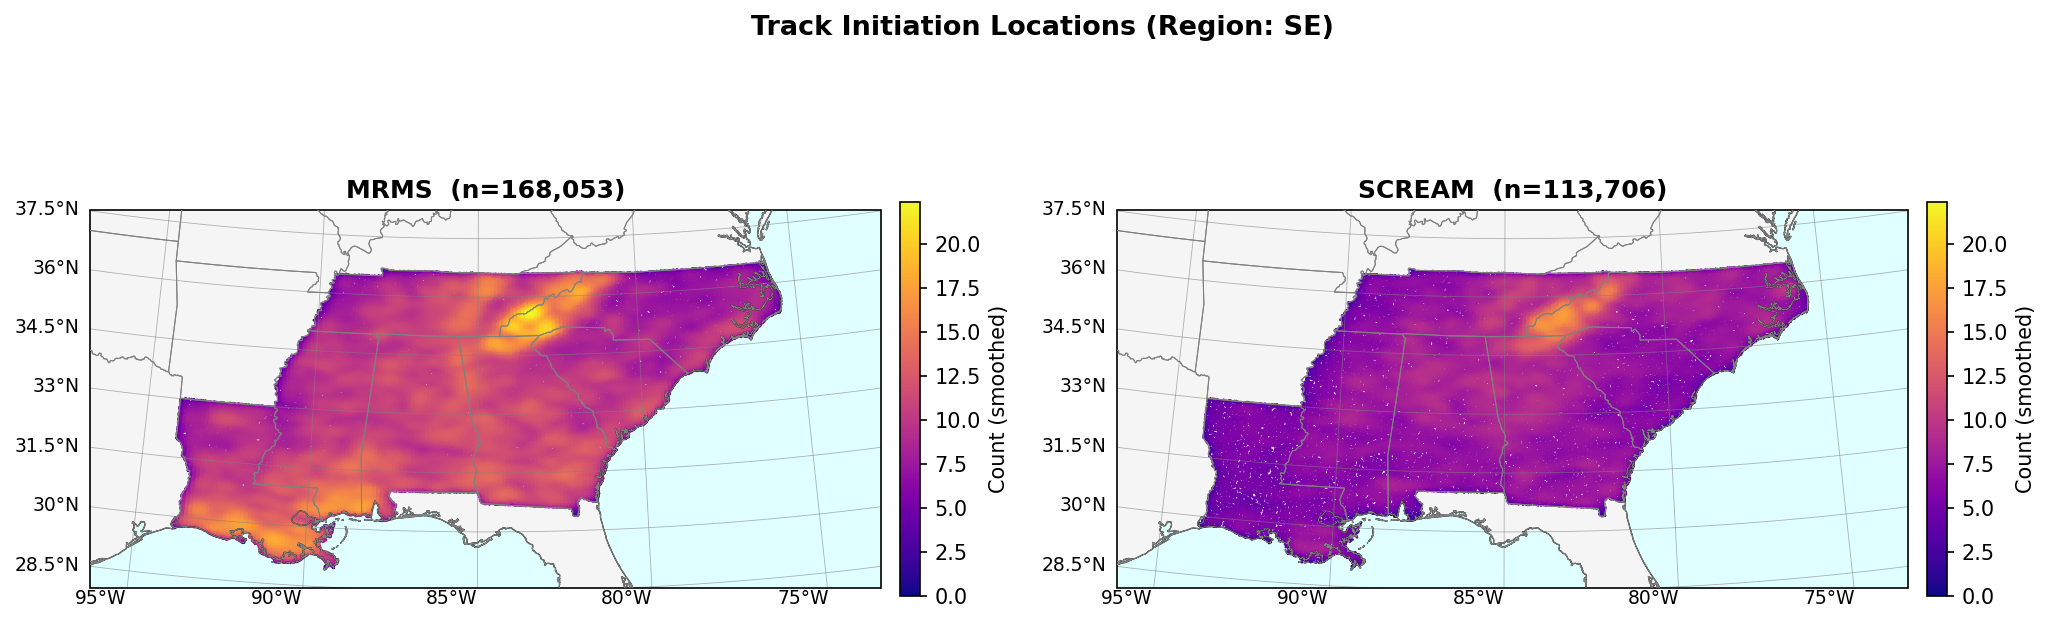

In [29]:
# ── Map of track initiation locations, color-coded by density ─────────────────
lon_buf      = 2.0    # degree longitude buffer around data extent
lat_buf      = 1.0    # degree latitude buffer
density_bins = 200    # 2D histogram grid resolution (higher = finer pattern)
smooth_sigma = 2    # Gaussian smoothing sigma applied to the histogram grid

# First time step of each track: initiation lat/lon
df_map = (
    df_all[df_all['relative_step'] == 0]
    [['dataset', 'tracks', 'meanlat', 'meanlon']]
    .copy()
)
df_map['lon'] = df_map['meanlon'].apply(lambda x: x - 360 if x > 180 else x)
df_map['lat'] = df_map['meanlat']

# Shared map extent (both datasets) + buffer
lon_min = df_map['lon'].min() - lon_buf
lon_max = df_map['lon'].max() + lon_buf
lat_min = df_map['lat'].min() - lat_buf
lat_max = df_map['lat'].max() + lat_buf

lon_edges = np.linspace(lon_min, lon_max, density_bins + 1)
lat_edges = np.linspace(lat_min, lat_max, density_bins + 1)

def grid_density(lons, lats):
    """
    Fast O(N) density estimate: bin points onto a 2D histogram grid,
    apply light Gaussian smoothing, then look up each point's smoothed bin count.
    Replaces gaussian_kde (O(N²)) — effectively instant for 100k+ points.
    """
    counts, _, _ = np.histogram2d(lons, lats, bins=[lon_edges, lat_edges])
    counts_sm = gaussian_filter(counts, sigma=smooth_sigma)
    xi = np.clip(np.digitize(lons, lon_edges) - 1, 0, density_bins - 1)
    yi = np.clip(np.digitize(lats, lat_edges) - 1, 0, density_bins - 1)
    return counts_sm[xi, yi]

# Pre-compute density for both datasets → shared color scale
datasets  = [name_map['o'], name_map['m']]   # MRMS left, SCREAM right
densities = {ds: grid_density(df_map.loc[df_map['dataset'] == ds, 'lon'].values,
                               df_map.loc[df_map['dataset'] == ds, 'lat'].values)
             for ds in datasets}
vmax = max(d.max() for d in densities.values())

proj     = ccrs.LambertConformal(central_longitude=(lon_min + lon_max) / 2,
                                  central_latitude=(lat_min + lat_max) / 2)
data_crs = ccrs.PlateCarree()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150,
                         subplot_kw={'projection': proj})

for ax, ds_label in zip(axes, datasets):
    sub     = df_map[df_map['dataset'] == ds_label]
    lons    = sub['lon'].values
    lats    = sub['lat'].values
    density = densities[ds_label]
    order   = np.argsort(density)   # densest points drawn on top

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=data_crs)
    # ax.set_aspect('auto', adjustable=None)

    # Background features below the dots (low zorder)
    ax.add_feature(cfeature.LAND,  facecolor='whitesmoke', zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='lightcyan',  zorder=1)

    sc = ax.scatter(
        lons[order], lats[order],
        c=density[order], cmap='plasma',
        vmin=0, vmax=vmax,
        s=1.5, linewidths=0,
        transform=data_crs, zorder=2,
    )

    # Borders / states drawn on top of the dots
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='black', zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.5, edgecolor='black', zorder=3)
    ax.add_feature(cfeature.STATES,    linewidth=0.5, edgecolor='gray',  zorder=3)

    plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02,
                 label='Count (smoothed)', shrink=0.6)
    ax.set_title(f'{ds_label}  (n={len(sub):,})', fontsize=12, weight='bold')

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                      alpha=0.6, x_inline=False, y_inline=False)
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'rotation': 0, 'fontsize': 9}
    gl.ylabel_style = {'rotation': 0, 'fontsize': 9}

fig.suptitle(f'Track Initiation Locations (Region: {region})',
             fontsize=13, weight='bold')
plt.tight_layout()

figname_initmap = f'{figdir}Map_InitLocation_{name_map["m"]}_{name_map["o"]}_{region}.png'
fig.savefig(figname_initmap, bbox_inches='tight', dpi=150)
print(f'Saved: {figname_initmap}')
plt.show()


## Joint KDE + Marginal KDE Analysis

In [30]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [31]:
def jointKDE_MxN(nrow, ncol, data, margin_space=0.01, levels=None, gridsize=None, bw_adjust=None,
                 cmap=None, lcolors=None, suptitle=None, fontsize=None,
                 titles=None, xlims=None, ylims=None, xlabels=None, ylabels=None, legend_loc='best', legend_labels=None, 
                 wspace=0.5, hspace=0.5,
                 dpi=300, figsize=None, figname=None):
    
    # mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['font.size'] = fontsize

    if figsize is None: figsize=(6 * ncol, 6 * nrow)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = gridspec.GridSpec(nrow, ncol, wspace=wspace, hspace=hspace)
    
    cmap = copy.copy(mpl.cm.get_cmap(cmap))
    lw_joint = 2
    lw_fit = 5

    # Create a KDE plot with marginals for each cell in the grid
    for row in range(nrow):
        for col in range(ncol):
            # idx = i * ncol + j
            # x, y = data[idx]
            if (data[row][col] is not None):
                x_o, y_o = data[row][col]['o']
                x_m, y_m = data[row][col]['m']
                lc_m = lcolors['m']
                # legend_lab = legend_labels[row][col]
                # legend_m = legend_labels[row][col]

                # Set up main axes for joint KDE plot in the GridSpec layout
                ax_joint = fig.add_subplot(gs[row, col])

                # Plot joint KDE
                sns.kdeplot(x=x_o, y=y_o, levels=levels, fill=True, cmap=cmap, alpha=0.9, ax=ax_joint, gridsize=gridsize, bw_adjust=bw_adjust)
                sns.kdeplot(x=x_m, y=y_m, color=lc_m, levels=levels, linewidths=lw_joint, fill=False, ax=ax_joint, gridsize=gridsize, bw_adjust=bw_adjust)
                ax_joint.set_xlabel(xlabels[row][col])
                ax_joint.set_ylabel(ylabels[row][col])
                ax_joint.grid(ls=':')
                
                # Linear regression (OBS)
                mask = ~np.isnan(x_o) & ~np.isnan(y_o)
                linfit = linregress(x=x_o[mask], y=y_o[mask])
                # yfit line values
                xfit = np.linspace(np.nanmin(x_o), np.nanmax(x_o), 100)
                yfit = linfit[0] * xfit + linfit[1]
                # yfit_label = f"Corr: {linfit[2]:.02f}"
                yfit_label_o = f"Corr: {linfit[2]:.02f}, Slope: {linfit[0]:.02f}"
                ax_joint.plot(xfit, yfit, color=lcolors['o'], lw=lw_fit, label=yfit_label_o, zorder=5)

                # Linear regression (MODEL)
                mask = ~np.isnan(x_m) & ~np.isnan(y_m)
                linfit = linregress(x=x_m[mask], y=y_m[mask])
                # yfit line values
                xfit = np.linspace(np.nanmin(x_m), np.nanmax(x_m), 100)
                yfit = linfit[0] * xfit + linfit[1]
                # yfit_label = f"Corr: {linfit[2]:.02f}"
                yfit_label_m = f"Corr: {linfit[2]:.02f}, Slope: {linfit[0]:.02f}"
                ax_joint.plot(xfit, yfit, color=lc_m, lw=lw_fit, label=yfit_label_m, zorder=5)
                
                # Create marginal axes with a small space between them and ax_joint
                pos = ax_joint.get_position()
                ax_marg_x = fig.add_axes([pos.x0, pos.y1 + margin_space, pos.width, 0.2 * pos.height])
                ax_marg_y = fig.add_axes([pos.x1 + margin_space, pos.y0, 0.2 * pos.width, pos.height])
                ax_marg_x.grid(axis='x', ls=':')
                ax_marg_y.grid(axis='y', ls=':')
                
                # Set x and y limits for ax_joint and apply to the marginal plots
                if xlims:
                    ax_joint.set_xlim(xlims[row][col])
                    ax_marg_x.set_xlim(xlims[row][col])
                if ylims:
                    ax_joint.set_ylim(ylims[row][col])
                    ax_marg_y.set_ylim(ylims[row][col])

                # Plot marginal KDEs on the marginal axes
                sns.kdeplot(x=x_o, ax=ax_marg_x, color=lcolors['o'], lw=lw_joint, fill=False, gridsize=gridsize, bw_adjust=bw_adjust)
                sns.kdeplot(y=y_o, ax=ax_marg_y, color=lcolors['o'], lw=lw_joint, fill=False, gridsize=gridsize, bw_adjust=bw_adjust)
                sns.kdeplot(x=x_m, ax=ax_marg_x, color=lc_m, lw=lw_joint, fill=False, gridsize=gridsize, bw_adjust=bw_adjust)
                sns.kdeplot(y=y_m, ax=ax_marg_y, color=lc_m, lw=lw_joint, fill=False, gridsize=gridsize, bw_adjust=bw_adjust)
                
                # # Adjust ylim of marginal plots to avoid cutting off the KDE line
                # y_lim_x = ax_marg_x.get_ylim()
                # ax_marg_x.set_ylim(y_lim_x[0] * 1.1, y_lim_x[1] * 1.1)  # Increase upper limit by 10%
                # y_lim_y = ax_marg_y.get_xlim()
                # ax_marg_y.set_xlim(y_lim_y[0] * 1.1, y_lim_y[1] * 1.1)  # Increase upper limit by 10%
                
                # Add title within the ax_joint at the upper left corner
                ax_joint.text(
                    0.02, 0.98,  # Position in axis coordinates
                    titles[row][col],
                    ha='left', va='top',
                    transform=ax_joint.transAxes,
                    # fontsize=12,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
                )
                
                # Legends
                # ax_joint.legend(loc=legend_loc)
                legend_elements = [mpl.patches.Patch(facecolor=cmap(0.2), edgecolor='gray'),
                                   mpl.lines.Line2D([0], [0], color=lc_m, lw=lw_joint)]
                _legend_labels = [f"{legend_labels[row][col][0]} ({yfit_label_o})",
                                  f"{legend_labels[row][col][1]} ({yfit_label_m})"]
                ax_joint.legend(handles=legend_elements, labels=_legend_labels, 
                                loc=legend_loc, facecolor='w', 
                                prop={'size': fontsize*0.8},
                                # prop={'family':'Helvetica', 'size':18},
                               )

                # Remove tick labels and borders on the marginal plots
                ax_marg_x.set(yticks=[], ylabel=None)
                ax_marg_x.set_xticklabels([])  # Remove x-axis tick labels
                ax_marg_y.set(xticks=[], xlabel=None)
                ax_marg_y.set_yticklabels([])  # Remove y-axis tick labels
                ax_marg_x.tick_params(left=False, bottom=False)
                ax_marg_y.tick_params(left=False, bottom=False)
                # Show only the bottom spine (x-axis) for ax_marg_x and left spine (y-axis) for ax_marg_y
                ax_marg_x.spines['top'].set_visible(False)
                ax_marg_x.spines['right'].set_visible(False)
                ax_marg_x.spines['left'].set_visible(False)
                ax_marg_y.spines['top'].set_visible(False)
                ax_marg_y.spines['right'].set_visible(False)
                ax_marg_y.spines['bottom'].set_visible(False)
                # # Hide all spines
                # for spine in ax_marg_x.spines.values():
                #     spine.set_visible(False)
                # for spine in ax_marg_y.spines.values():
                #     spine.set_visible(False)

    if (suptitle): fig.suptitle(suptitle, weight='bold')
    fig.savefig(figname, bbox_inches='tight', dpi=dpi, facecolor='w')
    return fig

Month counts per dataset:
month        4      5      6      7      8
dataset                                   
MRMS     17741  27757  38530  45811  38214
SCREAM   13662  24414  23519  22389  29722
  Apr: MRMS=17741, SCREAM=13662 tracks
  May: MRMS=27757, SCREAM=24414 tracks
  Jun: MRMS=38530, SCREAM=23519 tracks
  Jul: MRMS=45811, SCREAM=22389 tracks
  Aug: MRMS=38214, SCREAM=29722 tracks
Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/JointKDE_CellDiameter_vs_ETH10dBZ_byMonth_SCREAM_vs_MRMS_SE.pdf


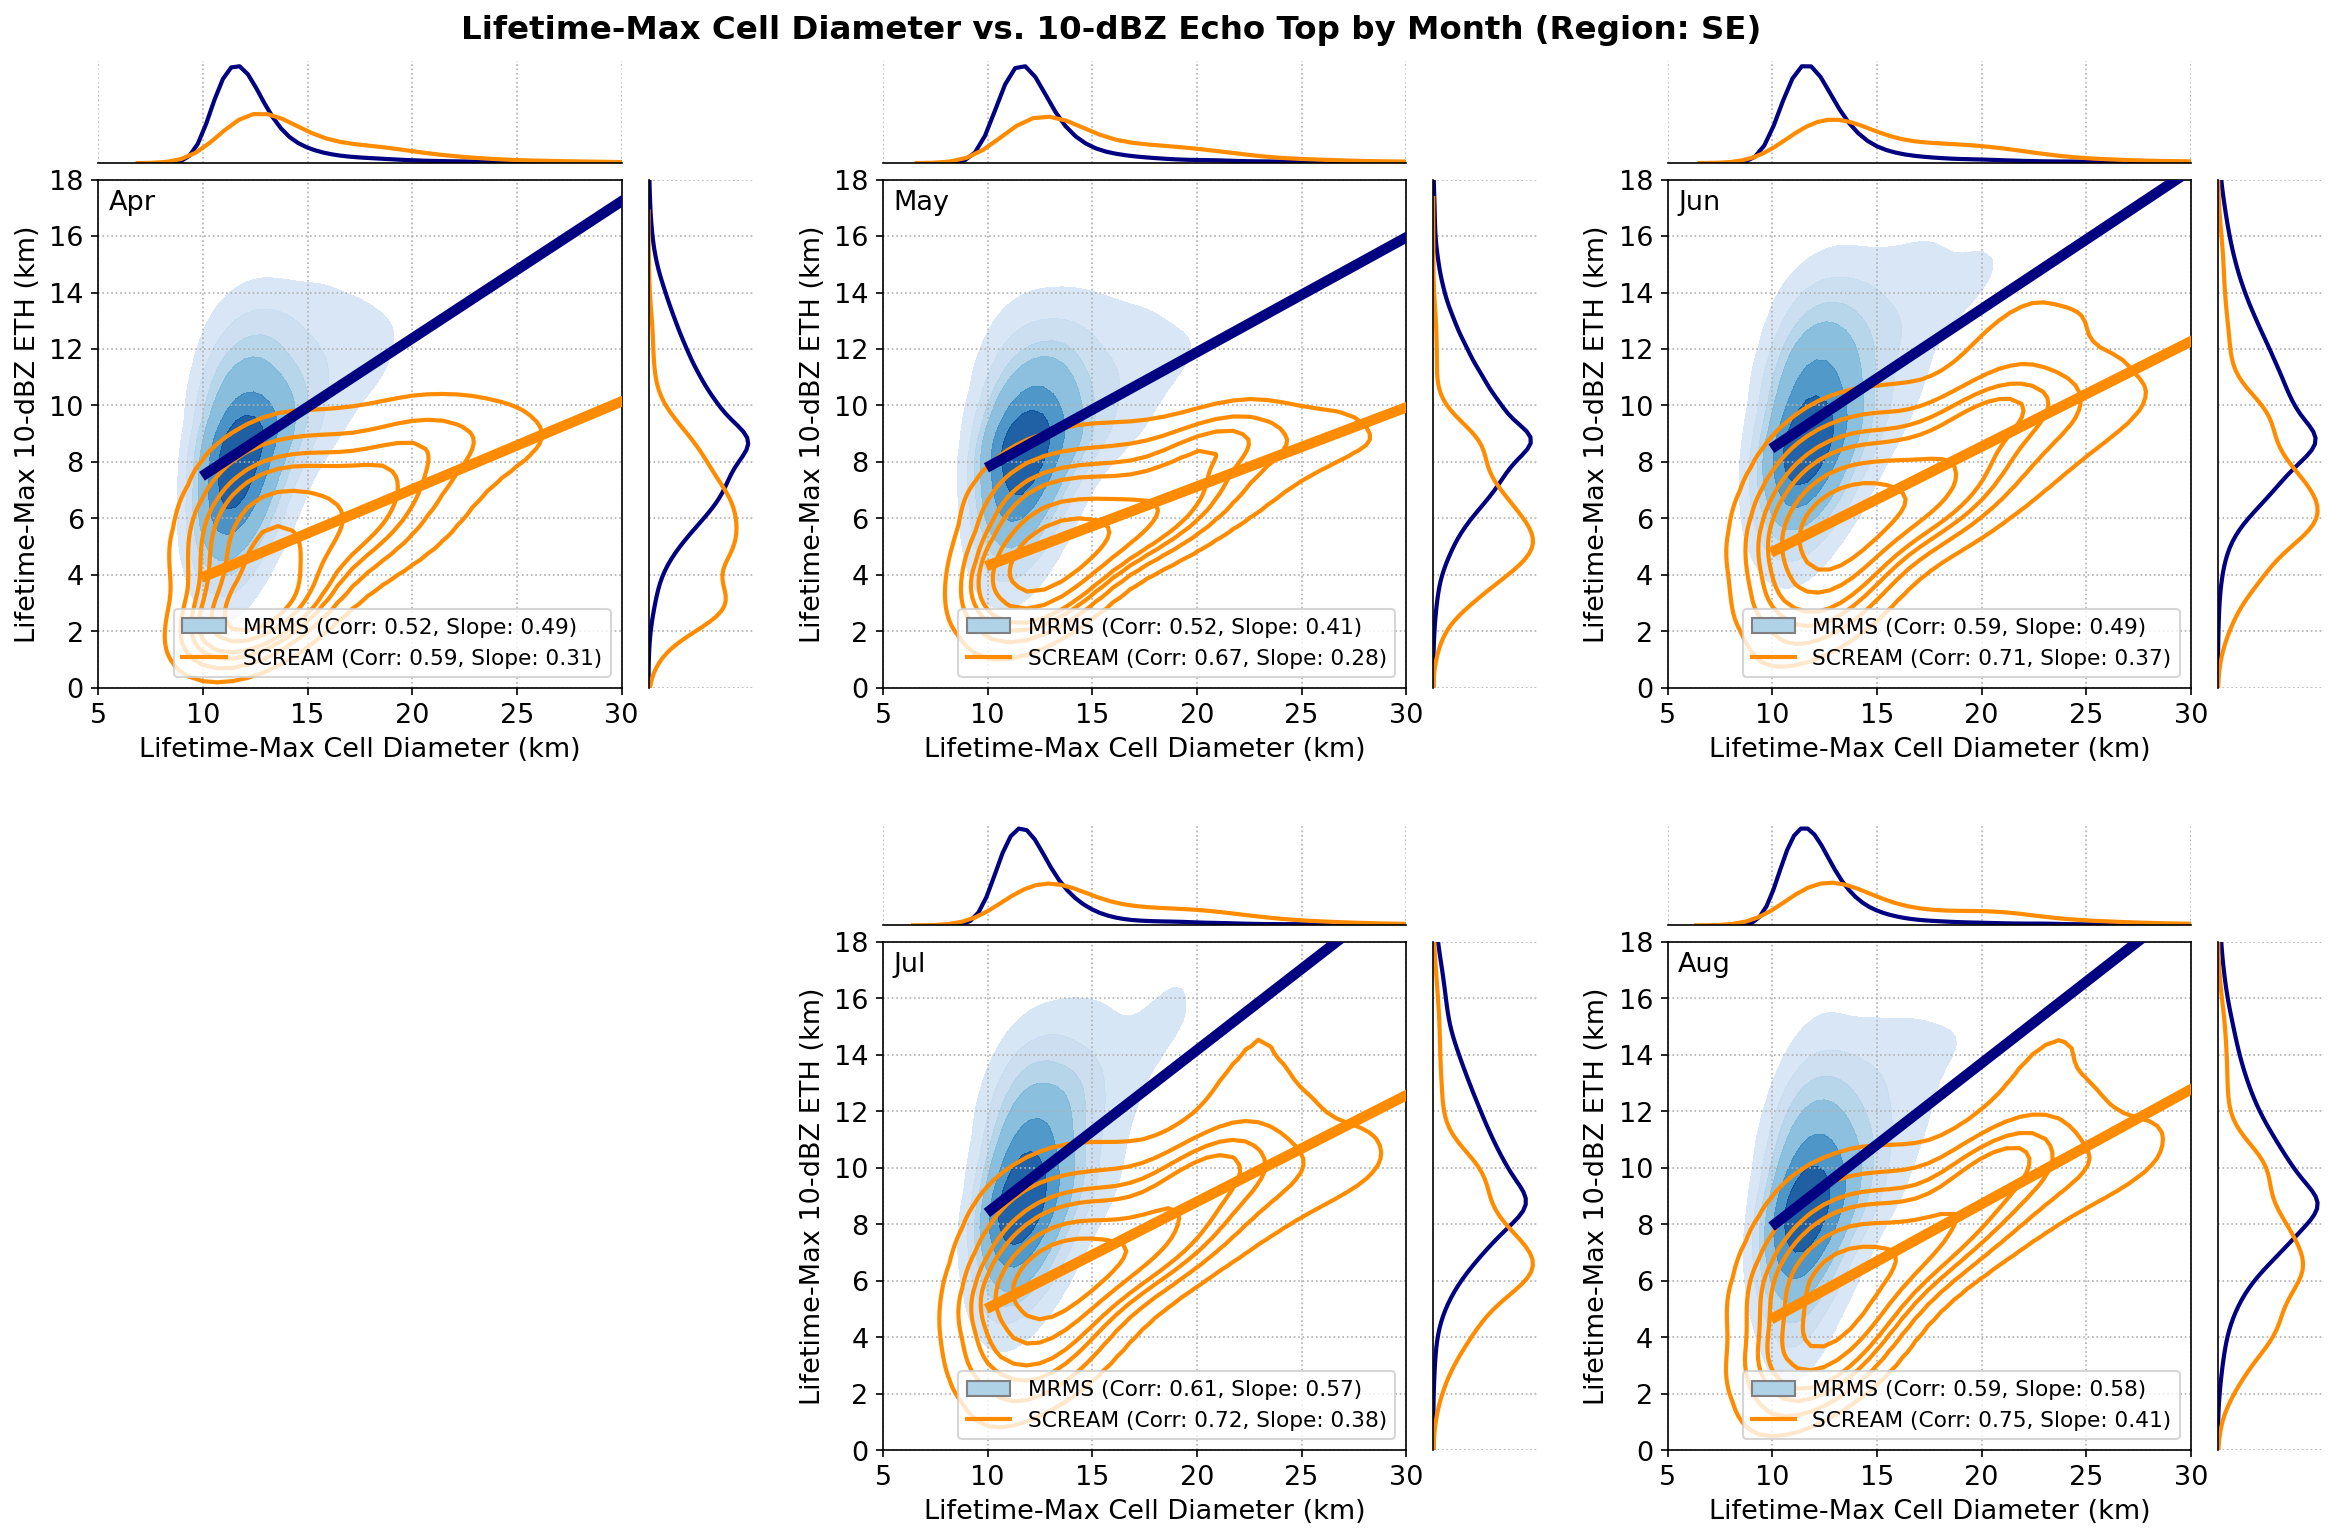

In [32]:
# ── 1. Add month column to df_lt (based on start_basetime of each track) ────────
# Always recompute from the current df_all to stay in sync with any file updates.
sbt = (
    df_all[['dataset', 'tracks', 'start_basetime']]
    .drop_duplicates(subset=['dataset', 'tracks'])
)
# Drop stale columns if present (so merge doesn't produce duplicates on re-run)
df_lt = df_lt.drop(columns=[c for c in ['start_basetime', 'month'] if c in df_lt.columns])
df_lt = df_lt.merge(sbt, on=['dataset', 'tracks'], how='left')
df_lt['month'] = df_lt['start_basetime'].dt.month

print("Month counts per dataset:")
print(df_lt.groupby(['dataset', 'month']).size().unstack(fill_value=0))

# ── 2. Downsample helper ─────────────────────────────────────────────────────────
def downsample_for_kde(x, y, max_points=10000, seed=42):
    """Randomly subsample (x, y) arrays to at most max_points rows."""
    n = len(x)
    if n <= max_points:
        return x, y
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=max_points, replace=False)
    return x[idx], y[idx]

# ── 3. Build data structure for 2×3 panel layout ────────────────────────────────
# Layout:  Row 0 → Apr, May, Jun  (cols 0-2)
#          Row 1 → [empty], Jul, Aug  (cols 0-2)

nrow, ncol = 2, 3
max_points = 10000
month_names = {4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug'}

xvar = 'cell_diameter_ltmax'   # lifetime-max cell diameter
yvar = 'maxETH_10dbz_ltmax'    # lifetime-max 10-dBZ echo-top

df_o_lt = df_lt[df_lt['dataset'] == name_map['o']]
df_m_lt = df_lt[df_lt['dataset'] == name_map['m']]

data          = [[None]*ncol for _ in range(nrow)]
titles        = [[None]*ncol for _ in range(nrow)]
xlims         = [[None]*ncol for _ in range(nrow)]
ylims         = [[None]*ncol for _ in range(nrow)]
xlabels       = [[None]*ncol for _ in range(nrow)]
ylabels       = [[None]*ncol for _ in range(nrow)]
legend_labels = [[None]*ncol for _ in range(nrow)]

month_grid = [[4, 5, 6], [None, 7, 8]]   # None → empty panel

for row in range(nrow):
    for col in range(ncol):
        month = month_grid[row][col]
        if month is None:
            continue   # leave data[row][col] = None (empty panel)

        sub_o = df_o_lt[df_o_lt['month'] == month].dropna(subset=[xvar, yvar])
        sub_m = df_m_lt[df_m_lt['month'] == month].dropna(subset=[xvar, yvar])
        print(f"  {month_names[month]}: {name_map['o']}={len(sub_o)}, {name_map['m']}={len(sub_m)} tracks")

        x_o, y_o = downsample_for_kde(sub_o[xvar].values, sub_o[yvar].values, max_points)
        x_m, y_m = downsample_for_kde(sub_m[xvar].values, sub_m[yvar].values, max_points)

        data[row][col]          = {'o': (x_o, y_o), 'm': (x_m, y_m)}
        titles[row][col]        = month_names[month]
        xlims[row][col]         = (5, 30)
        ylims[row][col]         = (0, 18)
        xlabels[row][col]       = 'Lifetime-Max Cell Diameter (km)'
        ylabels[row][col]       = 'Lifetime-Max 10-dBZ ETH (km)'
        legend_labels[row][col] = [name_map['o'], name_map['m']]

# ── 4. Color / style settings ────────────────────────────────────────────────────
levels = [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]
cmap   = truncate_colormap(plt.get_cmap('Blues'), 0.15, 1.0)
lcolors = {
    'o':  'navy',
    'm': 'darkorange',
}

# ── 5. Plot ──────────────────────────────────────────────────────────────────────
figname = f'{figdir}JointKDE_CellDiameter_vs_ETH10dBZ_byMonth_{name_map["m"]}_vs_{name_map["o"]}_{region}.pdf'

fig = jointKDE_MxN(
    nrow=nrow, ncol=ncol,
    data=data,
    margin_space=0.01,
    levels=levels,
    gridsize=100,
    bw_adjust=1.5,
    cmap=cmap,
    lcolors=lcolors,
    suptitle=f'Lifetime-Max Cell Diameter vs. 10-dBZ Echo Top by Month (Region: {region})',
    fontsize=13,
    titles=titles,
    xlims=xlims,
    ylims=ylims,
    xlabels=xlabels,
    ylabels=ylabels,
    legend_loc='lower right',
    legend_labels=legend_labels,
    wspace=0.5, hspace=0.5,
    dpi=150,
    figsize=(18, 11),
    figname=figname,
)
print(f"Saved: {figname}")


  Apr: MRMS=14278, SCREAM=12115 tracks
  May: MRMS=22574, SCREAM=22481 tracks
  Jun: MRMS=33227, SCREAM=21915 tracks
  Jul: MRMS=39354, SCREAM=20849 tracks
  Aug: MRMS=30727, SCREAM=27203 tracks
Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/JointKDE_CellDiameter_vs_ETH30dBZ_byMonth_SCREAM_vs_MRMS_SE.pdf


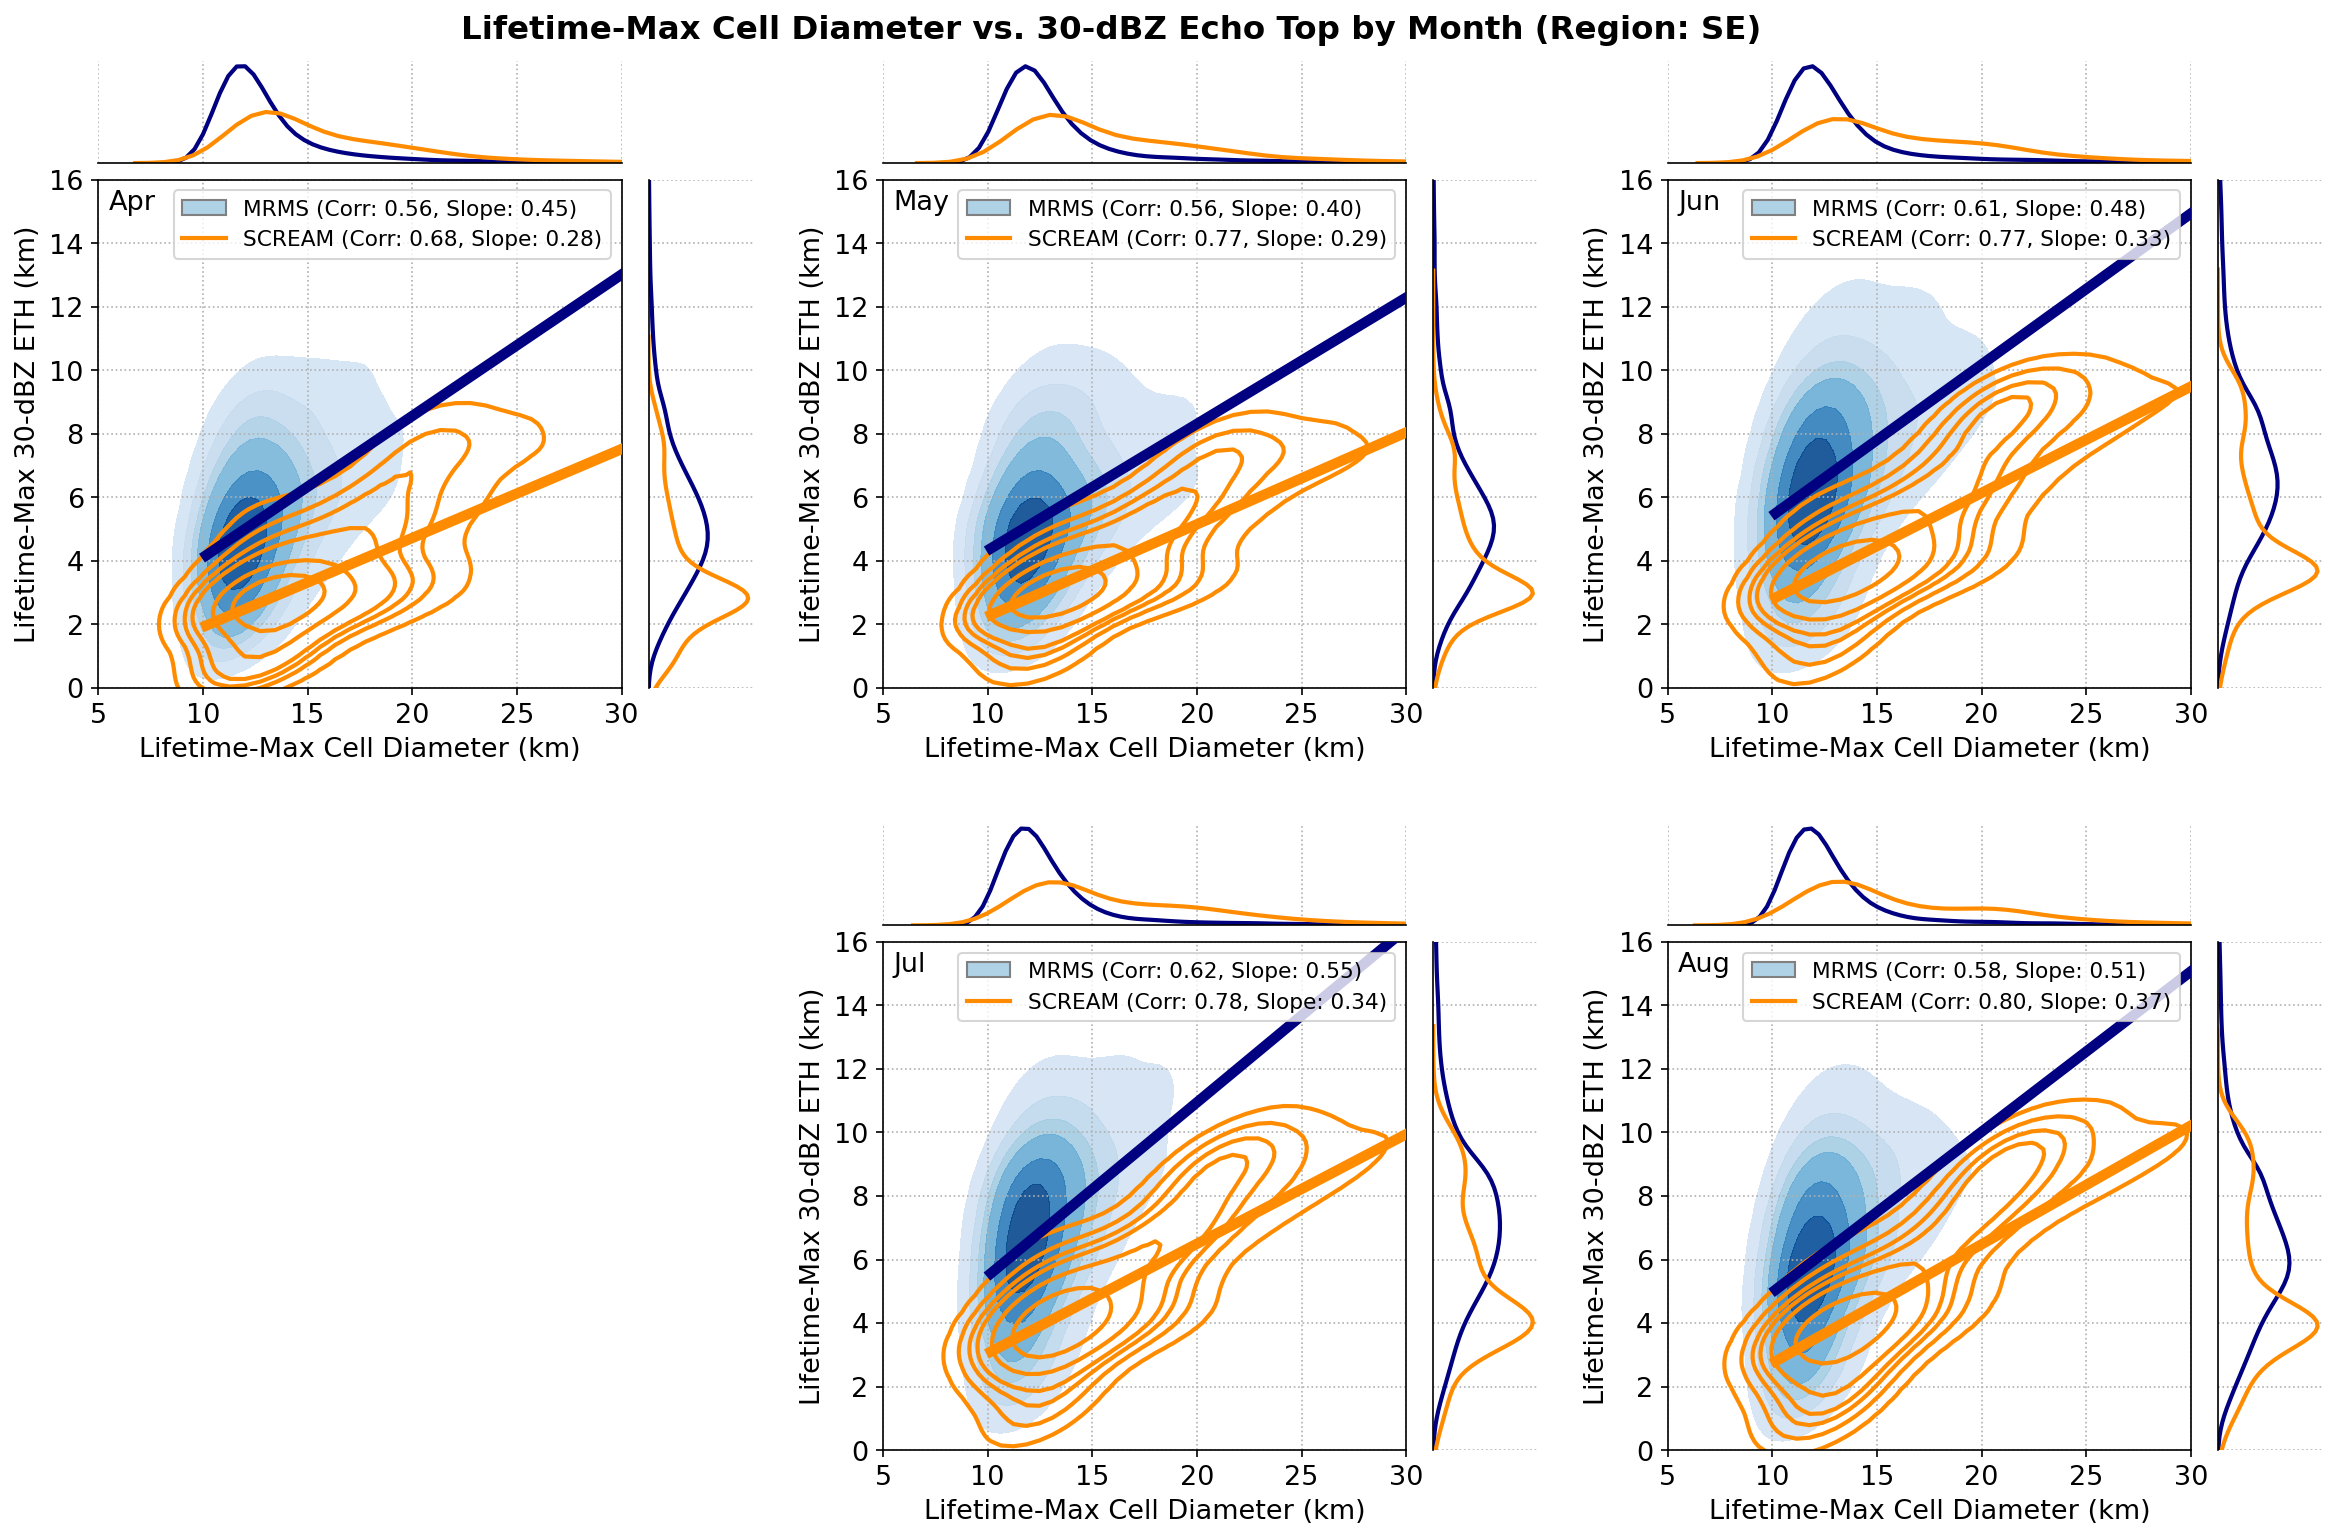

In [33]:
# Layout:  Row 0 → Apr, May, Jun  (cols 0-2)
#          Row 1 → [empty], Jul, Aug  (cols 0-2)

nrow, ncol = 2, 3
max_points = 10000
month_names = {4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug'}

xvar = 'cell_diameter_ltmax'   # lifetime-max cell diameter
yvar = 'maxETH_30dbz_ltmax'    # lifetime-max 30-dBZ echo-top

df_o_lt = df_lt[df_lt['dataset'] == name_map['o']]
df_m_lt = df_lt[df_lt['dataset'] == name_map['m']]

data          = [[None]*ncol for _ in range(nrow)]
titles        = [[None]*ncol for _ in range(nrow)]
xlims         = [[None]*ncol for _ in range(nrow)]
ylims         = [[None]*ncol for _ in range(nrow)]
xlabels       = [[None]*ncol for _ in range(nrow)]
ylabels       = [[None]*ncol for _ in range(nrow)]
legend_labels = [[None]*ncol for _ in range(nrow)]

month_grid = [[4, 5, 6], [None, 7, 8]]   # None → empty panel

for row in range(nrow):
    for col in range(ncol):
        month = month_grid[row][col]
        if month is None:
            continue   # leave data[row][col] = None (empty panel)

        sub_o = df_o_lt[df_o_lt['month'] == month].dropna(subset=[xvar, yvar])
        sub_m = df_m_lt[df_m_lt['month'] == month].dropna(subset=[xvar, yvar])
        print(f"  {month_names[month]}: {name_map['o']}={len(sub_o)}, {name_map['m']}={len(sub_m)} tracks")

        x_o, y_o = downsample_for_kde(sub_o[xvar].values, sub_o[yvar].values, max_points)
        x_m, y_m = downsample_for_kde(sub_m[xvar].values, sub_m[yvar].values, max_points)

        data[row][col]          = {'o': (x_o, y_o), 'm': (x_m, y_m)}
        titles[row][col]        = month_names[month]
        xlims[row][col]         = (5, 30)
        ylims[row][col]         = (0, 16)
        xlabels[row][col]       = 'Lifetime-Max Cell Diameter (km)'
        ylabels[row][col]       = 'Lifetime-Max 30-dBZ ETH (km)'
        legend_labels[row][col] = [name_map['o'], name_map['m']]

# ── 4. Color / style settings ────────────────────────────────────────────────────
levels = [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]
cmap   = truncate_colormap(plt.get_cmap('Blues'), 0.15, 1.0)
lcolors = {
    'o':  'navy',
    'm': 'darkorange',
}

# ── 5. Plot ──────────────────────────────────────────────────────────────────────
figname = f'{figdir}JointKDE_CellDiameter_vs_ETH30dBZ_byMonth_{name_map["m"]}_vs_{name_map["o"]}_{region}.pdf'

fig = jointKDE_MxN(
    nrow=nrow, ncol=ncol,
    data=data,
    margin_space=0.01,
    levels=levels,
    gridsize=100,
    bw_adjust=1.5,
    cmap=cmap,
    lcolors=lcolors,
    suptitle=f'Lifetime-Max Cell Diameter vs. 30-dBZ Echo Top by Month (Region: {region})',
    fontsize=13,
    titles=titles,
    xlims=xlims,
    ylims=ylims,
    xlabels=xlabels,
    ylabels=ylabels,
    legend_loc='upper right',
    legend_labels=legend_labels,
    wspace=0.5, hspace=0.5,
    dpi=150,
    figsize=(18, 11),
    figname=figname,
)
print(f"Saved: {figname}")

  Apr: MRMS=17741, SCREAM=13662 tracks
  May: MRMS=27757, SCREAM=24414 tracks
  Jun: MRMS=38530, SCREAM=23519 tracks
  Jul: MRMS=45811, SCREAM=22389 tracks
  Aug: MRMS=38214, SCREAM=29722 tracks
Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/JointKDE_CellDiameter_vs_MaxReflectivity_byMonth_SCREAM_vs_MRMS_SE.pdf


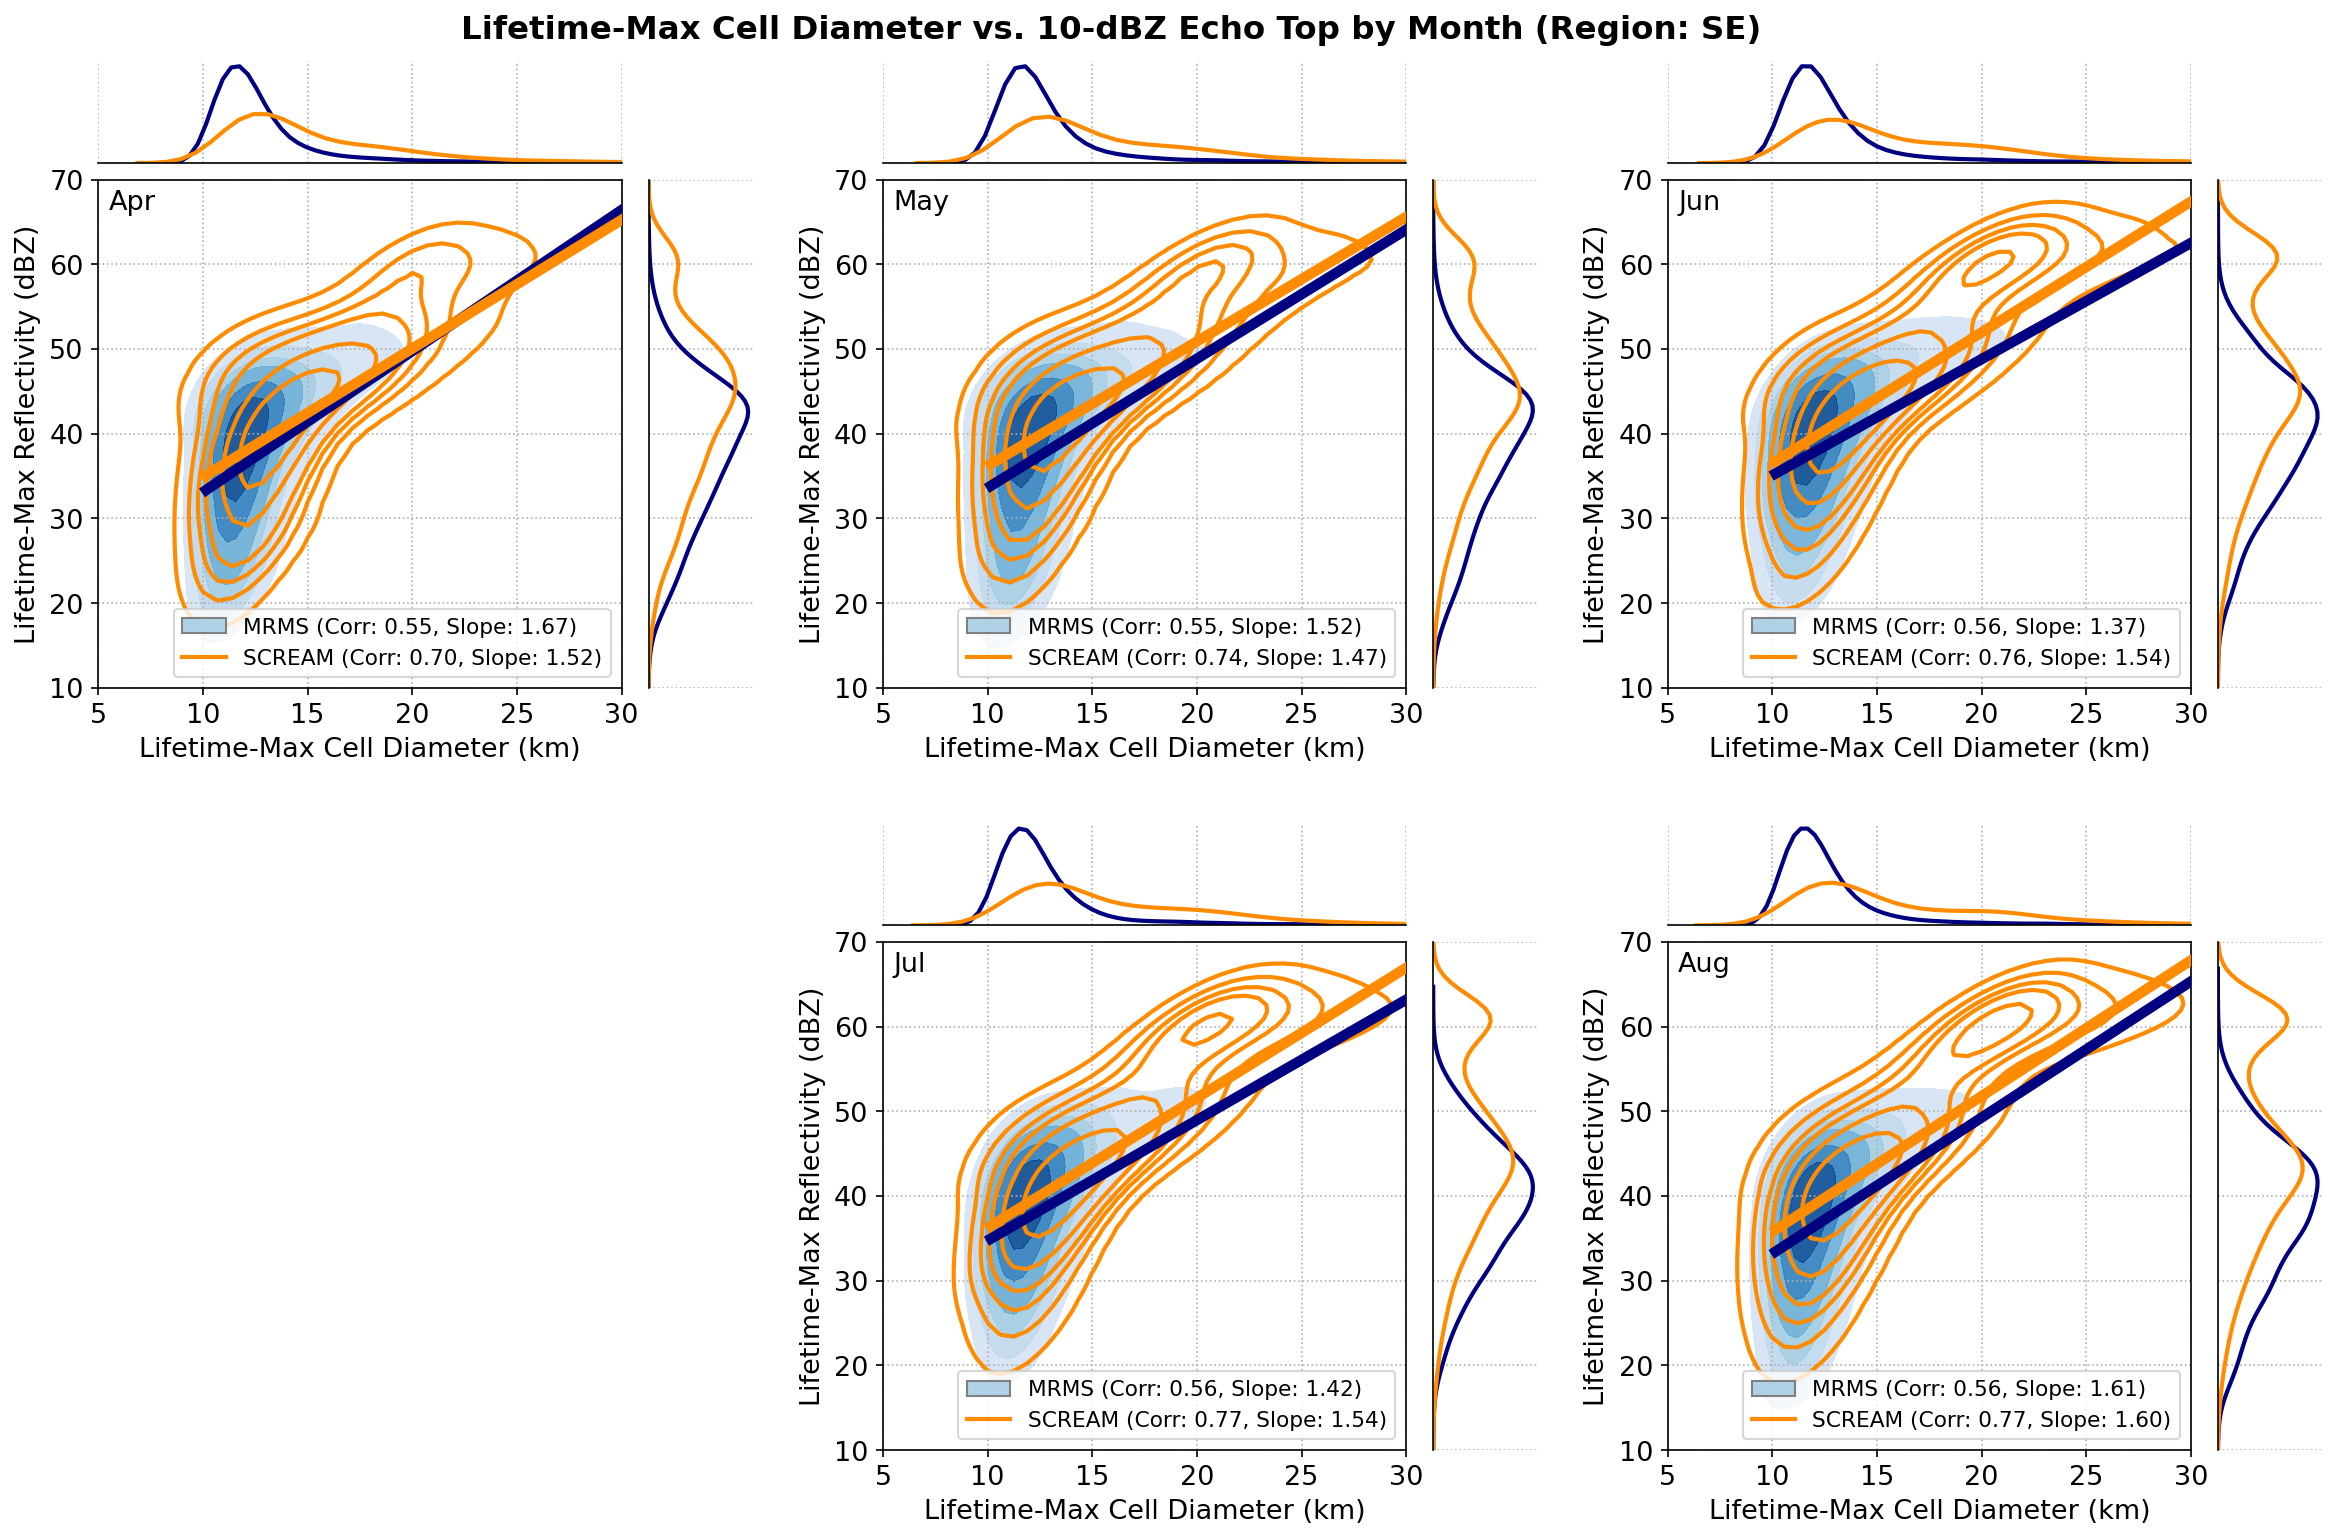

In [34]:
# Layout:  Row 0 → Apr, May, Jun  (cols 0-2)
#          Row 1 → [empty], Jul, Aug  (cols 0-2)

nrow, ncol = 2, 3
max_points = 10000
month_names = {4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug'}

xvar = 'cell_diameter_ltmax'   # lifetime-max cell diameter
yvar = 'max_dbz_ltmax'    # lifetime-max 10-dBZ echo-top

df_o_lt = df_lt[df_lt['dataset'] == name_map['o']]
df_m_lt = df_lt[df_lt['dataset'] == name_map['m']]

data          = [[None]*ncol for _ in range(nrow)]
titles        = [[None]*ncol for _ in range(nrow)]
xlims         = [[None]*ncol for _ in range(nrow)]
ylims         = [[None]*ncol for _ in range(nrow)]
xlabels       = [[None]*ncol for _ in range(nrow)]
ylabels       = [[None]*ncol for _ in range(nrow)]
legend_labels = [[None]*ncol for _ in range(nrow)]

month_grid = [[4, 5, 6], [None, 7, 8]]   # None → empty panel

for row in range(nrow):
    for col in range(ncol):
        month = month_grid[row][col]
        if month is None:
            continue   # leave data[row][col] = None (empty panel)

        sub_o = df_o_lt[df_o_lt['month'] == month].dropna(subset=[xvar, yvar])
        sub_m = df_m_lt[df_m_lt['month'] == month].dropna(subset=[xvar, yvar])
        print(f"  {month_names[month]}: {name_map['o']}={len(sub_o)}, {name_map['m']}={len(sub_m)} tracks")

        x_o, y_o = downsample_for_kde(sub_o[xvar].values, sub_o[yvar].values, max_points)
        x_m, y_m = downsample_for_kde(sub_m[xvar].values, sub_m[yvar].values, max_points)

        data[row][col]          = {'o': (x_o, y_o), 'm': (x_m, y_m)}
        titles[row][col]        = month_names[month]
        xlims[row][col]         = (5, 30)
        ylims[row][col]         = (10, 70)
        xlabels[row][col]       = 'Lifetime-Max Cell Diameter (km)'
        ylabels[row][col]       = 'Lifetime-Max Reflectivity (dBZ)'
        legend_labels[row][col] = [name_map['o'], name_map['m']]

# ── 4. Color / style settings ────────────────────────────────────────────────────
levels = [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]
cmap   = truncate_colormap(plt.get_cmap('Blues'), 0.15, 1.0)
lcolors = {
    'o':  'navy',
    'm': 'darkorange',
}

# ── 5. Plot ──────────────────────────────────────────────────────────────────────
figname = f'{figdir}JointKDE_CellDiameter_vs_MaxReflectivity_byMonth_{name_map["m"]}_vs_{name_map["o"]}_{region}.pdf'

fig = jointKDE_MxN(
    nrow=nrow, ncol=ncol,
    data=data,
    margin_space=0.01,
    levels=levels,
    gridsize=100,
    bw_adjust=1.5,
    cmap=cmap,
    lcolors=lcolors,
    suptitle=f'Lifetime-Max Cell Diameter vs. 10-dBZ Echo Top by Month (Region: {region})',
    fontsize=13,
    titles=titles,
    xlims=xlims,
    ylims=ylims,
    xlabels=xlabels,
    ylabels=ylabels,
    legend_loc='lower right',
    legend_labels=legend_labels,
    wspace=0.5, hspace=0.5,
    dpi=150,
    figsize=(18, 11),
    figname=figname,
)
print(f"Saved: {figname}")

In [35]:
# ── Pinpoint where start_basetime caps out ──────────────────────────────────────

print("=== dsnms_m (xarray) ===")
print(f"  start_basetime max: {pd.to_datetime(dsnms_m.start_basetime.values).max()}")
print(f"  n_tracks: {dsnms_m.sizes['tracks']}")

print("\n=== df_m (post ds_to_dataframe) ===")
print(f"  start_basetime dtype: {df_m['start_basetime'].dtype}")
print(f"  start_basetime max:   {df_m['start_basetime'].max()}")
print(f"  unique tracks: {df_m['tracks'].nunique()}")
print(f"  start_basetime NaN count: {df_m['start_basetime'].isna().sum()}")

print("\n=== df_all (post concat) ===")
for ds_name, grp in df_all.groupby('dataset'):
    uniq = grp.drop_duplicates('tracks')
    print(f"  {ds_name}: start_basetime max={uniq['start_basetime'].max()}  NaN={uniq['start_basetime'].isna().sum()}")

print("\n=== vars_1d check in dsnms_m ===")
ds_loaded = dsnms_m.load()
vars_1d = [v for v in ds_loaded.data_vars if tuple(ds_loaded[v].dims) == ('tracks',)]
print(f"  1D vars: {vars_1d}")
print(f"  'start_basetime' in vars_1d: {'start_basetime' in vars_1d}")
if 'start_basetime' in ds_loaded.data_vars:
    print(f"  start_basetime dims: {ds_loaded['start_basetime'].dims}")
    print(f"  start_basetime dtype: {ds_loaded['start_basetime'].dtype}")
    print(f"  start_basetime max: {ds_loaded['start_basetime'].max().values}")


=== dsnms_m (xarray) ===
  start_basetime max: 2020-08-31 23:45:00
  n_tracks: 113706

=== df_m (post ds_to_dataframe) ===
  start_basetime dtype: datetime64[ns]
  start_basetime max:   2020-08-31 23:45:00
  unique tracks: 113706
  start_basetime NaN count: 0

=== df_all (post concat) ===
  MRMS: start_basetime max=2025-08-31 23:34:41  NaN=0
  SCREAM: start_basetime max=2020-08-31 23:45:00  NaN=0

=== vars_1d check in dsnms_m ===
  1D vars: ['track_duration', 'start_status', 'end_status', 'start_basetime', 'end_basetime', 'start_split_tracknumber', 'start_split_timeindex', 'start_split_cloudnumber', 'end_merge_tracknumber', 'end_merge_timeindex', 'end_merge_cloudnumber', 'original_tracks']
  'start_basetime' in vars_1d: True
  start_basetime dims: ('tracks',)
  start_basetime dtype: datetime64[ns]
  start_basetime max: 2020-08-31T23:45:00.000000000


## Binned ETH vs. Cell Diameter: frequency contourf + median dots + linear fit

In [36]:
def plot_binned_eth_vs_diameter(
    df, xvar='cell_diameter_ltmax', yvar='maxETH_10dbz_ltmax',
    groupby_col='dataset', groups=None,
    obs_color='navy', mod_color='orangered', contour_color='darkorange',
    diam_bins=None, diam_range=(5, 40),
    eth_bins=None, eth_range=(0, 20),
    min_count=10,
    bw_method='scott',
    levels=None,
    cmap='Blues',
    lw_fit=2.0,
    xlabel='Lifetime-Max Cell Diameter (km)',
    ylabel='Lifetime-Max 10-dBZ ETH (km)',
    title='', fontsize=12,
    figsize=(7, 5), dpi=150,
    figname=None,
):
    """
    Plot both datasets on a single panel:
      - groups[0] (obs/MRMS): filled contourf (cmap) + obs_color median dots + obs_color solid fit line
      - groups[1] (model/SCREAM): line contours (contour_color, same levels) + mod_color median dots
        + mod_color solid fit line
      - Legend shows one entry per dataset with a coloured dot + fit slope and r.

    For each diameter bin the ETH values are fitted with a gaussian_kde,
    evaluated on eth_centers, and normalised so the discrete sum equals 1.

    Parameters
    ----------
    df : pd.DataFrame
        One row per track; must contain xvar, yvar, and groupby_col.
    xvar, yvar : str
        Column names for cell diameter and ETH respectively.
    groupby_col : str
        Column to split groups by (default 'dataset').
    groups : list or None
        [obs_label, model_label].  None → sorted unique values (first = obs).
    obs_color : str
        Color for obs (groups[0]) median dots and fit line (default 'navy').
    mod_color : str
        Color for model (groups[1]) median dots and fit line (default 'orangered').
    contour_color : str
        Color for the model line contours (default 'darkorange').
    diam_bins : array-like or None
        Explicit bin edges for xvar.  None → np.arange(*diam_range, 1.5).
    diam_range : tuple
        (min, max) used to build default diam_bins and set xlim.
    eth_bins : array-like or None
        Explicit bin edges for yvar.  None → np.arange(*eth_range, 1).
    eth_range : tuple
        (min, max) used to build default eth_bins and set ylim.
    min_count : int
        Diameter bins with fewer tracks are skipped entirely.
    bw_method : str or float
        Bandwidth selector for scipy.stats.gaussian_kde (default 'scott').
    levels : array-like or None
        Contourf/contour level edges.  None → 11 levels from 0 to 95 % of
        the obs frequency maximum.
    cmap : str or Colormap
        Colormap for the obs filled contourf (default 'Blues').
    lw_fit : float
        Linewidth for the fit line (default 2.0).
    xlabel, ylabel, title : str
    fontsize : float
    figsize : tuple
    dpi : int
    figname : str or None
        If given, save the figure to this path.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """

    if groups is None:
        groups = sorted(df[groupby_col].unique())

    assert len(groups) >= 2, "Need at least two groups (obs + model)."
    obs_label = groups[0]
    mod_label = groups[1]

    if diam_bins is None:
        diam_bins = np.arange(diam_range[0], diam_range[1] + 1, 1.5)
    if eth_bins is None:
        eth_bins = np.arange(eth_range[0], eth_range[1] + 1, 1)

    diam_centers = 0.5 * (diam_bins[:-1] + diam_bins[1:])
    eth_centers  = 0.5 * (eth_bins[:-1]  + eth_bins[1:])

    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)

    legend_handles = []

    for grp_idx, (grp_label, grp_color, grp_dot_color) in enumerate([
        (obs_label, obs_color, obs_color),
        (mod_label, contour_color, mod_color),
    ]):
        sub = df[df[groupby_col] == grp_label].dropna(subset=[xvar, yvar])

        # ── Assign each track to a diameter bin (0-based) ──────────────────
        diam_idx_all = np.digitize(sub[xvar].values, diam_bins) - 1
        valid_global = (diam_idx_all >= 0) & (diam_idx_all < len(diam_centers))

        # ── KDE per diameter bin ────────────────────────────────────────────
        freq = np.full((len(diam_centers), len(eth_centers)), np.nan)
        bin_counts = np.zeros(len(diam_centers), dtype=int)

        for i in range(len(diam_centers)):
            mask_i = valid_global & (diam_idx_all == i)
            n_i = int(mask_i.sum())
            bin_counts[i] = n_i
            if n_i < min_count:
                continue
            eth_vals = sub[yvar].values[mask_i]
            try:
                kde = gaussian_kde(eth_vals, bw_method=bw_method)
                density = kde(eth_centers)
                density = np.clip(density, 0, None)
                s = density.sum()
                if s > 0:
                    freq[i, :] = density / s
            except Exception:
                pass

        XX, YY = np.meshgrid(diam_centers, eth_centers, indexing='ij')
        freq_plot = freq.copy()
        freq_plot[bin_counts < min_count, :] = np.nan

        # Compute levels from obs panel (grp_idx==0); reuse for model
        if grp_idx == 0:
            _levels = levels if levels is not None else np.linspace(
                0, np.nanmax(freq_plot) * 0.95, 11)
            # Filled contourf for obs
            cf = ax.contourf(XX, YY, freq_plot, levels=_levels, cmap=cmap, extend='max')
            fig.colorbar(cf, ax=ax, label='Frequency', shrink=0.85, pad=0.02)
        else:
            # Line contours only for model
            ax.contour(XX, YY, freq_plot, levels=_levels, colors=grp_color,
                       linewidths=1.2, alpha=0.85)

        # ── Median per diameter bin ─────────────────────────────────────────
        sub2 = sub[valid_global].copy()
        sub2['_diam_bin'] = diam_idx_all[valid_global]
        medians = (
            sub2.groupby('_diam_bin')[yvar]
            .agg(['median', 'count'])
            .rename(columns={'median': 'med', 'count': 'n'})
        )
        medians = medians[medians['n'] >= min_count]
        med_x = diam_centers[medians.index.values]
        med_y = medians['med'].values

        ax.scatter(med_x, med_y, color=grp_dot_color,
                   s=25, zorder=5, edgecolors='k', linewidths=0.3)

        # ── Linear regression (solid line) ──────────────────────────────────
        fit_slope = fit_r = np.nan
        if len(med_x) >= 2:
            fit = linregress(med_x, med_y)
            fit_slope, fit_r = fit.slope, fit.rvalue
            xfit = np.linspace(med_x.min(), med_x.max(), 100)
            yfit = fit.slope * xfit + fit.intercept
            ax.plot(xfit, yfit, color=grp_dot_color, lw=lw_fit, ls='-', zorder=6)

        # Legend handle: dot + line, showing fit stats
        handle = mlines.Line2D(
            [], [], color=grp_dot_color, marker='o', markersize=5,
            markeredgecolor='k', markeredgewidth=0.3,
            linestyle='-', linewidth=1.8,
            label=f'{grp_label} (slope={fit_slope:.2f}, r={fit_r:.2f})',
        )
        legend_handles.append(handle)

    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_xlim(diam_range)
    ax.set_ylim(eth_range)
    ax.tick_params(labelsize=fontsize - 1)
    ax.grid(ls=':', alpha=0.5)
    ax.legend(handles=legend_handles, fontsize=fontsize - 1, loc='best',
              title='', title_fontsize=fontsize - 2)
    if title:
        ax.set_title(title, fontsize=fontsize + 1)

    plt.tight_layout()
    if figname is not None:
        plt.savefig(figname, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved: {figname}")
    plt.show()
    return fig, ax


June tracks — MRMS: 38530, SCREAM: 23519
Figure saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/BinnedETH10dBZ_vs_CellDiameter_Jun_SCREAM_vs_MRMS_SE.png


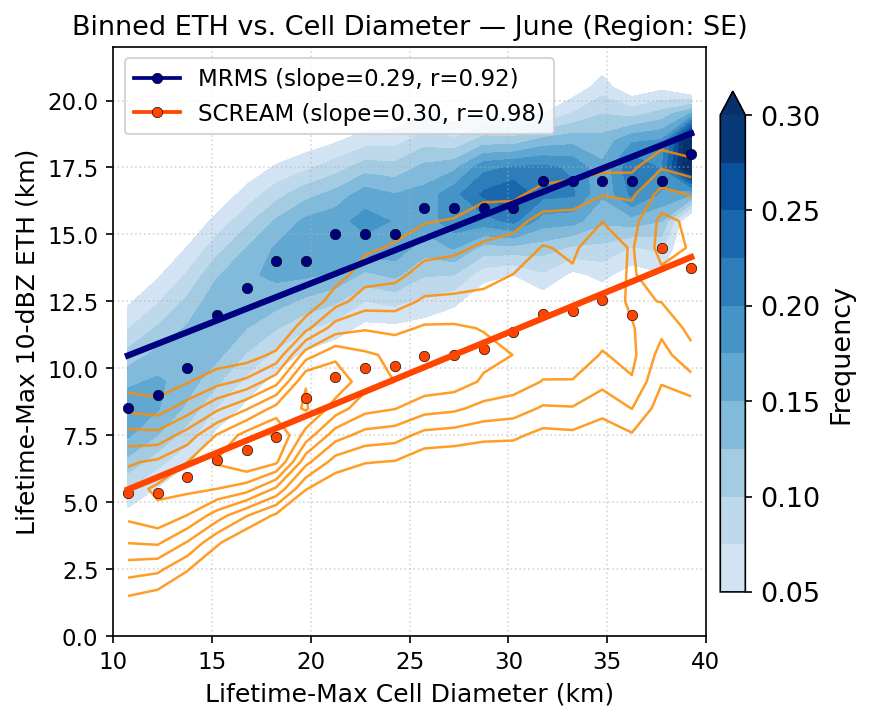

In [37]:
# ── Test: June data ──────────────────────────────────────────────────────────────
test_month = 6
df_june = df_lt[df_lt['month'] == test_month].copy()
print(f"June tracks — MRMS: {(df_june['dataset']==name_map['o']).sum()}, "
      f"SCREAM: {(df_june['dataset']==name_map['m']).sum()}")

levels = np.arange(0.05, 0.31, 0.025)
cmap = truncate_colormap(plt.get_cmap('Blues'), 0.15, 1)

figname_june = f'{figdir}BinnedETH10dBZ_vs_CellDiameter_Jun_{name_map["m"]}_vs_{name_map["o"]}_{region}.png'

fig, ax = plot_binned_eth_vs_diameter(
    df_june,
    xvar='cell_diameter_ltmax',
    yvar='maxETH_10dbz_ltmax',
    groups=[name_map['o'], name_map['m']],   # obs first, model second
    obs_color='navy',
    mod_color='orangered',
    contour_color='darkorange',
    diam_range=(10, 40), eth_range=(0, 22),
    min_count=10, bw_method=0.7,
    levels=levels, cmap=cmap,
    lw_fit=3.0,
    xlabel='Lifetime-Max Cell Diameter (km)',
    ylabel='Lifetime-Max 10-dBZ ETH (km)',
    title=f'Binned ETH vs. Cell Diameter — June (Region: {region})',
    fontsize=12,
    figsize=(6, 5), dpi=150,
    figname=figname_june,
)


### Function to plot MxN panel KDE in Y binned by X

In [38]:
def _compute_freq_kde(sub, xvar, yvar, diam_bins, diam_centers, eth_centers,
                      min_count, bw_method):
    """Compute KDE-smoothed conditional frequency P(ETH | diameter bin) for one group."""
    
    diam_idx_all = np.digitize(sub[xvar].values, diam_bins) - 1
    valid_global = (diam_idx_all >= 0) & (diam_idx_all < len(diam_centers))
    freq = np.full((len(diam_centers), len(eth_centers)), np.nan)
    bin_counts = np.zeros(len(diam_centers), dtype=int)
    for i in range(len(diam_centers)):
        mask_i = valid_global & (diam_idx_all == i)
        n_i = int(mask_i.sum())
        bin_counts[i] = n_i
        if n_i < min_count:
            continue
        eth_vals = sub[yvar].values[mask_i]
        try:
            kde = gaussian_kde(eth_vals, bw_method=bw_method)
            density = kde(eth_centers)
            density = np.clip(density, 0, None)
            s = density.sum()
            if s > 0:
                freq[i, :] = density / s
        except Exception:
            pass
    return freq, bin_counts, valid_global, diam_idx_all


def binnedETH_byMonth_MxN(
    df, xvar, yvar,
    groupby_col='dataset', obs_label=None, mod_label=None,
    month_col='month',
    month_grid=None,
    month_names=None,
    obs_color='navy', mod_color='orangered', contour_color='darkorange',
    diam_bins=None, diam_range=(5, 40),
    eth_bins=None,  eth_range=(0, 20),
    min_count=10, bw_method='scott',
    levels=None, cmap='Blues',
    margin_space=0.01,
    xlabel='Lifetime-Max Cell Diameter (km)',
    ylabel='Lifetime-Max 10-dBZ ETH (km)',
    suptitle=None, fontsize=12,
    figsize=(18, 11), dpi=150,
    wspace=0.5, hspace=0.5,
    figname=None,
):
    """
    Multi-panel plot of diameter-binned conditional ETH KDE by month.

    Each panel combines both datasets (matching plot_binned_eth_vs_diameter):
      - Filled contourf (cmap) for obs
      - Line contours (contour_color) for model
      - Median dots + solid fit line in obs_color / mod_color
      - Marginal KDE of xvar (diameter) on top, yvar (ETH) on right

    No colorbars are drawn.

    Parameters
    ----------
    df : pd.DataFrame
        One row per track; must contain xvar, yvar, groupby_col, month_col.
    xvar, yvar : str
        Column names for diameter (x) and ETH (y).
    groupby_col : str
        Column identifying dataset (default 'dataset').
    obs_label, mod_label : str or None
        Labels of the obs and model groups.  None → first/second sorted unique value.
    month_col : str
        Column holding integer month values (default 'month').
    month_grid : list[list[int|None]] or None
        List of rows, each a list of month integers or None for empty panels.
        Default: [[4,5,6],[None,7,8]].
    month_names : dict or None
        {int month: str label}.  Default: {4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug'}.
    obs_color : str
        Color for obs median dots, fit line, and marginal KDE (default 'navy').
    mod_color : str
        Color for model median dots, fit line, and marginal KDE (default 'orangered').
    contour_color : str
        Color for model line contours (default 'darkorange').
    diam_bins, diam_range, eth_bins, eth_range, min_count, bw_method :
        Passed through to the per-bin KDE computation.
    levels : array-like or None
        Shared contourf/contour levels.  None → auto from all-months obs data.
    cmap : str or Colormap
        Colormap for the obs filled contourf (default 'Blues').
    margin_space : float
        Gap (in figure-fraction units) between the main panel and its marginal axes.
    xlabel, ylabel : str
    suptitle : str or None
    fontsize : float
    figsize : tuple
    dpi : int
    wspace, hspace : float
        GridSpec spacing.
    figname : str or None
        If given, save figure to this path.

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    

    # ── defaults ──────────────────────────────────────────────────────────────
    if month_grid is None:
        month_grid = [[4, 5, 6], [None, 7, 8]]
    if month_names is None:
        month_names = {4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug'}

    groups = sorted(df[groupby_col].unique())
    if obs_label is None:
        obs_label = groups[0]
    if mod_label is None:
        mod_label = groups[1]

    if diam_bins is None:
        diam_bins = np.arange(diam_range[0], diam_range[1] + 1, 1.5)
    if eth_bins is None:
        eth_bins  = np.arange(eth_range[0],  eth_range[1]  + 1, 1)

    diam_centers = 0.5 * (diam_bins[:-1] + diam_bins[1:])
    eth_centers  = 0.5 * (eth_bins[:-1]  + eth_bins[1:])

    # ── pre-compute shared levels from all-months obs data ────────────────────
    if levels is None:
        sub_obs_all = df[df[groupby_col] == obs_label].dropna(subset=[xvar, yvar])
        freq_all, cnt_all, _, _ = _compute_freq_kde(
            sub_obs_all, xvar, yvar,
            diam_bins, diam_centers, eth_centers, min_count, bw_method,
        )
        freq_all[cnt_all < min_count, :] = np.nan
        _levels = np.linspace(0, np.nanmax(freq_all) * 0.95, 11)
    else:
        _levels = np.asarray(levels)

    # ── figure & GridSpec ─────────────────────────────────────────────────────
    nrow = len(month_grid)
    ncol = max(len(r) for r in month_grid)
    mpl.rcParams['font.size'] = fontsize

    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs  = gridspec.GridSpec(nrow, ncol, wspace=wspace, hspace=hspace, figure=fig)

    # ── single loop: draw all main panels, collect axes for marginal pass ─────
    # ax_panels maps (row_idx, col_idx) -> (ax_joint, sub_obs, sub_mod)
    ax_panels = {}

    for row_idx, row_months in enumerate(month_grid):
        for col_idx, month in enumerate(row_months):
            if month is None:
                continue

            mname = month_names.get(month, str(month))

            sub_obs = (df[(df[groupby_col] == obs_label) & (df[month_col] == month)]
                       .dropna(subset=[xvar, yvar]))
            sub_mod = (df[(df[groupby_col] == mod_label) & (df[month_col] == month)]
                       .dropna(subset=[xvar, yvar]))

            freq_o, cnt_o, vg_o, di_o = _compute_freq_kde(
                sub_obs, xvar, yvar, diam_bins, diam_centers, eth_centers, min_count, bw_method)
            freq_m, cnt_m, vg_m, di_m = _compute_freq_kde(
                sub_mod, xvar, yvar, diam_bins, diam_centers, eth_centers, min_count, bw_method)

            freq_plot_o = freq_o.copy(); freq_plot_o[cnt_o < min_count, :] = np.nan
            freq_plot_m = freq_m.copy(); freq_plot_m[cnt_m < min_count, :] = np.nan

            XX, YY = np.meshgrid(diam_centers, eth_centers, indexing='ij')

            ax = fig.add_subplot(gs[row_idx, col_idx])

            ax.contourf(XX, YY, freq_plot_o, levels=_levels, cmap=cmap, extend='max')
            ax.contour( XX, YY, freq_plot_m, levels=_levels, colors=contour_color,
                        linewidths=1.0, alpha=0.85)

            legend_handles = []
            for sub, diam_idx_all, valid_global, dot_color in [
                (sub_obs, di_o, vg_o, obs_color),
                (sub_mod, di_m, vg_m, mod_color),
            ]:
                label_key = obs_label if dot_color == obs_color else mod_label
                sub2 = sub[valid_global].copy()
                sub2['_db'] = diam_idx_all[valid_global]
                medians = (
                    sub2.groupby('_db')[yvar]
                    .agg(['median', 'count'])
                    .rename(columns={'median': 'med', 'count': 'n'})
                )
                medians = medians[medians['n'] >= min_count]
                med_x = diam_centers[medians.index.values]
                med_y = medians['med'].values

                ax.scatter(med_x, med_y, color=dot_color,
                           s=15, zorder=5, edgecolors='k', linewidths=0.2)

                fit_slope = fit_r = np.nan
                if len(med_x) >= 2:
                    fit = linregress(med_x, med_y)
                    fit_slope, fit_r = fit.slope, fit.rvalue
                    xfit = np.linspace(med_x.min(), med_x.max(), 100)
                    ax.plot(xfit, fit.slope * xfit + fit.intercept,
                            color=dot_color, lw=1.8, ls='-', zorder=6)

                legend_handles.append(mlines.Line2D(
                    [], [], color=dot_color, marker='o', markersize=4,
                    markeredgecolor='k', markeredgewidth=0.2,
                    linestyle='-', linewidth=1.5,
                    label=f'{label_key}  s={fit_slope:.2f}, r={fit_r:.2f}',
                ))

            ax.set_xlim(diam_range)
            ax.set_ylim(eth_range)
            ax.set_xlabel(xlabel, fontsize=fontsize)
            ax.set_ylabel(ylabel, fontsize=fontsize)
            ax.grid(ls=':', alpha=0.5)
            # Add title within the ax_joint at the upper left corner
            ax.text(
                0.02, 0.98,  # Position in axis coordinates
                mname,
                ha='left', va='top',
                transform=ax.transAxes,
                # fontsize=12,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )
            ax.legend(handles=legend_handles, fontsize=fontsize * 0.75,
                      loc='lower right', facecolor='w',
                      title='', title_fontsize=fontsize * 0.85)

            ax_panels[(row_idx, col_idx)] = (ax, sub_obs, sub_mod)

    # ── add marginals — positions are stable after layout is forced ───────────
    fig.canvas.draw()

    for (row_idx, col_idx), (ax, sub_obs, sub_mod) in ax_panels.items():
        pos = ax.get_position()

        ax_mx = fig.add_axes([pos.x0, pos.y1 + margin_space,
                              pos.width, 0.18 * pos.height])
        ax_my = fig.add_axes([pos.x1 + margin_space, pos.y0,
                              0.15 * pos.width, pos.height])

        for sub, mc in [(sub_obs, obs_color), (sub_mod, mod_color)]:
            sns.kdeplot(x=sub[xvar], ax=ax_mx, color=mc, lw=1.5, fill=False, bw_adjust=1.5)
            sns.kdeplot(y=sub[yvar], ax=ax_my, color=mc, lw=1.5, fill=False, bw_adjust=1.5)

        ax_mx.set_xlim(diam_range)
        ax_my.set_ylim(eth_range)
        ax_mx.grid(axis='x', ls=':')
        ax_my.grid(axis='y', ls=':')

        ax_mx.set(yticks=[], ylabel=None, xlabel=None)
        ax_mx.set_xticklabels([])
        ax_mx.tick_params(left=False, bottom=False)
        for sp in ['top', 'right', 'left']:
            ax_mx.spines[sp].set_visible(False)

        ax_my.set(xticks=[], xlabel=None, ylabel=None)
        ax_my.set_yticklabels([])
        ax_my.tick_params(left=False, bottom=False)
        for sp in ['top', 'right', 'bottom']:
            ax_my.spines[sp].set_visible(False)

    if suptitle:
        fig.suptitle(suptitle, weight='bold', fontsize=fontsize + 1)
    if figname:
        fig.savefig(figname, bbox_inches='tight', dpi=dpi, facecolor='w')
        print(f'Saved: {figname}')
    return fig


Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/BinnedETH10dBZ_vs_CellDiameter_byMonth_SCREAM_vs_MRMS_SE.pdf


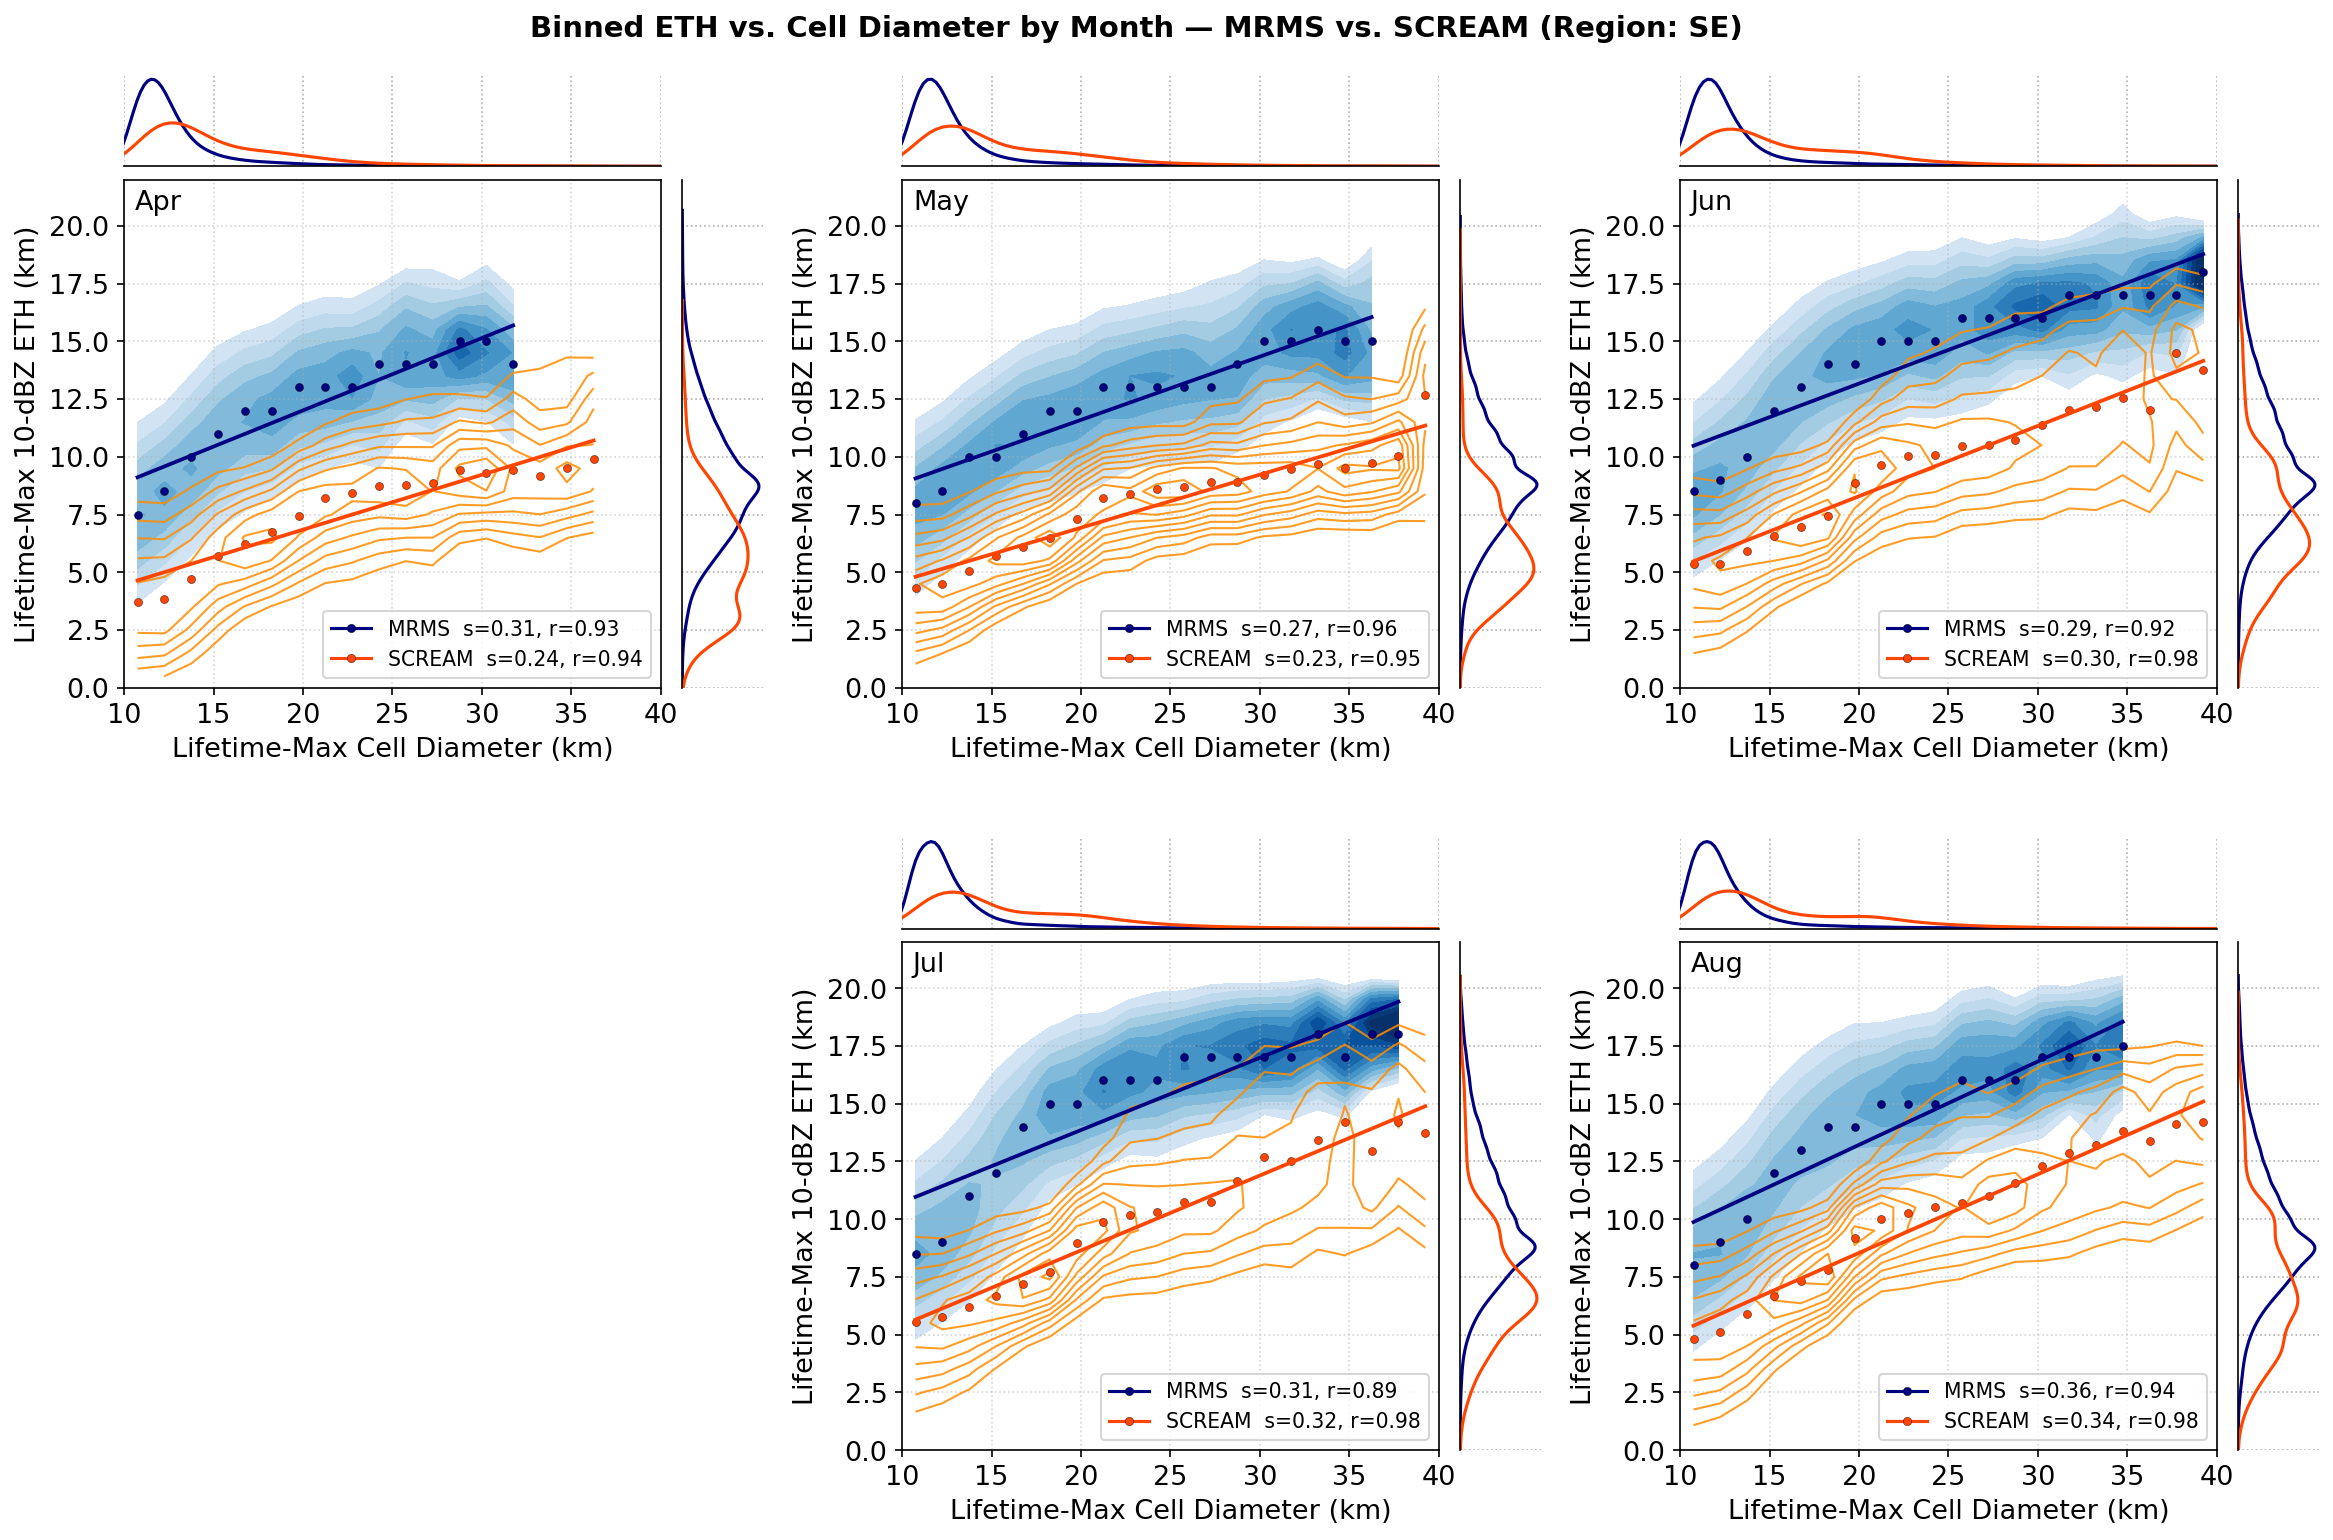

In [39]:
levels_mn = np.arange(0.05, 0.31, 0.025)
cmap_mn   = truncate_colormap(plt.get_cmap('Blues'), 0.15, 1)

figname_mn = f'{figdir}BinnedETH10dBZ_vs_CellDiameter_byMonth_{name_map["m"]}_vs_{name_map["o"]}_{region}.pdf'

fig = binnedETH_byMonth_MxN(
    df_lt,
    xvar='cell_diameter_ltmax',
    yvar='maxETH_10dbz_ltmax',
    obs_label=name_map['o'],
    mod_label=name_map['m'],
    month_col='month',
    month_grid=[[4, 5, 6], [None, 7, 8]],
    obs_color='navy',
    mod_color='orangered',
    contour_color='darkorange',
    diam_range=(10, 40), eth_range=(0, 22),
    min_count=10, bw_method=0.7,
    levels=levels_mn, cmap=cmap_mn,
    margin_space=0.008,
    xlabel='Lifetime-Max Cell Diameter (km)',
    ylabel='Lifetime-Max 10-dBZ ETH (km)',
    suptitle=f'Binned ETH vs. Cell Diameter by Month — {name_map["o"]} vs. {name_map["m"]} (Region: {region})',
    fontsize=13,
    figsize=(18, 11), dpi=150,
    wspace=0.45, hspace=0.5,
    figname=figname_mn,
)

Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/BinnedETH20dBZ_vs_CellDiameter_byMonth_SCREAM_vs_MRMS_SE.pdf


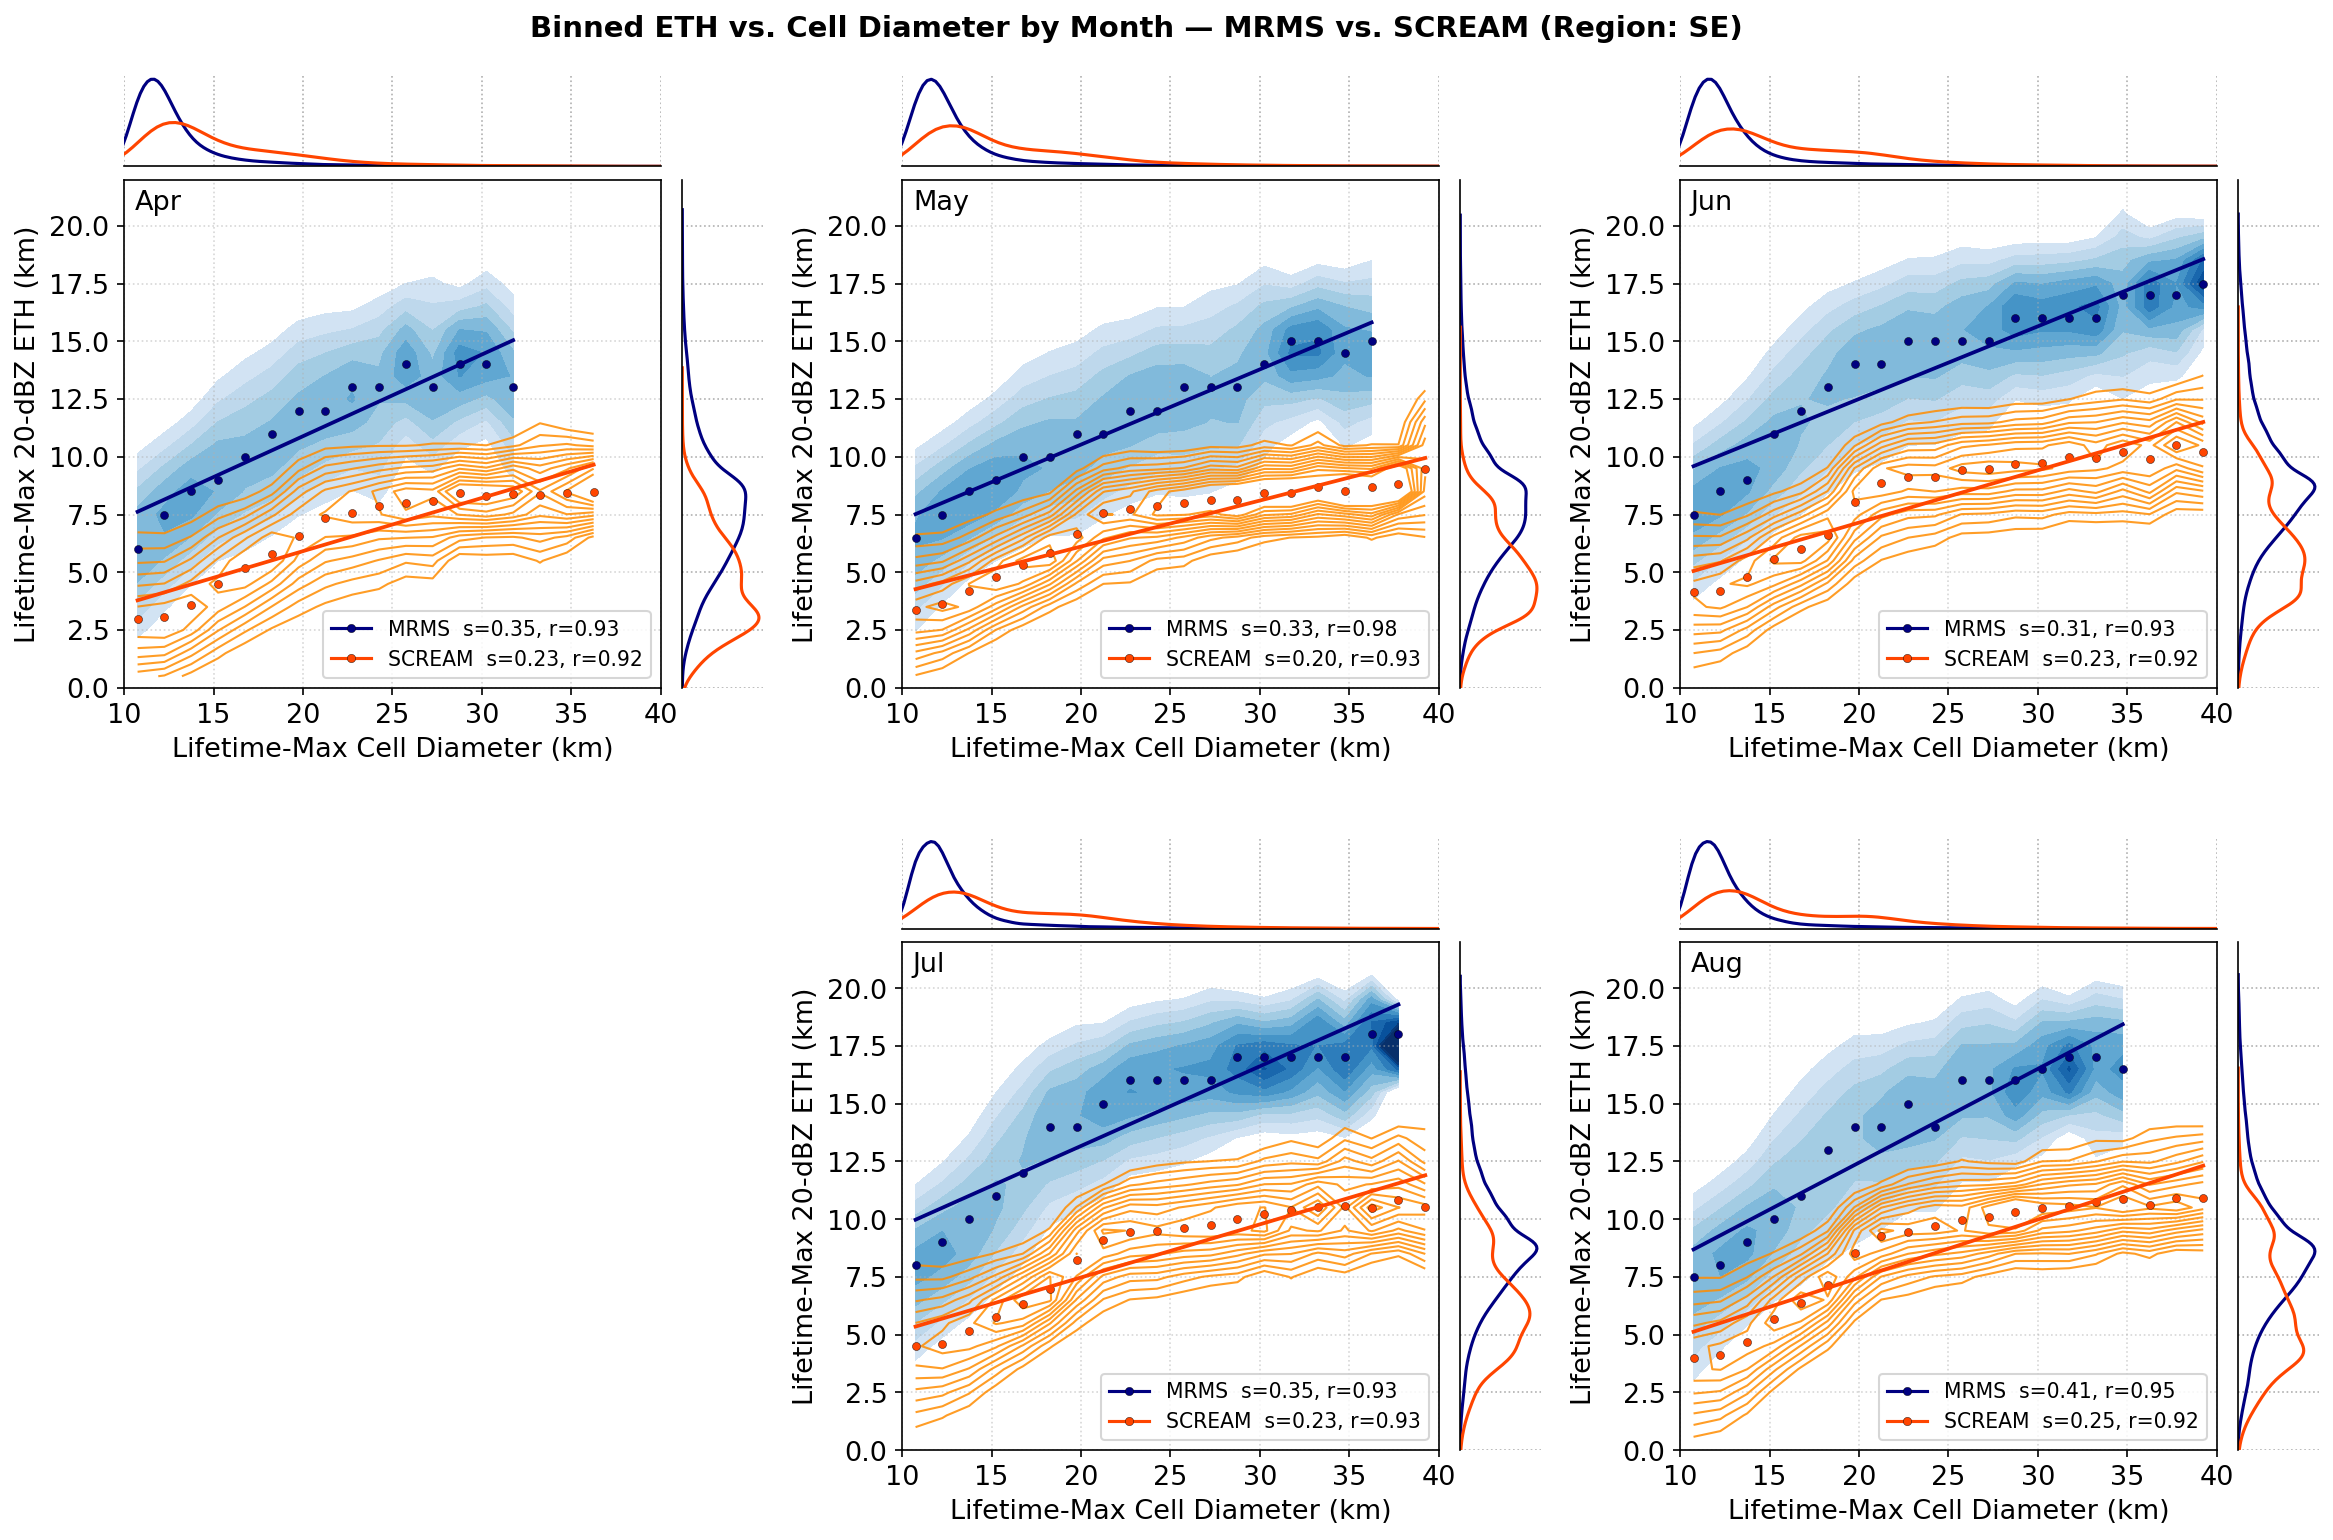

In [40]:
figname_mn = f'{figdir}BinnedETH20dBZ_vs_CellDiameter_byMonth_{name_map["m"]}_vs_{name_map["o"]}_{region}.pdf'

fig = binnedETH_byMonth_MxN(
    df_lt,
    xvar='cell_diameter_ltmax',
    yvar='maxETH_20dbz_ltmax',
    obs_label=name_map['o'],
    mod_label=name_map['m'],
    month_col='month',
    month_grid=[[4, 5, 6], [None, 7, 8]],
    obs_color='navy',
    mod_color='orangered',
    contour_color='darkorange',
    diam_range=(10, 40), eth_range=(0, 22),
    min_count=10, bw_method=0.7,
    levels=levels_mn, cmap=cmap_mn,
    margin_space=0.008,
    xlabel='Lifetime-Max Cell Diameter (km)',
    ylabel='Lifetime-Max 20-dBZ ETH (km)',
    suptitle=f'Binned ETH vs. Cell Diameter by Month — {name_map["o"]} vs. {name_map["m"]} (Region: {region})',
    fontsize=13,
    figsize=(18, 11), dpi=150,
    wspace=0.45, hspace=0.5,
    figname=figname_mn,
)

Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/BinnedETH30dBZ_vs_CellDiameter_byMonth_SCREAM_vs_MRMS_SE.pdf


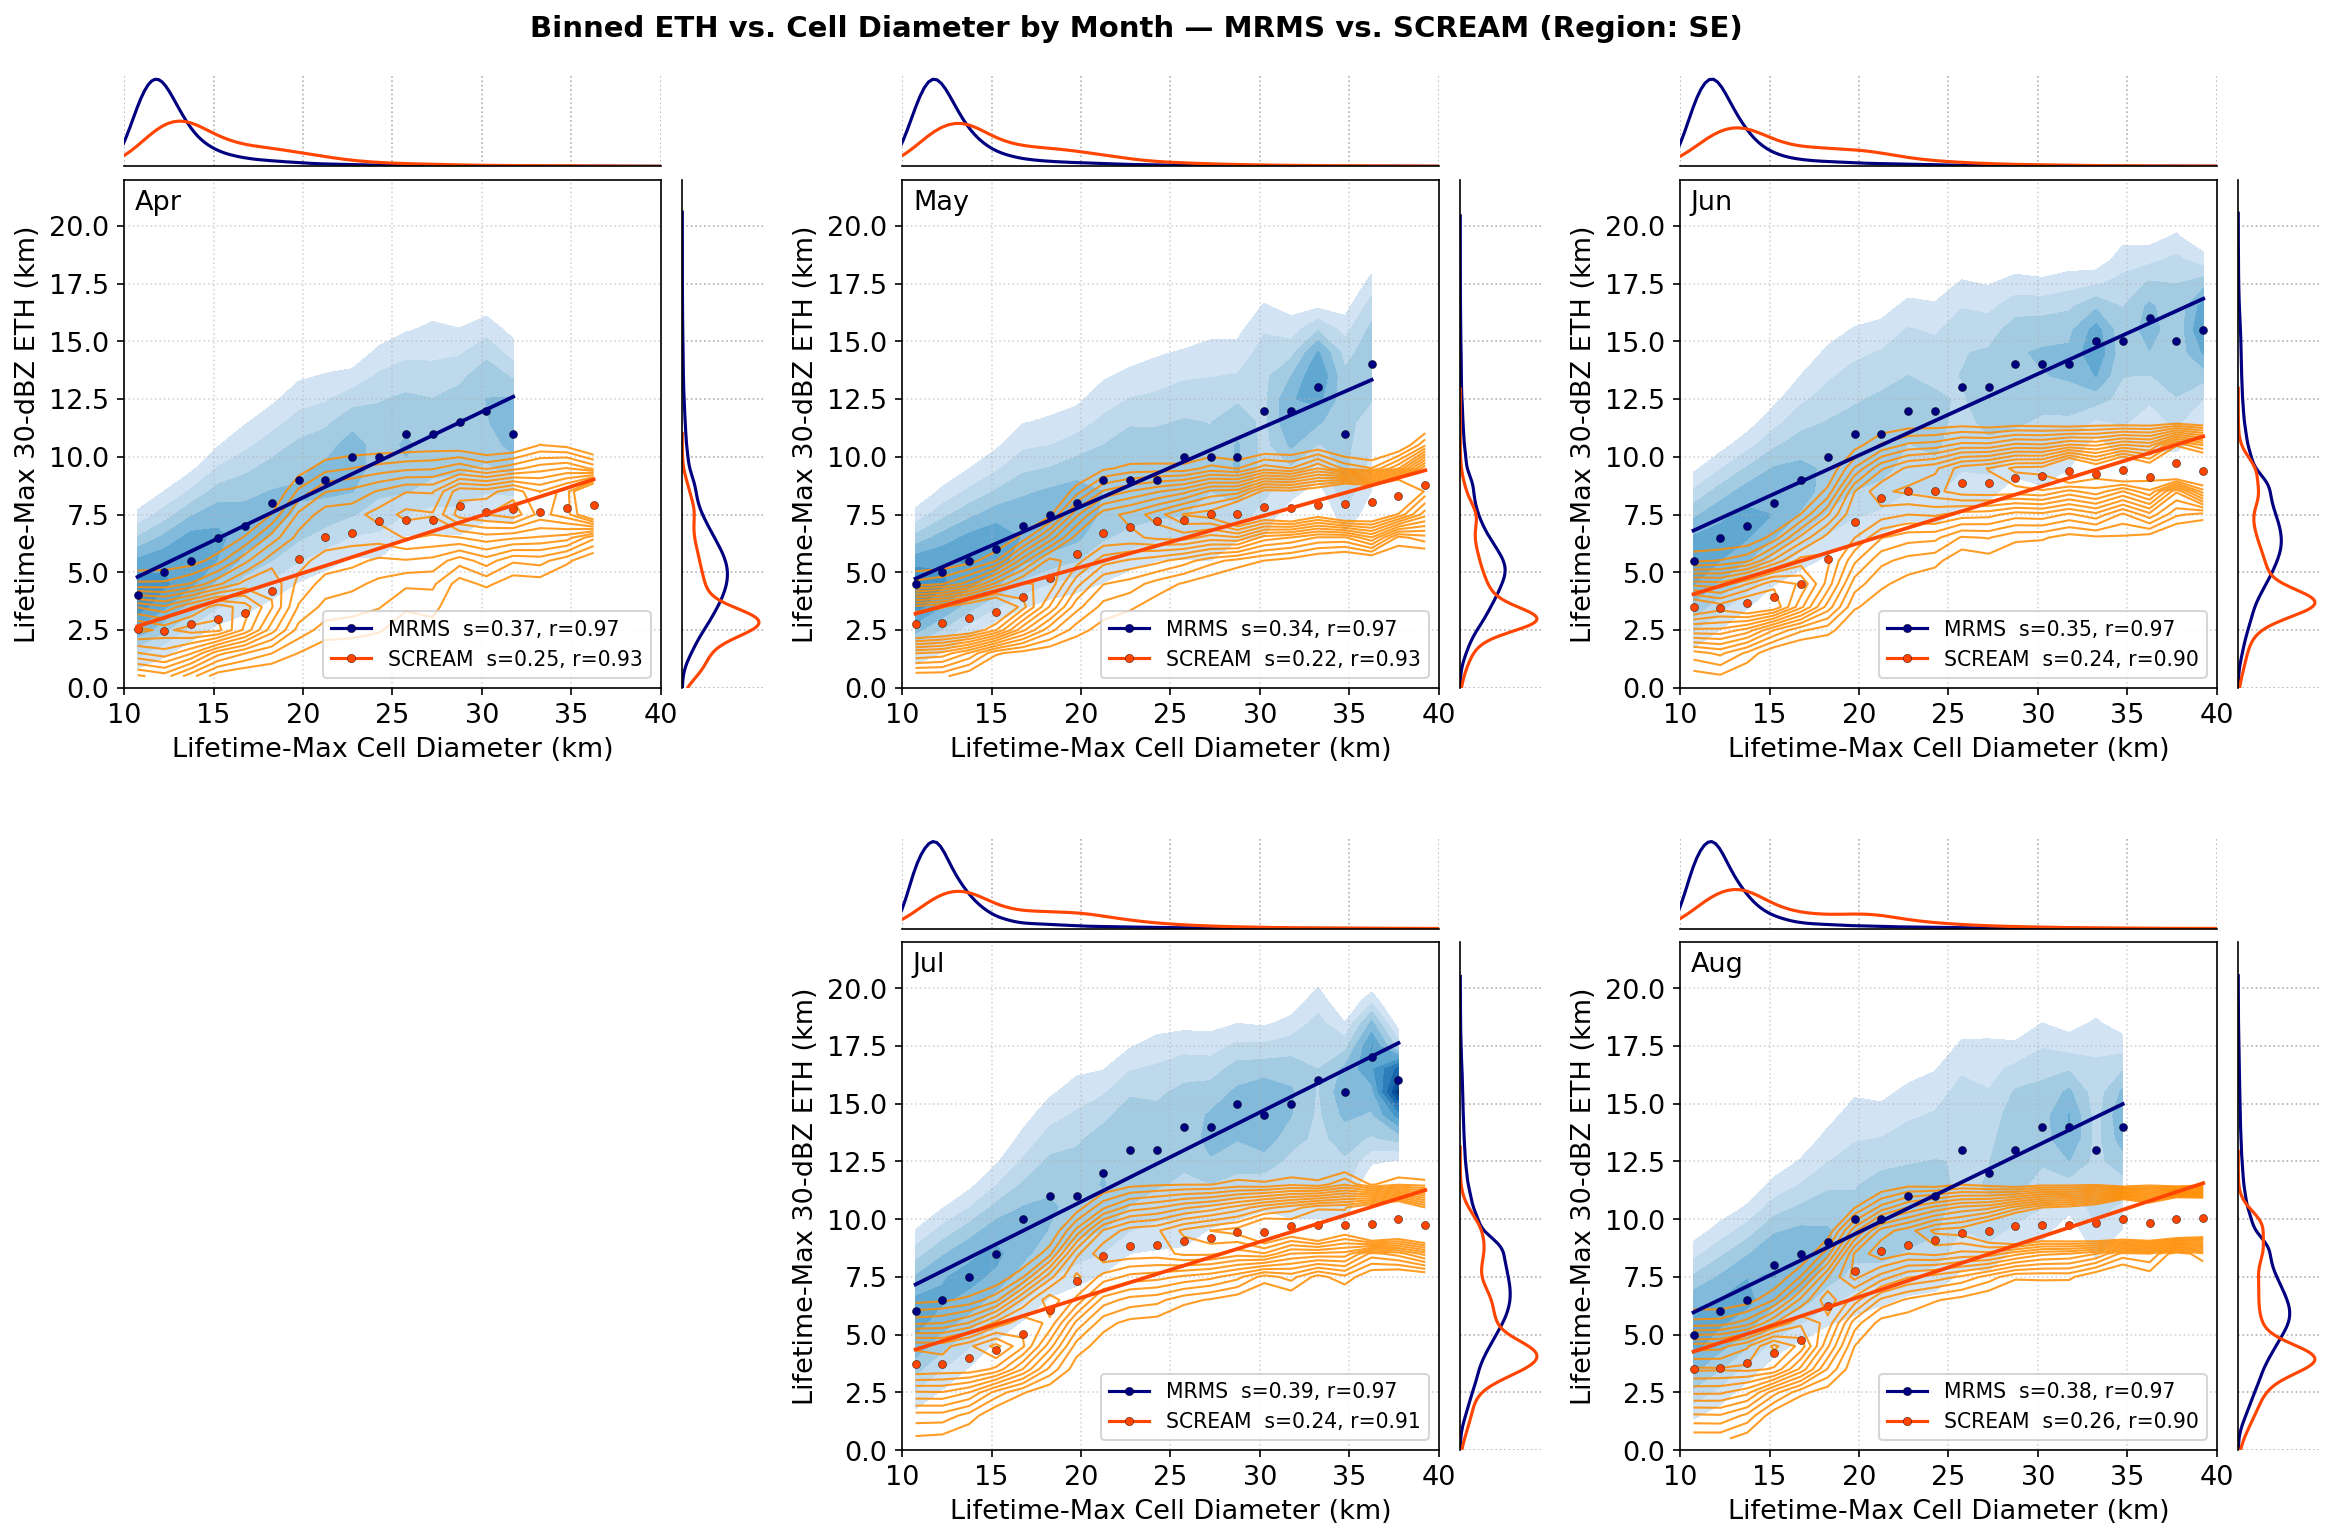

In [41]:
figname_mn = f'{figdir}BinnedETH30dBZ_vs_CellDiameter_byMonth_{name_map["m"]}_vs_{name_map["o"]}_{region}.pdf'

fig = binnedETH_byMonth_MxN(
    df_lt,
    xvar='cell_diameter_ltmax',
    yvar='maxETH_30dbz_ltmax',
    obs_label=name_map['o'],
    mod_label=name_map['m'],
    month_col='month',
    month_grid=[[4, 5, 6], [None, 7, 8]],
    obs_color='navy',
    mod_color='orangered',
    contour_color='darkorange',
    diam_range=(10, 40), eth_range=(0, 22),
    min_count=10, bw_method=0.7,
    levels=levels_mn, cmap=cmap_mn,
    margin_space=0.008,
    xlabel='Lifetime-Max Cell Diameter (km)',
    ylabel='Lifetime-Max 30-dBZ ETH (km)',
    suptitle=f'Binned ETH vs. Cell Diameter by Month — {name_map["o"]} vs. {name_map["m"]} (Region: {region})',
    fontsize=13,
    figsize=(18, 11), dpi=150,
    wspace=0.45, hspace=0.5,
    figname=figname_mn,
)

## Composite time-evolution of cell track properties

In [42]:
def composite_track_evolution(
    df, var,
    duration_range,
    dataset_col='dataset',
    time_col='relative_time_min',
    duration_col='track_duration_min',
    track_col='tracks',
):
    """
    Compute composite time-evolution statistics for tracks within a duration range.

    Parameters
    ----------
    df : pd.DataFrame
        Tidy DataFrame with one row per (track, time-step).
    var : str
        Column name of the variable to composite.
    duration_range : tuple (lo, hi)
        Half-open interval [lo, hi) of track duration in minutes.
    dataset_col, time_col, duration_col, track_col : str
        Column name overrides.

    Returns
    -------
    dict with keys:
        'time'          : 1-D array of relative time values (min)
        'median'        : median  of var at each time step
        'q25'           : 25th percentile
        'q75'           : 75th percentile
        'mean'          : mean of var at each time step
        'n'             : number of tracks contributing at each time step
        'n_tracks'      : total qualifying tracks in this bin
        'duration_range': the input duration_range tuple
    """
    lo, hi = duration_range

    # One unique duration value per track (broadcast constant, so any row works)
    track_dur = (
        df[[dataset_col, track_col, duration_col]]
        .drop_duplicates(subset=[dataset_col, track_col])
    )
    valid_tracks = track_dur.loc[
        (track_dur[duration_col] >= lo) & (track_dur[duration_col] < hi),
        [dataset_col, track_col]
    ]

    sub = df.merge(valid_tracks, on=[dataset_col, track_col], how='inner')
    if sub.empty:
        return None

    n_tracks = sub[[dataset_col, track_col]].drop_duplicates().shape[0]

    grp = sub.groupby(time_col)[var]
    result = pd.DataFrame({
        'time':   grp.median().index,
        'median': grp.median().values,
        'q25':    grp.quantile(0.25).values,
        'q75':    grp.quantile(0.75).values,
        'mean':   grp.mean().values,
        'n':      grp.count().values,
    })

    return {
        'time':           result['time'].values,
        'median':         result['median'].values,
        'q25':            result['q25'].values,
        'q75':            result['q75'].values,
        'mean':           result['mean'].values,
        'n':              result['n'].values,
        'n_tracks':       n_tracks,
        'duration_range': duration_range,
    }


In [43]:
df_all.keys()

Index(['tracks', 'relative_step', 'base_time', 'meanlat', 'meanlon', 'area',
       'cloudnumber', 'track_status', 'track_interruptions',
       'merge_tracknumbers', 'split_tracknumbers', 'core_meanlat',
       'core_meanlon', 'core_mean_y', 'core_mean_x', 'cell_meanlat',
       'cell_meanlon', 'cell_mean_y', 'cell_mean_x', 'core_area', 'cell_area',
       'max_dbz', 'maxETH_10dbz', 'maxETH_20dbz', 'maxETH_30dbz',
       'maxETH_40dbz', 'maxETH_50dbz', 'maxrange_flag', 'relative_time_min',
       'track_duration', 'start_status', 'end_status', 'start_basetime',
       'end_basetime', 'start_split_tracknumber', 'start_split_timeindex',
       'start_split_cloudnumber', 'end_merge_tracknumber',
       'end_merge_timeindex', 'end_merge_cloudnumber', 'original_tracks',
       'track_duration_min', 'dataset'],
      dtype='str')

In [ ]:
# ── Filter to non-merge / non-split tracks ───────────────────────────────────
# In PyFLEXTRKR encoding:
# #   start_status == 1: natural initiation (not from a split)
# #   end_status   == 0: natural dissipation (not merged into another track)
# df_nosplit = df_all[
#     (df_all['start_status'] == 1) &
#     (df_all['end_status']   == 0)
# ].copy()
# In PyFLEXTRKR encoding:
#   start_split_cloudnumber == FillValue: natural initiation (not from a split)
#   end_merge_cloudnumber   == FillValue: natural dissipation (not merged into another track)
df_nosplit = df_all[
    (np.isnan(df_all['start_split_cloudnumber'])) &
    (np.isnan(df_all['end_merge_cloudnumber']))
].copy()

# Derive cell diameter (km) from area at every time step
df_nosplit['cell_diameter'] = 2 * np.sqrt(df_nosplit['cell_area'] / np.pi)

print("All tracks:")
print(df_all[['dataset', 'tracks']].drop_duplicates().groupby('dataset').size())
print("\nNon-merge/non-split tracks:")
print(df_nosplit[['dataset', 'tracks']].drop_duplicates().groupby('dataset').size())

# ── Variable specs ────────────────────────────────────────────────────────────
# Add new variables here; that is the only change required to composite & plot them.
#   var      : column name in df_nosplit
#   ylabel   : y-axis label for plot
#   filetag  : filename fragment
comp_var_specs = {
    'cell_diameter': dict(ylabel='Mean Cell Diameter (km)',  filetag='CellDiameter'),
    'max_dbz':       dict(ylabel='Mean Max dBZ (dBZ)',       filetag='MaxDBZ'),
    'maxETH_10dbz':  dict(ylabel='Mean 10-dBZ ETH (km)',   filetag='ETH10dBZ'),
    'maxETH_30dbz':  dict(ylabel='Mean 30-dBZ ETH (km)',   filetag='ETH30dBZ'),
}

# ── Duration bins ─────────────────────────────────────────────────────────────
bin_step     = 30    # minutes
max_duration = 240   # minutes (4 hours)
dur_bins     = [(lo, lo + bin_step) for lo in range(0, max_duration, bin_step)]

# ── Compute composites for all variables ──────────────────────────────────────
# all_composites[var][ds_label][bin_label] = result dict
all_composites = {}
for var in comp_var_specs:
    all_composites[var] = {}
    for ds_label in [name_map['o'], name_map['m']]:
        all_composites[var][ds_label] = {}
        df_ds = df_nosplit[df_nosplit['dataset'] == ds_label]
        for lo, hi in dur_bins:
            bin_label = f'{lo}–{hi} min'
            result = composite_track_evolution(df_ds, var=var, duration_range=(lo, hi))
            if result is not None:
                all_composites[var][ds_label][bin_label] = result
    print(f'{var}: computed')


All tracks:
dataset
MRMS      168053
SCREAM    113706
dtype: int64

Non-merge/non-split tracks:
dataset
MRMS      164809
SCREAM    110400
dtype: int64
cell_diameter: computed
max_dbz: computed
maxETH_10dbz: computed
maxETH_30dbz: computed


### Function to plot composite evolution for each lifetime bin as line

In [45]:
def plot_composite_evolution(
    composites,
    ds_order,
    nrow=1,
    ncol=None,
    figsize=(7, 5),
    dpi=150,
    hspace=None,
    wspace=None,
    sharey=True,
    cmap_name='plasma_r',
    fontsize=12,
    xlabel='Relative Time (min)',
    ylabel=None,
    titles=None,
    suptitle=None,
    suptitle_y=1.12,
    legend_ncols=2,
    legend_title='Track duration',
    figname=None,
):
    """
    Plot composite time-evolution lines for an M×N panel grid.

    Parameters
    ----------
    composites : dict
        Nested dict: composites[ds_label][bin_label] = result dict from
        composite_track_evolution(). Each result dict must contain:
        'time', 'mean', 'duration_range', 'n_tracks'.
    ds_order : list of str
        Dataset labels in row-major (left→right, top→bottom) order.
        Length must equal nrow * ncol.
    nrow, ncol : int
        Grid dimensions. ncol defaults to len(ds_order) // nrow.
    figsize : tuple
    dpi : int
    hspace, wspace : float or None
        GridSpec row/column spacing. None → tight_layout handles spacing.
    sharey : bool
        Share the y-axis within each row.
    cmap_name : str
        Matplotlib colormap name for duration-bin lines.
    fontsize : int
    xlabel : str or list of str
        X-axis label(s). A single str is broadcast to all panels; a list must
        have length nrow*ncol.
    ylabel : str or list of str or None
        Y-axis label(s). A single str is applied to the leftmost panel of each
        row; a list of length nrow is applied one per row's left panel.
    titles : list of str or None
        Panel titles. For nrow>1, only the top row is titled (row 0).
        Defaults to ds_label for each top-row panel.
    suptitle : str or None
        Figure-level super-title.
    suptitle_y : float
        Vertical position of suptitle in figure-fraction coordinates.
    legend_ncols : int
    legend_title : str
    figname : str or None
        If given, save the figure to this path (bbox_inches='tight').

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes_grid : list[list[Axes]]  — shape (nrow, ncol)
    """
    if ncol is None:
        ncol = len(ds_order) // nrow

    n_panels = nrow * ncol
    if len(ds_order) != n_panels:
        raise ValueError(
            f'len(ds_order)={len(ds_order)} must equal nrow*ncol={n_panels}'
        )

    # ── colormap ─────────────────────────────────────────────────────────────
    bin_labels = list(next(iter(composites.values())).keys())
    n_bins     = len(bin_labels)
    cmap_obj   = plt.get_cmap(cmap_name, n_bins)
    colors     = [cmap_obj(i) for i in range(n_bins)]

    # ── normalise per-panel label arguments ──────────────────────────────────
    xlabels_list = [xlabel] * n_panels if isinstance(xlabel, str) else list(xlabel)

    if ylabel is None:
        ylabels_list = [None] * nrow
    elif isinstance(ylabel, str):
        ylabels_list = [ylabel] * nrow
    else:
        ylabels_list = list(ylabel)   # one entry per row

    titles_list = list(titles) if titles is not None else list(ds_order)

    # ── figure & GridSpec ────────────────────────────────────────────────────
    gs_kw = {}
    if hspace is not None:
        gs_kw['hspace'] = hspace
    if wspace is not None:
        gs_kw['wspace'] = wspace

    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs  = fig.add_gridspec(nrow, ncol, **gs_kw)

    # Build axes; share y within each row
    axes_grid = []
    for r in range(nrow):
        row_axes = []
        for c in range(ncol):
            share_with = row_axes[0] if (sharey and c > 0) else None
            ax = fig.add_subplot(gs[r, c], sharey=share_with)
            row_axes.append(ax)
        axes_grid.append(row_axes)

    # ── plot each panel ───────────────────────────────────────────────────────
    for idx, (ds_label, title) in enumerate(zip(ds_order, titles_list)):
        r, c = divmod(idx, ncol)
        ax   = axes_grid[r][c]

        for i, bin_label in enumerate(bin_labels):
            result = composites[ds_label].get(bin_label)
            if result is None:
                continue
            lo, hi = result['duration_range']
            lbl    = f'{lo}–{hi} min  (n={result["n_tracks"]:,})'
            ax.plot(result['time'], result['mean'],
                    color=colors[i], lw=1.8, label=lbl)

        # Title: only top row for multi-row grids (always for single row)
        if nrow == 1 or r == 0:
            ax.set_title(title, fontsize=fontsize, weight='bold', pad=6)
        ax.grid(ls=':', alpha=0.5)
        ax.tick_params(labelsize=fontsize - 1)

        # Y-label on leftmost column of each row only
        if c == 0 and ylabels_list[r]:
            ax.set_ylabel(ylabels_list[r], fontsize=fontsize)

        # Suppress shared tick labels on non-leftmost columns
        if sharey and c > 0:
            ax.tick_params(labelleft=False)

        # X-label: always for single-row; only bottom row for multi-row
        if nrow == 1 or r == nrow - 1:
            ax.set_xlabel(xlabels_list[idx], fontsize=fontsize)
        else:
            ax.set_xlabel('')

        # Legend: always for single-row; only top row for multi-row
        if nrow == 1 or r == 0:
            ax.legend(ncols=legend_ncols, title=legend_title,
                      fontsize=fontsize - 2, title_fontsize=fontsize - 1,
                      loc='lower center', bbox_to_anchor=(0.5, 1.08),
                      framealpha=0.85)

    # ── layout & suptitle ────────────────────────────────────────────────────
    if hspace is None and wspace is None:
        fig.tight_layout()

    if suptitle:
        fig.suptitle(suptitle, fontsize=fontsize + 1, weight='bold', y=suptitle_y)

    # ── time arrows (drawn after layout so axes positions are finalised) ──────
    # Use the actual xlabel bounding box to set y; axes fraction for x so the
    # arrow always spans the full axis width regardless of hspace/wspace/margins.
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    gap_display = fontsize * 0.3 * (fig.dpi / 72)   # small gap below xlabel
    for ax in axes_grid[-1]:
        xlabel_bbox = ax.xaxis.label.get_window_extent(renderer=renderer)
        ax_bbox     = ax.get_window_extent(renderer=renderer)
        # y in axes-fraction coords (can be negative → below the axis spine)
        arrow_y_axes = (xlabel_bbox.y0 - gap_display - ax_bbox.y0) / ax_bbox.height
        ax.annotate('', xy=(1.0, arrow_y_axes), xytext=(0.0, arrow_y_axes),
                    xycoords='axes fraction', annotation_clip=False,
                    arrowprops=dict(arrowstyle='->', facecolor='k', lw=3))

    # ── save ─────────────────────────────────────────────────────────────────
    if figname:
        fig.savefig(figname, bbox_inches='tight', dpi=dpi)
        print(f'Saved: {figname}')

    plt.show()
    return fig, axes_grid


Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/Composite_AllVars_byDuration_SCREAM_MRMS_SE.pdf


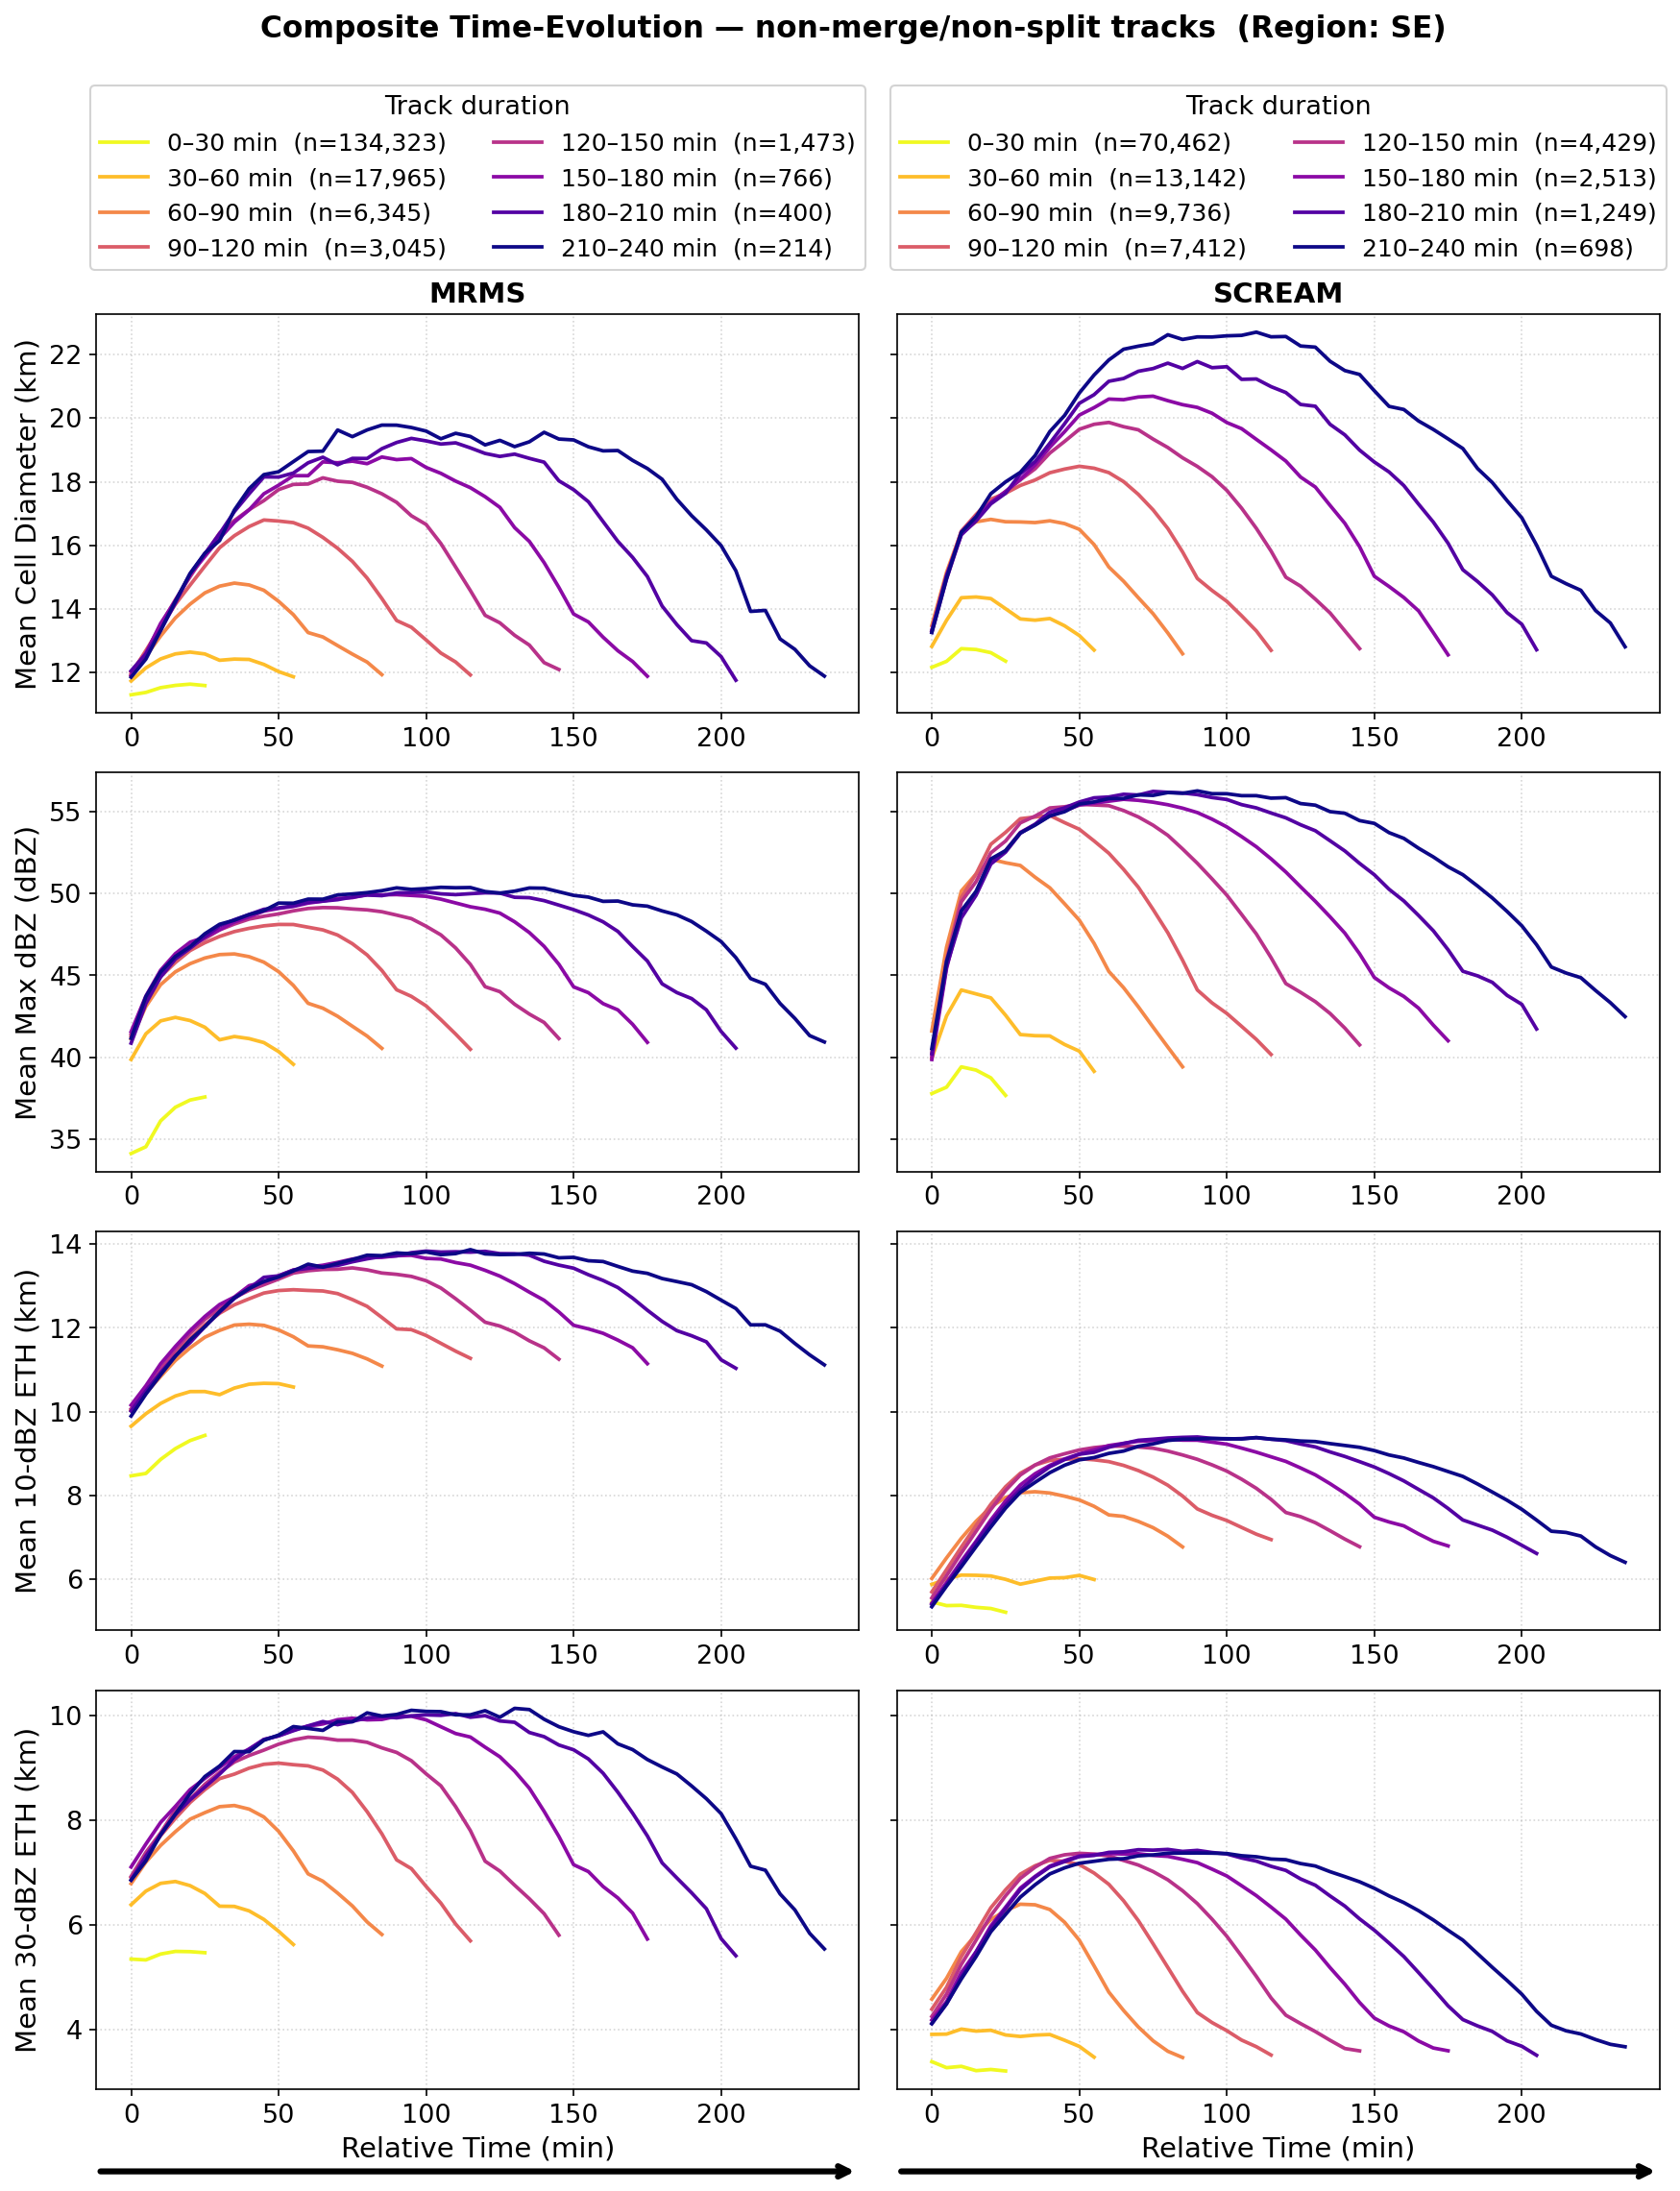

In [46]:
# ── Combined 4-variable × 2-dataset plot ─────────────────────────────────────
# Build a flat composites dict keyed by '{var}|{ds_label}' so the generic
# plot function can address each panel independently.
_ds_pair    = [name_map['o'], name_map['m']]
var_list    = list(comp_var_specs.keys())

combined_composites = {}   # combined_composites['{var}|{ds}'][bin_label]
panel_order = []           # row-major panel keys  (nrow*ncol)
panel_titles = []          # per-panel title
ylabels_per_row = []       # one ylabel per row (leftmost column)

for var, spec in comp_var_specs.items():
    ylabels_per_row.append(spec['ylabel'])
    for ds_label in _ds_pair:
        key = f'{var}|{ds_label}'
        combined_composites[key] = all_composites[var][ds_label]
        panel_order.append(key)
        panel_titles.append(ds_label)

figname_all = (
    f'{figdir}Composite_AllVars_byDuration_'
    f'{name_map["m"]}_{name_map["o"]}_{region}.pdf'
)
figsize = (14, 4 * len(var_list))

fig, axes = plot_composite_evolution(
    combined_composites,
    ds_order      = panel_order,
    nrow          = len(var_list),
    ncol          = 2,
    figsize       = figsize,
    hspace        = 0.15,
    wspace        = 0.05,
    dpi           = 150,
    cmap_name     = 'plasma_r',
    fontsize      = 14,
    xlabel        = 'Relative Time (min)',
    ylabel        = ylabels_per_row,
    titles        = panel_titles,
    suptitle      = (
        f'Composite Time-Evolution — non-merge/non-split tracks  (Region: {region})'
    ),
    suptitle_y    = 1.01,
    figname       = figname_all,
)


Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/Composite_CellDiameter_byDuration_SCREAM_MRMS_SE.pdf


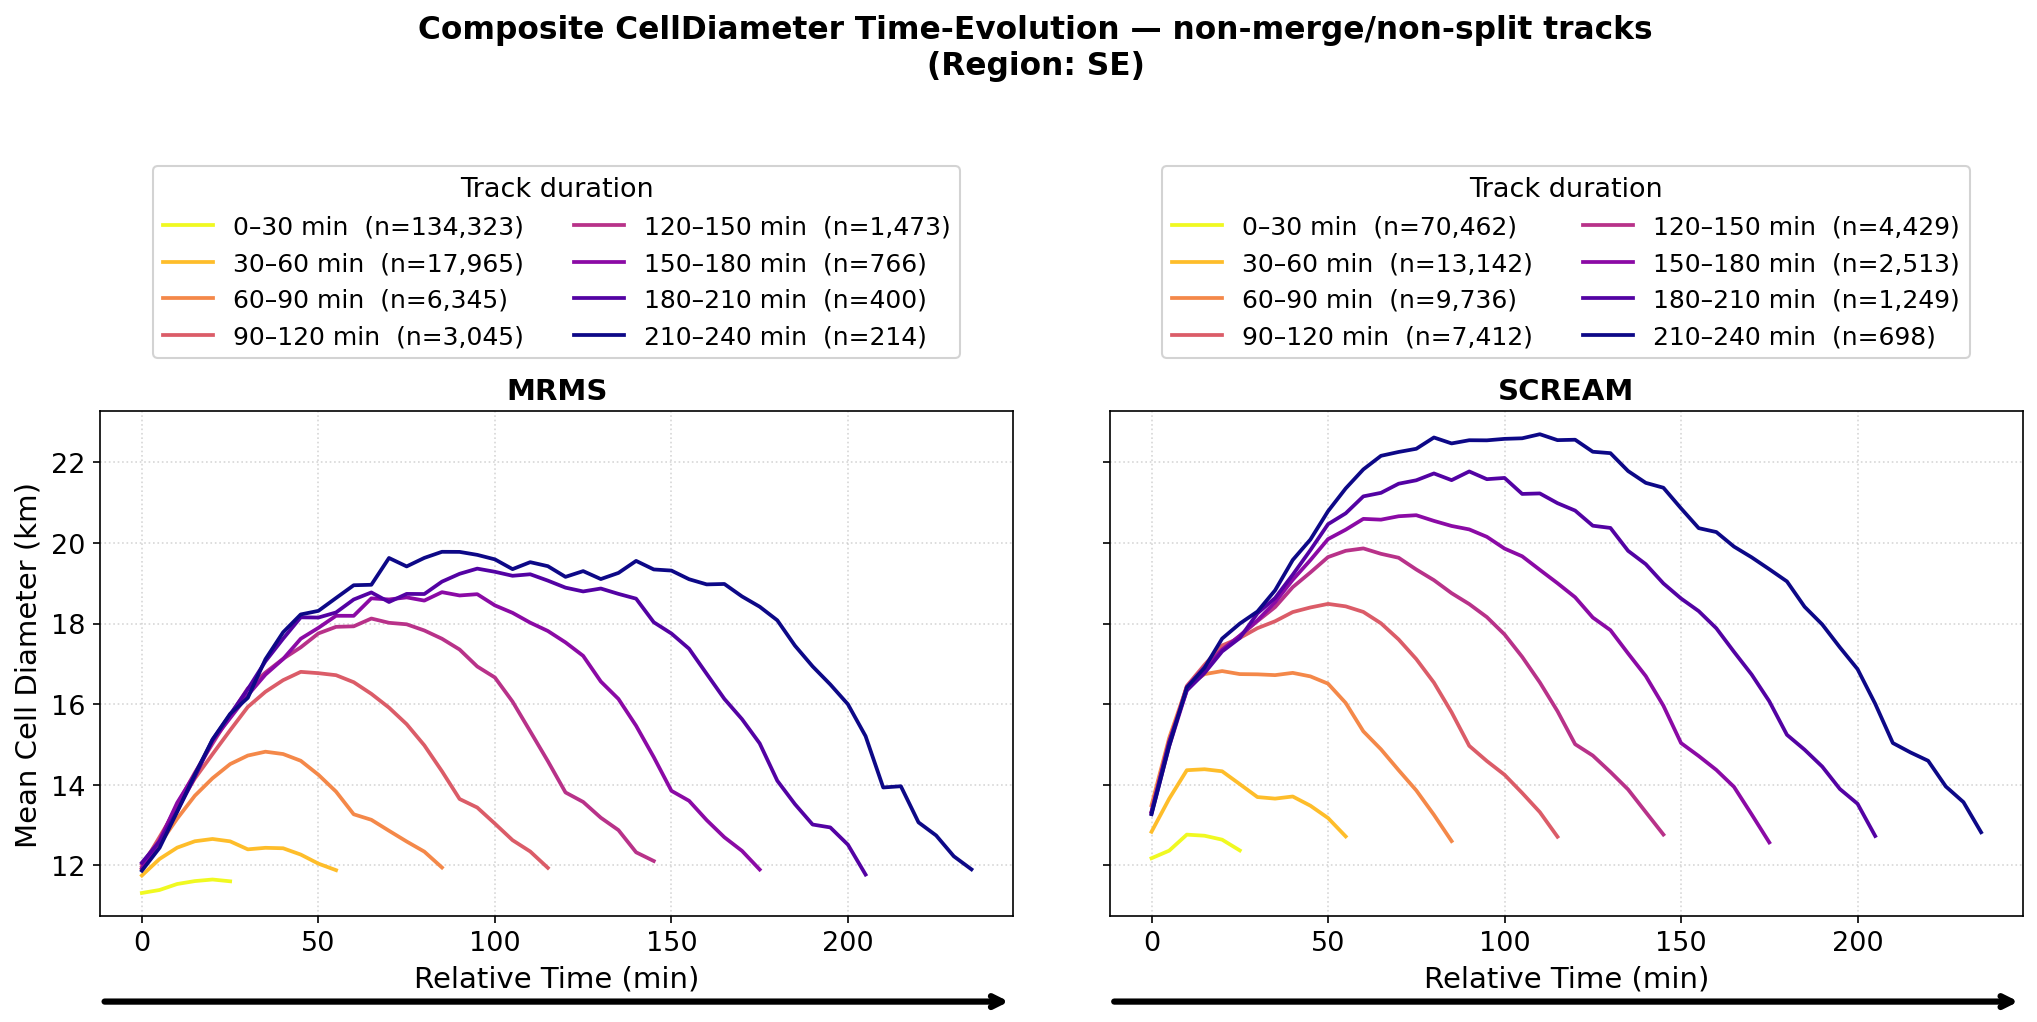

Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/Composite_MaxDBZ_byDuration_SCREAM_MRMS_SE.pdf


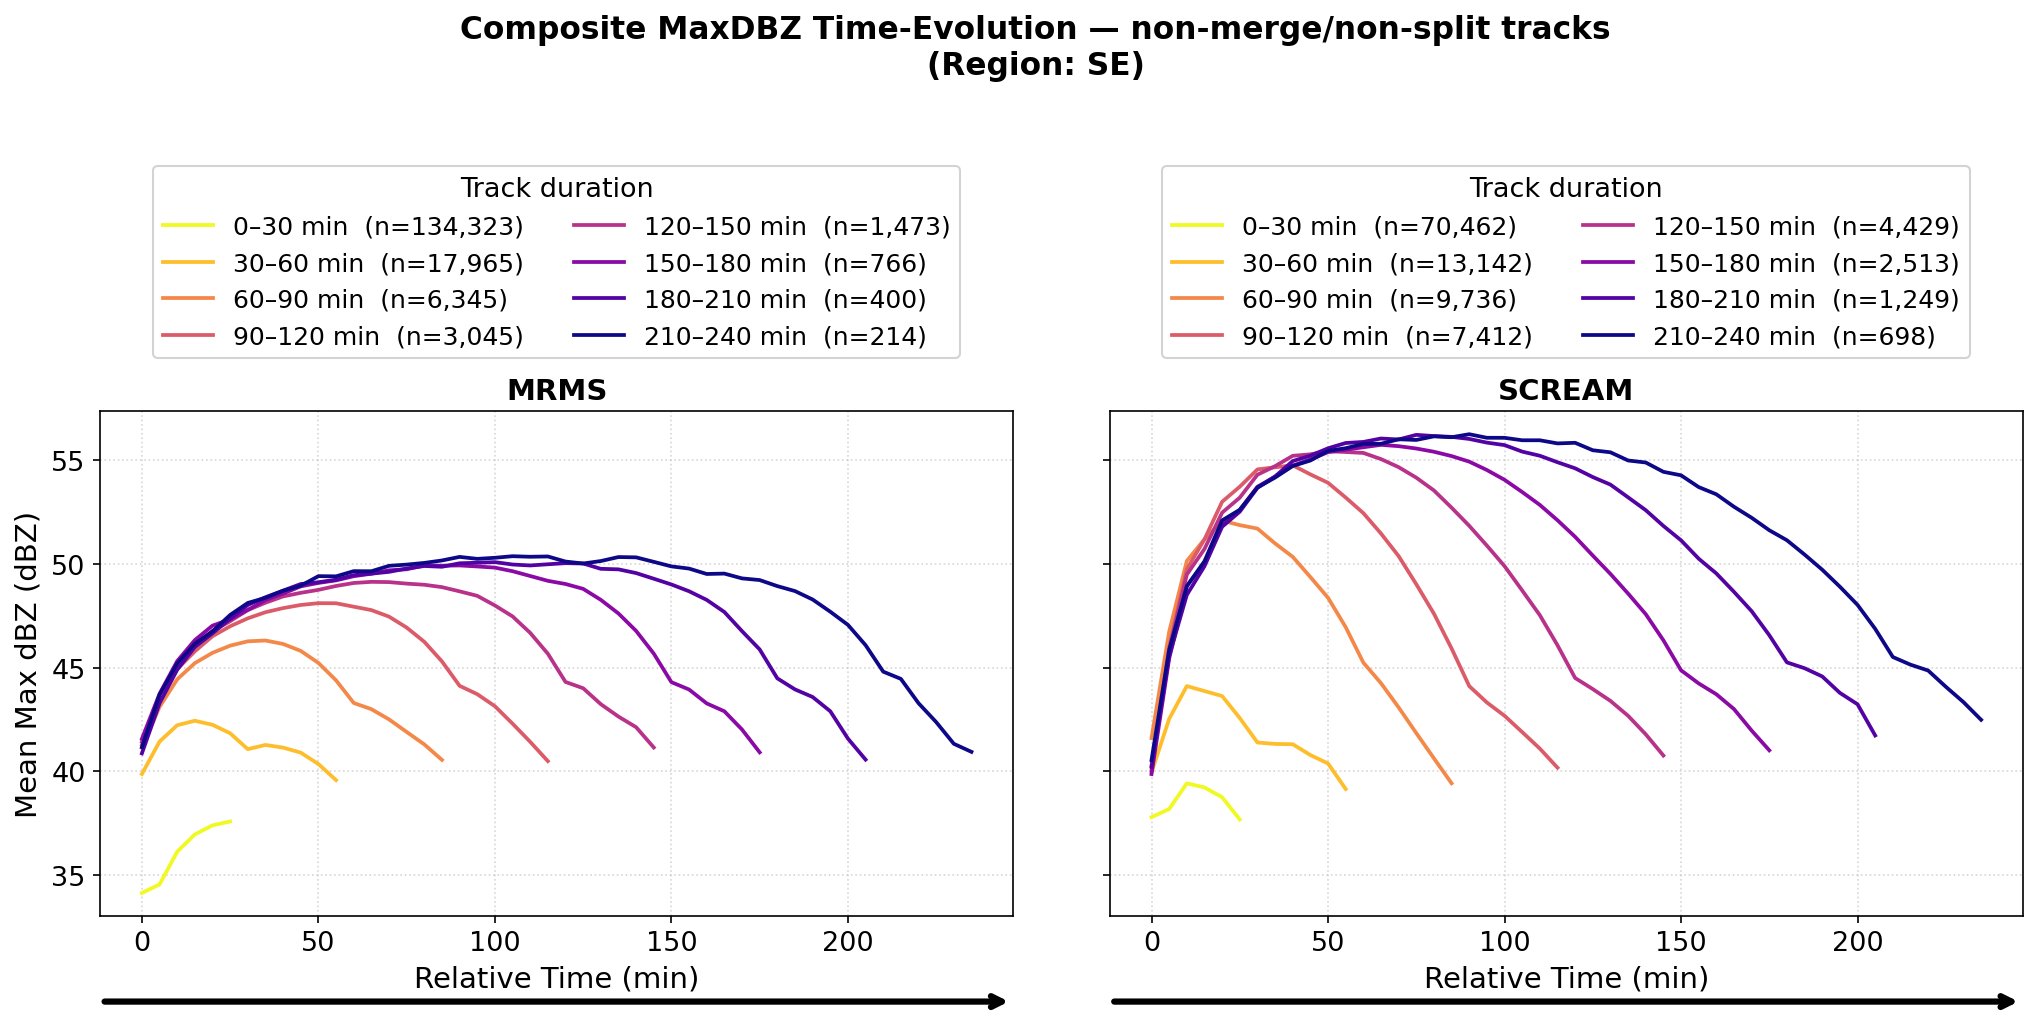

Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/Composite_ETH10dBZ_byDuration_SCREAM_MRMS_SE.pdf


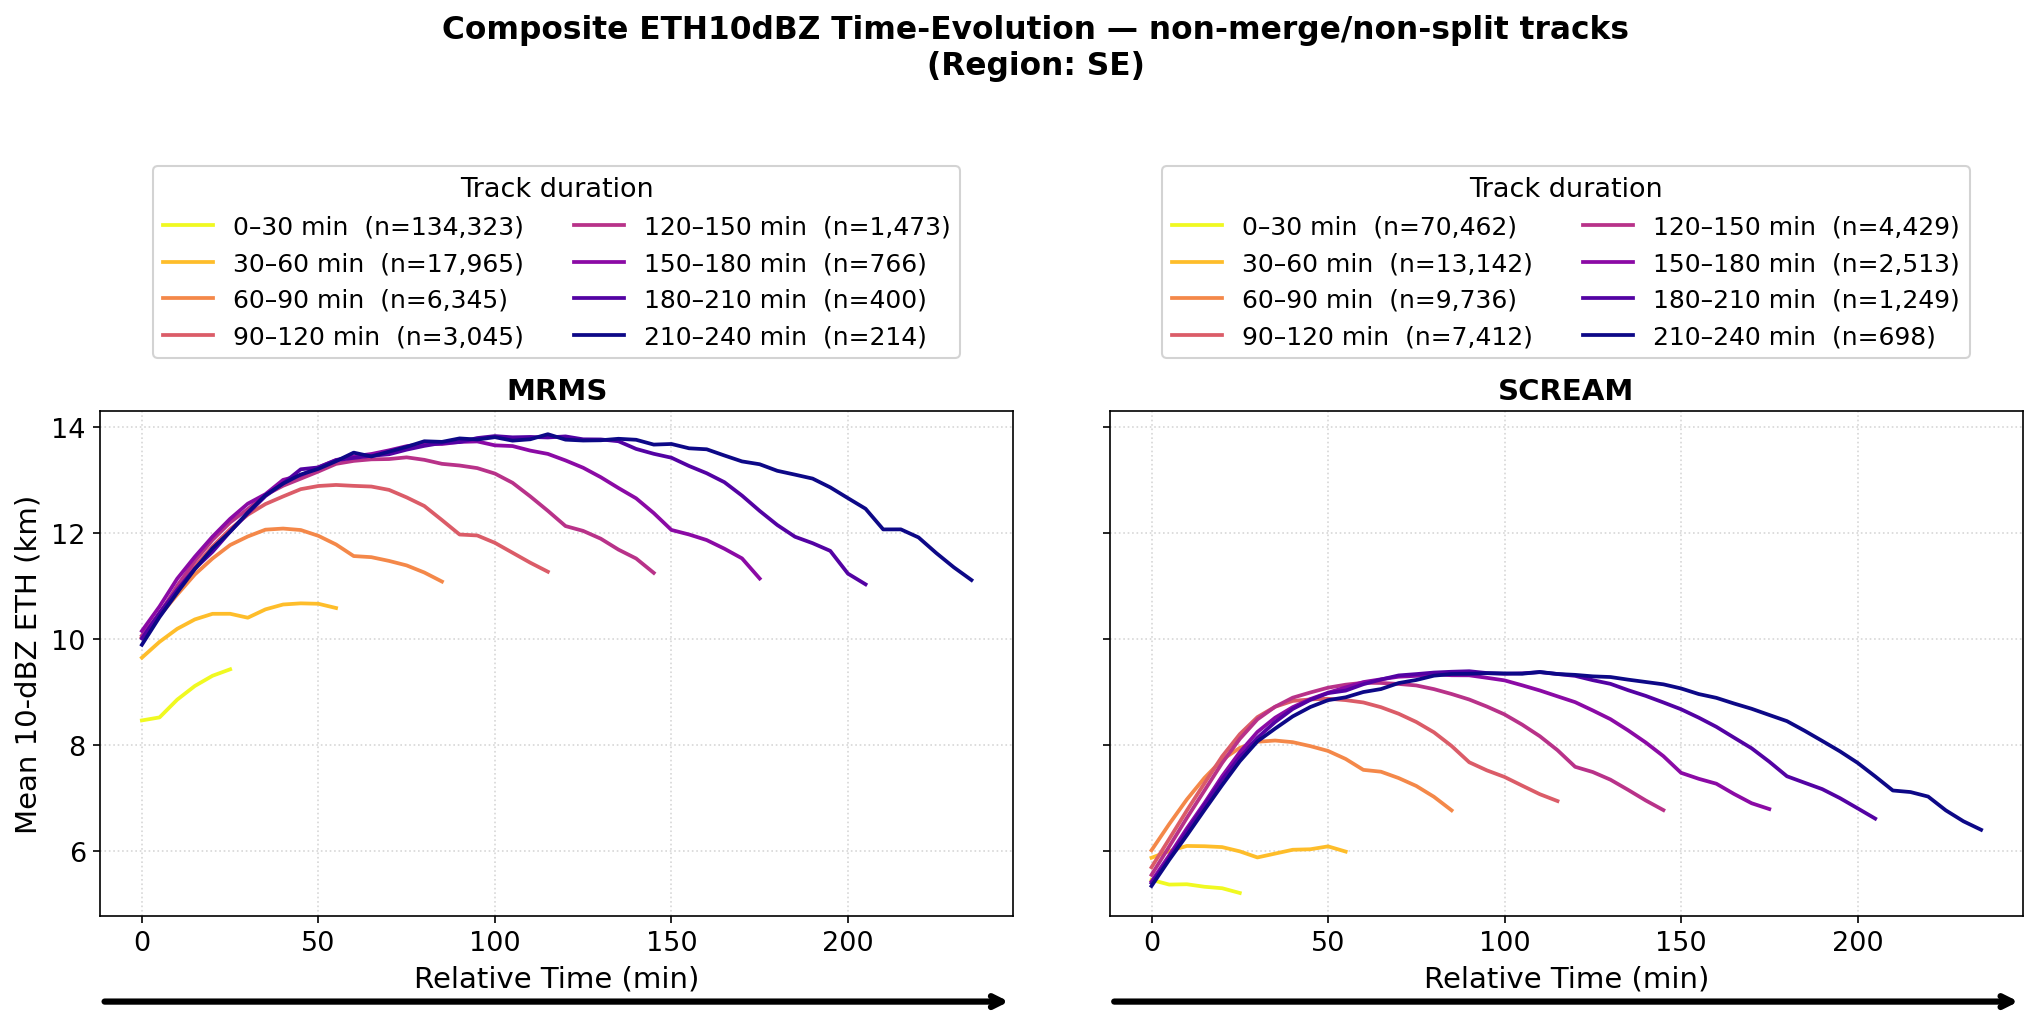

Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/CellTrackStats/Composite_ETH30dBZ_byDuration_SCREAM_MRMS_SE.pdf


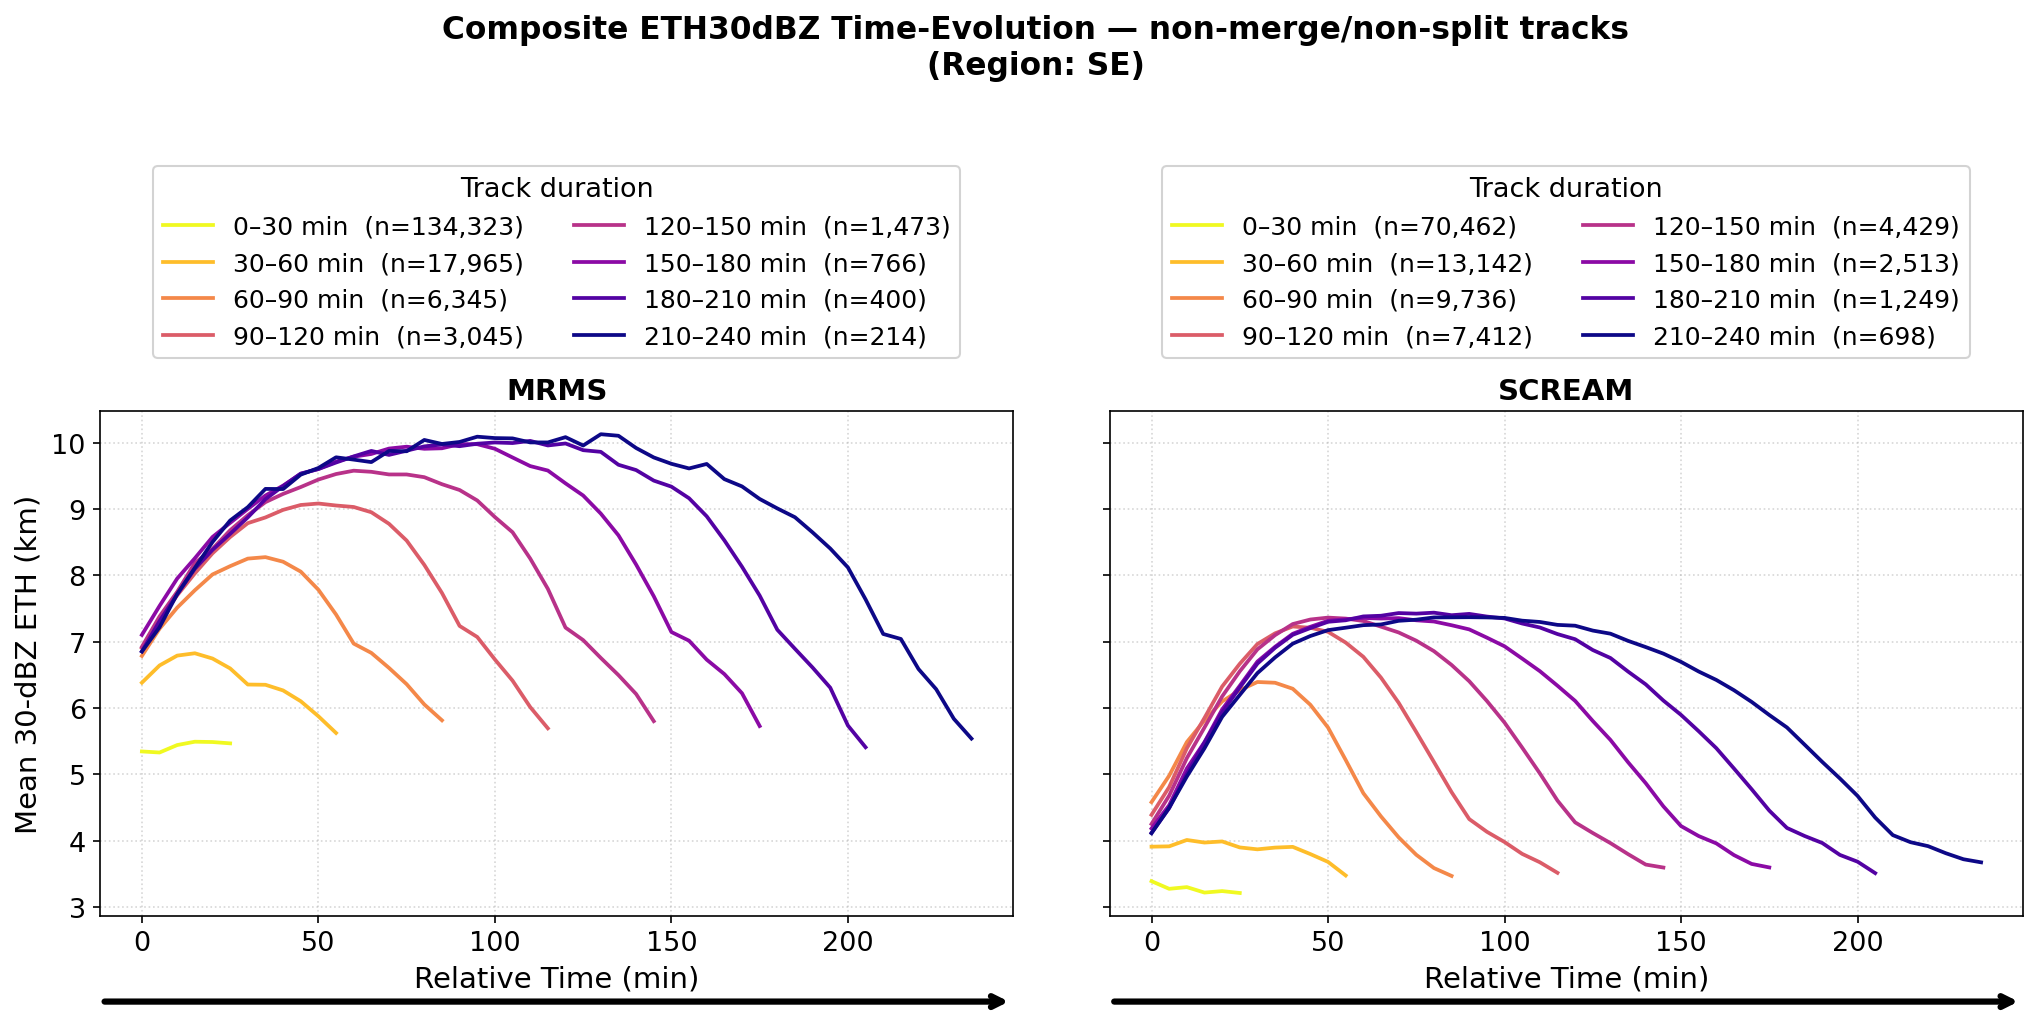

In [47]:
# ── Plot composite time-evolution for each variable ───────────────────────────
ds_order = [name_map['o'], name_map['m']]   # MRMS left, SCREAM right

for var, spec in comp_var_specs.items():
    figname_comp = (
        f'{figdir}Composite_{spec["filetag"]}_byDuration_'
        f'{name_map["m"]}_{name_map["o"]}_{region}.pdf'
    )
    fig, axes = plot_composite_evolution(
        all_composites[var],
        ds_order  = ds_order,
        nrow=1, ncol=2,
        figsize   = (14, 6),
        dpi       = 150,
        cmap_name = 'plasma_r',
        fontsize  = 14,
        xlabel    = 'Relative Time (min)',
        ylabel    = spec['ylabel'],
        suptitle  = (
            f'Composite {spec["filetag"]} Time-Evolution — non-merge/non-split tracks\n'
            f'(Region: {region})'
        ),
        figname   = figname_comp,
    )
